In [1]:
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import tkinter as tk
from tkinter import filedialog, messagebox
import pandas as pd
config = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}

def volcano_plot_no_visualization(df, title, M=config['Magnitude (M)'], A=config['Altitude (A)'], method=config['method'], alpha=config['alpha'], logFC_threshold=config['logFC_threshold'], highlight_genes=config['highlight_genes'], top_genes=config['top_genes'], upreg_criteria=config['upreg_criteria'], downreg_criteria=config['downreg_criteria'], upregulated_color=config['upregulated_color'], downregulated_color=config['downregulated_color'], not_significant_color=config['not_significant_color'], not_significant_between_logFC_threshold_color=config['not_significant_between_logFC_threshold_color'], pie_chart_size=config['pie_chart_size'], pie_chart_position=config['pie_chart_position'], ranking_method=config['ranking_method'], up_or_down_or_both=config['up_or_down_or_both'], g100=config['g100'], g010=config['g010'], g001=config['g001'], g110=config['g110'], g101=config['g101'], g011=config['g011'], g111=config['g111']):
    method_to_column = {'PValue': 'PValue', 'BH': 'BH_adjusted_p-value', 'Bonferroni': 'Bonferroni_adjusted_p-value', 'BY': 'BY_adjusted_p-value', 'Holm': 'Holm_adjusted_p-value', 'Hochberg': 'Hochberg_adjusted_p-value', 'adjusted_p-value': 'adjusted_p-value'}
    if ranking_method not in ['Corner', 'MAS']:
        raise ValueError("Invalid ranking_method. Valid options are 'corner' and 'MAS'")
    if ranking_method == 'Corner':
        ranked_df = Corner_ranking(df, method=method, alpha=alpha)
    else:
        ranked_df = MAS(df, M=M, A=A, method=method, alpha=alpha, logFC_threshold=logFC_threshold, up_or_down_or_both=up_or_down_or_both)
    y_column = method_to_column[method]
    ranked_df['-log10(P)'] = -np.log10(ranked_df[y_column])
    if method == 'Bonferroni':
        adjusted_alpha = alpha
    else:
        adjusted_alpha = alpha
    significance_threshold = -np.log10(adjusted_alpha)
    if up_or_down_or_both == 'Only_upregulated':
        significant_genes_criteria = (df['logFC'] > logFC_threshold) & (df[y_column] <= adjusted_alpha)
    elif up_or_down_or_both == 'Only_downregulated':
        significant_genes_criteria = (df['logFC'] < -logFC_threshold) & (df[y_column] <= adjusted_alpha)
    elif up_or_down_or_both == 'both_up_and_down_regulated':
        significant_genes_criteria = (df['logFC'].abs() > logFC_threshold) & (df[y_column] <= adjusted_alpha)
    significant_genes = df[significant_genes_criteria]
    ranked_df['Category'] = 'Not Significant'
    ranked_df.loc[ranked_df.apply(lambda row: row['logFC'] >= logFC_threshold and row[y_column] <= adjusted_alpha, axis=1), 'Category'] = 'Upregulated'
    ranked_df.loc[ranked_df.apply(lambda row: row['logFC'] <= -logFC_threshold and row[y_column] <= adjusted_alpha, axis=1), 'Category'] = 'Downregulated'
    upreg_criteria = upreg_criteria if upreg_criteria is not None else lambda row: row[y_column] <= adjusted_alpha and row['logFC'] >= logFC_threshold
    downreg_criteria = downreg_criteria if downreg_criteria is not None else lambda row: row[y_column] <= adjusted_alpha and row['logFC'] <= -logFC_threshold
    ranked_df['Category'] = 'Not Significant'
    ranked_df.loc[ranked_df.apply(upreg_criteria, axis=1), 'Category'] = 'Upregulated'
    ranked_df.loc[ranked_df.apply(downreg_criteria, axis=1), 'Category'] = 'Downregulated'
    colors = {'Upregulated': upregulated_color, 'Downregulated': downregulated_color, 'Not Significant': not_significant_color, 'Not Significant Between LogFC Threshold': not_significant_between_logFC_threshold_color}
    all_genes = ranked_df[ranked_df['Category'] != 'Not Significant Between LogFC Threshold']
    not_sig_between_genes = ranked_df[ranked_df['Category'] == 'Not Significant Between LogFC Threshold']
    method = config['method']
    ranking_method = config['ranking_method']
    if up_or_down_or_both == 'Only_upregulated':
        significance_criteria = (ranked_df['logFC'] > logFC_threshold) & (ranked_df[y_column] <= adjusted_alpha)
    elif up_or_down_or_both == 'Only_downregulated':
        significance_criteria = (ranked_df['logFC'] < -logFC_threshold) & (ranked_df[y_column] <= adjusted_alpha)
    elif up_or_down_or_both == 'both_up_and_down_regulated':
        significance_criteria = (ranked_df['logFC'].abs() > logFC_threshold) & (ranked_df[y_column] <= adjusted_alpha)
    significant = sum(significance_criteria)
    insignificant = len(ranked_df) - significant
    sizes = [significant, insignificant]
    labels = [f'Significant ({significant}) - {significant / len(ranked_df):.1%}', f'Insignificant ({insignificant}) - {insignificant / len(ranked_df):.1%}']
    labels2 = [f'', f'']
    colors = ['lightgreen', 'gray']
    output_columns = ['Gene Symbol', 'logFC', 'PValue', y_column]
    if ranking_method == 'Corner':
        output_columns += ['corner_rank', 'corner_distance']
    elif ranking_method == 'MAS':
        output_columns += ['MAS_rank', 'MAS_Score']
    output_df = ranked_df[output_columns]
    output_df = output_df.rename(columns={y_column: method})
    ranked_df['Category'] = 'Insignificant'
    ranked_df.loc[significance_criteria & (ranked_df['logFC'] > 0), 'Category'] = 'Upregulated'
    ranked_df.loc[significance_criteria & (ranked_df['logFC'] < 0), 'Category'] = 'Downregulated'
    significant_genes = ranked_df[ranked_df['Category'].isin(['Upregulated', 'Downregulated'])]
    if ranking_method == 'MAS':
        significant_genes = significant_genes.sort_values(by='MAS_Score', ascending=False).reset_index(drop=True)
        significant_genes['MAS_rank'] = significant_genes.index + 1
    else:
        x_max = df['logFC'].max()
        x_min = df['logFC'].min()
        maximum_x = max(abs(x_min), abs(x_max))
        y_max = ranked_df['-log10(P)'].max()

        def calculate_distance(row):
            x = row['logFC']
            y = row['-log10(P)']
            if x >= 0:
                return np.sqrt((x - maximum_x) ** 2 + (y - y_max) ** 2)
            else:
                return np.sqrt((x + maximum_x) ** 2 + (y - y_max) ** 2)
        significant_genes['corner_distance'] = significant_genes.apply(calculate_distance, axis=1)
        significant_genes = significant_genes.sort_values(by='corner_distance').reset_index(drop=True)
        significant_genes['corner_rank'] = significant_genes.index + 1
    return (output_df, significant_genes)
import numpy as np

def MAS(df, M, A, method, alpha, logFC_threshold, up_or_down_or_both):
    if method == 'PValue':
        y_column = 'PValue'
    elif method == 'BH':
        df['BH_adjusted_p-value'] = BH_adjusted_pvalue(df['PValue'].values, alpha)
        y_column = 'BH_adjusted_p-value'
    elif method == 'Bonferroni':
        n_tests = len(df)
        df['Bonferroni_adjusted_p-value'] = np.minimum(df['PValue'] * n_tests, 1.0)
        y_column = 'Bonferroni_adjusted_p-value'
    elif method == 'BY':
        df['BY_adjusted_p-value'] = BY_adjusted_pvalue(df['PValue'].values, alpha)
        y_column = 'BY_adjusted_p-value'
    elif method == 'Holm':
        df['Holm_adjusted_p-value'] = Holm_adjusted_pvalue(df['PValue'].values, alpha)
        y_column = 'Holm_adjusted_p-value'
    elif method == 'Hochberg':
        df['Hochberg_adjusted_p-value'] = Hochberg_adjusted_pvalue(df['PValue'].values, alpha)
        y_column = 'Hochberg_adjusted_p-value'
    else:
        y_column = 'PValue'
    df[y_column] = df[y_column].clip(upper=1)
    adjusted_alpha = alpha / len(df) if method == 'Bonferroni' else alpha
    if up_or_down_or_both == 'Only_upregulated':
        df['MAS_Score'] = np.where((df['logFC'] > logFC_threshold) & (df[y_column] <= adjusted_alpha), np.abs(df['logFC']) ** M * np.abs(-np.log10(df[y_column])) ** A, 0)
    elif up_or_down_or_both == 'Only_downregulated':
        df['MAS_Score'] = np.where((df['logFC'] < -logFC_threshold) & (df[y_column] <= adjusted_alpha), np.abs(df['logFC']) ** M * np.abs(-np.log10(df[y_column])) ** A, 0)
    elif up_or_down_or_both == 'both_up_and_down_regulated':
        df['MAS_Score'] = np.where((df['logFC'].abs() > logFC_threshold) & (df[y_column] <= adjusted_alpha), np.abs(df['logFC']) ** M * np.abs(-np.log10(df[y_column])) ** A, 0)
    df = df.sort_values(by='MAS_Score', ascending=False).reset_index(drop=True)
    df['MAS_rank'] = df.index + 1
    return df

def BH_adjusted_pvalue(p, alpha):
    sort = np.argsort(p)
    rank = np.zeros(len(p))
    j = 1
    for i in range(len(sort)):
        rank[sort[i]] = j
        j = j + 1
    new_alpha = rank / len(p) * alpha
    L = []
    for j in range(len(rank)):
        if p[np.where(rank == len(rank) - j)[0][0]] < new_alpha[np.where(rank == len(rank) - j)[0][0]]:
            L.append(np.where(rank == len(rank) - j)[0][0])
    new_p = p * (len(p) / rank)
    H = np.zeros(len(p))
    H[np.where(rank == len(p))[0][0]] = new_p[np.where(rank == len(p))[0][0]]
    for k in range(1, len(p)):
        if new_p[np.where(rank == len(p) - k)[0][0]] > new_p[np.where(rank == len(p) - k + 1)[0][0]]:
            H[np.where(rank == len(p) - k)[0][0]] = new_p[np.where(rank == len(p) - k + 1)[0][0]]
        else:
            H[np.where(rank == len(p) - k)[0][0]] = new_p[np.where(rank == len(p) - k)[0][0]]
    BH_adjusted_p_values = np.where(H > 1, 1, H)
    return BH_adjusted_p_values
from matplotlib.ticker import MaxNLocator
import numpy as np
import matplotlib.pyplot as plt

def annotate_bars_vertical_with_totals(ax, positions, top_genes_up, top_genes_down, up_counts, down_counts, width):
    vertical_offset = 0.25
    total_offset = 0.3
    bbox_props = dict(boxstyle='round,pad=0.3', fc='seashell', ec='black', lw=1)
    for i, position in enumerate(positions):
        down_text = '\n'.join(top_genes_down[f'BH'])
        ax.text(position + width / 2, vertical_offset, down_text, ha='center', va='bottom', fontsize=22, color='black', rotation=0, transform=ax.get_xaxis_transform(), bbox=bbox_props)
        up_text = '\n'.join(top_genes_up[f'BH'])
        ax.text(position - width / 2, vertical_offset, up_text, ha='center', va='bottom', fontsize=22, color='black', rotation=0, transform=ax.get_xaxis_transform(), bbox=bbox_props)
        ax.text(position - width / 2, total_offset, f'Total: {down_counts[i]}', ha='center', va='bottom', fontsize=22, color='black', rotation=0)
        ax.text(position + width / 2, total_offset, f'Total: {up_counts[i]}', ha='center', va='bottom', fontsize=22, color='black', rotation=0)


In [2]:
import pandas as pd
from itertools import combinations
import pandas as pd
from itertools import combinations
import pandas as pd
from itertools import combinations

def get_top_genes_by_mas_rank(dataframes, group_names, top_k):
    gene_sets = {name: set(df['Gene Symbol'].dropna().unique()) for name, df in zip(group_names, dataframes)}
    top_genes_results = {}

    def find_top_genes(df, genes):
        gene_rank_max = df[df['Gene Symbol'].isin(genes)].groupby('Gene Symbol')['MAS_rank'].max().reset_index()
        top_10_genes = gene_rank_max.nsmallest(top_k, 'MAS_rank')['Gene Symbol'].tolist()
        return top_10_genes
    for r in range(1, len(group_names) + 1):
        for combo in combinations(group_names, r):
            combo_name = ', '.join(combo)
            common_genes = set.intersection(*(gene_sets[group] for group in combo))
            other_groups = set(group_names).difference(combo)
            other_genes = set.union(*(gene_sets[group] for group in other_groups)) if other_groups else set()
            uniquely_common_genes = common_genes.difference(other_genes)
            if uniquely_common_genes:
                combined_df = pd.concat([dataframes[group_names.index(group)] for group in combo], ignore_index=True)
                top_genes = find_top_genes(combined_df, uniquely_common_genes)
                top_genes_results[combo_name] = top_genes
    return top_genes_results


In [3]:
data = pd.read_csv('GSE115785-Ready.csv')
data.set_index('Gene Symbol', inplace=True)


In [4]:
groups = ['DPI_0', 'DPI_3', 'DPI_5', 'DPI_7', 'DPI_NEC']
group_dfs = {}
for group in groups:
    matching_cols = [col for col in data.columns if col.startswith(group)]
    group_dfs[group] = data[matching_cols]
control_df = group_dfs['DPI_0']
dpi3_df = group_dfs['DPI_3']
dpi5_df = group_dfs['DPI_5']
dpi7_df = group_dfs['DPI_7']
dpiNEC_df = group_dfs['DPI_NEC']


In [5]:
Control_dpi3 = pd.concat([control_df, dpi3_df], axis=1)
Control_dpi5 = pd.concat([control_df, dpi5_df], axis=1)
Control_dpi7 = pd.concat([control_df, dpi7_df], axis=1)
Control_dpiNEC = pd.concat([control_df, dpiNEC_df], axis=1)


In [6]:
combined_df = control_df.copy()
infected_df = pd.concat([dpi3_df, dpi5_df, dpi7_df, dpiNEC_df], axis=1)
infected_df.columns = [f'Infected ({i + 1})' for i in range(infected_df.shape[1])]
Control_Infected = pd.concat([combined_df, infected_df], axis=1)


In [7]:
import subprocess

def run_r_script():
    command = ['Rscript', 'TMM_GLMQL.R']
    result = subprocess.run(command, stdout=subprocess.PIPE, stderr=subprocess.PIPE, universal_newlines=True)
    if result.stdout:
        print('R script output:', result.stdout)
    if result.stderr:
        print('R script errors:', result.stderr)
if __name__ == '__main__':
    run_r_script()


R script output: [1] "Starting script execution."
[1] "Script has started running."
[1] "Guideline"
Script continues...
[1] "An error occurred: file choice cancelled"

R script errors: Loading required package: limma
Warning message:
package 'rstudioapi' was built under R version 4.3.3 



In [8]:
import glob
import pandas as pd
import os

def read_csv_files_to_dict(directory):
    pattern = os.path.join(directory, 'EdgeR_DPI_0_vs_*.csv')
    csv_files = glob.glob(pattern)
    if not csv_files:
        print('No matching files found in the directory.')
        return {}
    dataframes_dict = {}
    for file in csv_files:
        try:
            file_name = os.path.splitext(os.path.basename(file))[0]
            df = pd.read_csv(file)
            globals()[file_name] = df
            dataframes_dict[file_name] = df
            print(f'Loaded DataFrame: {file_name} from {file}')
        except Exception as e:
            print(f'Error reading file {file}: {e}')
    return dataframes_dict
if __name__ == '__main__':
    current_directory = './'
    dataframes = read_csv_files_to_dict(current_directory)
    print('\nAccessing DataFrames:')
    for file_name, df in dataframes.items():
        print(f'\nDataFrame: {file_name}')
        print(df.head())


Loaded DataFrame: EdgeR_DPI_0_vs_DPI_3 from .\EdgeR_DPI_0_vs_DPI_3.csv
Loaded DataFrame: EdgeR_DPI_0_vs_DPI_5 from .\EdgeR_DPI_0_vs_DPI_5.csv
Loaded DataFrame: EdgeR_DPI_0_vs_DPI_7 from .\EdgeR_DPI_0_vs_DPI_7.csv
Loaded DataFrame: EdgeR_DPI_0_vs_DPI_NEC from .\EdgeR_DPI_0_vs_DPI_NEC.csv

Accessing DataFrames:

DataFrame: EdgeR_DPI_0_vs_DPI_3
  GeneSymbol     logFC    logCPM          F        PValue       FDR  \
0     FAM53B -0.832773  8.119629  67.950652  9.114030e-09  0.000065   
1     TRIM17 -1.257789  2.263492  62.231879  1.121564e-08  0.000065   
2       RAI1 -1.193657  5.363882  56.571995  5.121355e-08  0.000198   
3       WNK4 -1.569799  0.553610  47.603123  9.967923e-08  0.000289   
4       M1AP -1.390677  0.730867  44.854151  1.872922e-07  0.000435   

   Bonferroni_pvalue  
0           0.000106  
1           0.000130  
2           0.000595  
3           0.001158  
4           0.002175  

DataFrame: EdgeR_DPI_0_vs_DPI_5
  GeneSymbol     logFC    logCPM           F        PValue

C:\Users\13367\AppData\Local\Temp\ipykernel_38220\4125877904.py:37: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  upregulated_patch = mpatches.Patch(color='pink', label='Upregulated', edgecolor='black', alpha=0.6)
C:\Users\13367\AppData\Local\Temp\ipykernel_38220\4125877904.py:38: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  downregulated_patch = mpatches.Patch(color='lightblue', label='Downregulated', edgecolor='black', alpha=0.6)
C:\Users\13367\AppData\Local\Temp\ipykernel_38220\4125877904.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


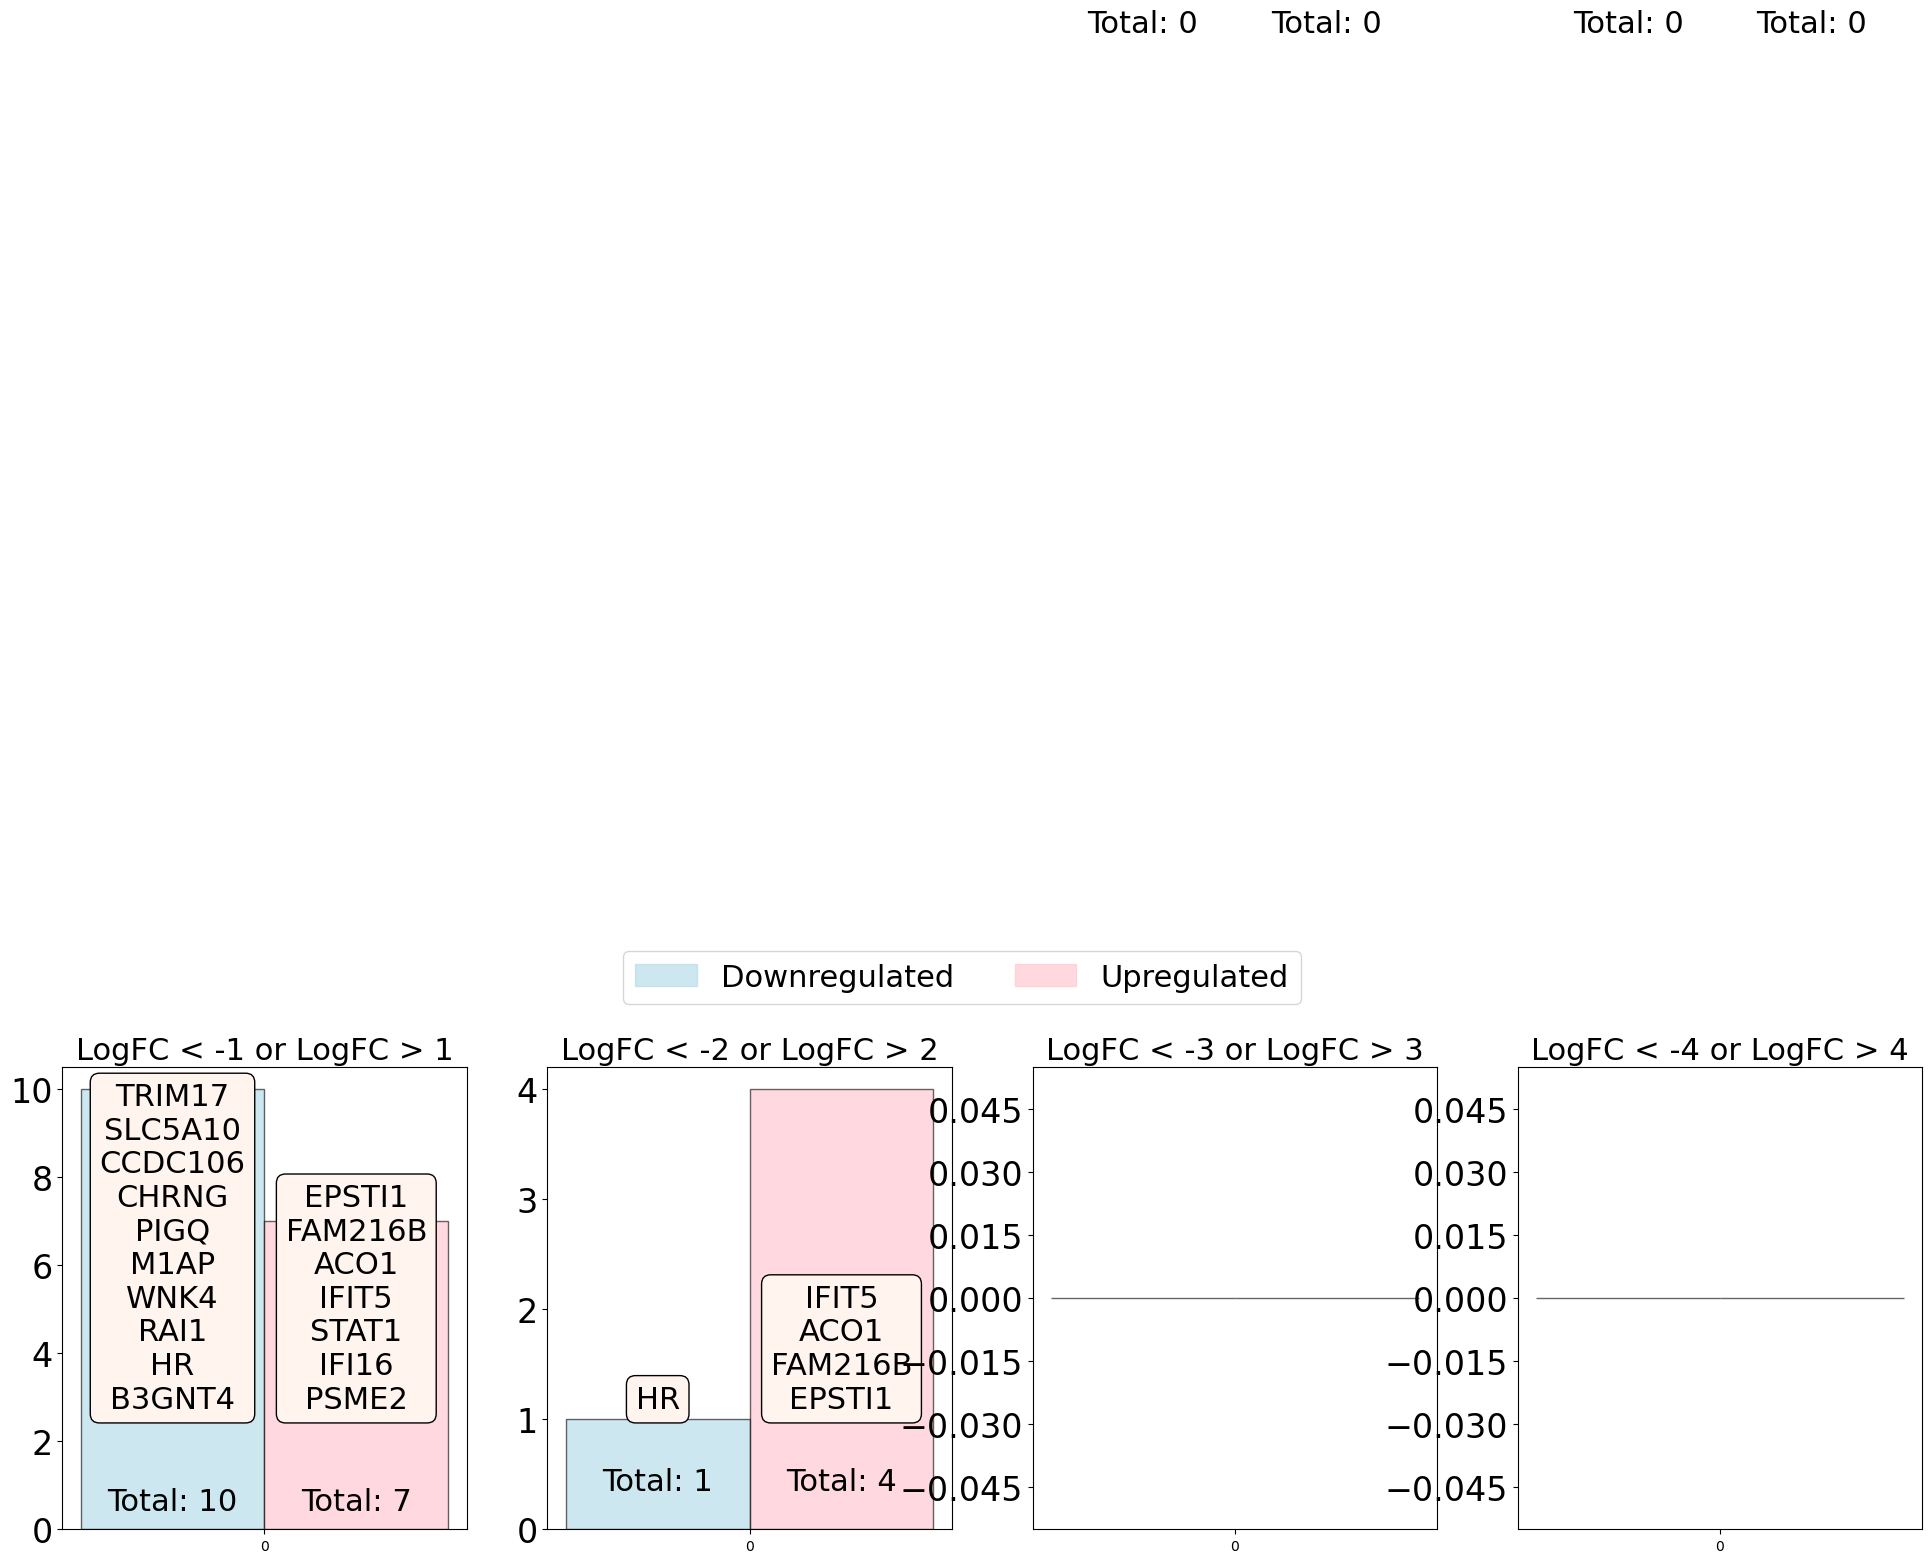

In [9]:
Data = dataframes['EdgeR_DPI_0_vs_DPI_3']
Data.rename(columns={'GeneSymbol': 'Gene Symbol'}, inplace=True)
title = 'EdgeR_DPI_0_vs_DPI_3'
config_Upset = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
AllGenes_DE_HLTY_vs_SARS_CoV_2, Significant_DE_HLTY_vs_SARS_CoV_2 = volcano_plot_no_visualization(Data, M=config_Upset['Magnitude (M)'], A=config_Upset['Altitude (A)'], title=title, method=config_Upset['method'], alpha=config_Upset['alpha'], logFC_threshold=config_Upset['logFC_threshold'], highlight_genes=config_Upset['highlight_genes'], top_genes=config_Upset['top_genes'], upreg_criteria=config_Upset['upreg_criteria'], downreg_criteria=config_Upset['downreg_criteria'], upregulated_color=config_Upset['upregulated_color'], downregulated_color=config_Upset['downregulated_color'], not_significant_color=config_Upset['not_significant_color'], not_significant_between_logFC_threshold_color=config_Upset['not_significant_between_logFC_threshold_color'], pie_chart_size=config_Upset['pie_chart_size'], pie_chart_position=config_Upset['pie_chart_position'], ranking_method=config_Upset['ranking_method'], up_or_down_or_both=config_Upset['up_or_down_or_both'], g100=config_Upset['g100'], g010=config_Upset['g010'], g001=config_Upset['g001'], g110=config_Upset['g110'], g101=config_Upset['g101'], g011=config_Upset['g011'], g111=config_Upset['g111'])
config = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
logFC_threshold_values = range(1, 5)
fig, axs = plt.subplots(1, 4, figsize=(24, 6))
axs = axs.flatten()
title_font = {'family': 'serif', 'color': 'darkred', 'weight': 'bold', 'size': 24}
label_font = {'family': 'arial', 'color': 'navy', 'weight': 'bold', 'size': 24}
title_font2 = {'family': 'serif', 'color': 'black', 'size': 24}
for idx, logFC_threshold in enumerate(logFC_threshold_values):
    ax = axs[idx]
    config['logFC_threshold'] = logFC_threshold
    AllGenes, Significant = volcano_plot_no_visualization(Data, M=config['Magnitude (M)'], A=config['Altitude (A)'], title=title, method=config['method'], alpha=config['alpha'], logFC_threshold=config['logFC_threshold'], highlight_genes=config['highlight_genes'], top_genes=config['top_genes'], upreg_criteria=config['upreg_criteria'], downreg_criteria=config['downreg_criteria'], upregulated_color=config['upregulated_color'], downregulated_color=config['downregulated_color'], not_significant_color=config['not_significant_color'], not_significant_between_logFC_threshold_color=config['not_significant_between_logFC_threshold_color'], pie_chart_size=config['pie_chart_size'], pie_chart_position=config['pie_chart_position'], ranking_method=config['ranking_method'], up_or_down_or_both=config['up_or_down_or_both'], g100=config['g100'], g010=config['g010'], g001=config['g001'], g110=config['g110'], g101=config['g101'], g011=config['g011'], g111=config['g111'])
    upregulated_counts = Significant[Significant['Category'] == 'Upregulated'].shape[0]
    downregulated_counts = Significant[Significant['Category'] == 'Downregulated'].shape[0]
    positions = np.arange(1)
    width = 1
    ax.bar(positions - width / 2, downregulated_counts, width, label='Downregulated', color='lightblue', edgecolor='black', alpha=0.6)
    ax.bar(positions + width / 2, upregulated_counts, width, label='Upregulated', color='pink', edgecolor='black', alpha=0.6)
    if logFC_threshold == 0:
        title = f'LogFC < {logFC_threshold} or LogFC > {logFC_threshold}'
    else:
        title = f'LogFC < -{logFC_threshold} or LogFC > {logFC_threshold}'
    ax.set_title(title, fontsize=22)
    ax.set_xticks(positions)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis='y', labelsize=24)
    top_10_down_genes = {'BH': Significant[Significant['logFC'] < 0].head(10)['Gene Symbol'].tolist()}
    top_10_up_genes = {'BH': Significant[Significant['logFC'] > 0].head(10)['Gene Symbol'].tolist()}
    summary_stats = {'BH': {'Total': Significant.shape[0], 'Upregulated': Significant[Significant['Category'] == 'Upregulated'].shape[0], 'Downregulated': Significant[Significant['Category'] == 'Downregulated'].shape[0]}}
    upregulated_counts = [summary_stats[obj]['Upregulated'] for obj in summary_stats]
    downregulated_counts = [summary_stats[obj]['Downregulated'] for obj in summary_stats]
    annotate_bars_vertical_with_totals(ax, positions, top_10_down_genes, top_10_up_genes, upregulated_counts, downregulated_counts, width)
upregulated_patch = mpatches.Patch(color='pink', label='Upregulated', edgecolor='black', alpha=0.6)
downregulated_patch = mpatches.Patch(color='lightblue', label='Downregulated', edgecolor='black', alpha=0.6)
fig.legend(handles=[downregulated_patch, upregulated_patch], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.1), fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
Bonferroni_Upregulated = Significant_DE_HLTY_vs_SARS_CoV_2[Significant_DE_HLTY_vs_SARS_CoV_2['logFC'] > 1]
Bonferroni_Downregulated = Significant_DE_HLTY_vs_SARS_CoV_2[Significant_DE_HLTY_vs_SARS_CoV_2['logFC'] < -1]
Bonferroni_Significant = Significant_DE_HLTY_vs_SARS_CoV_2.copy()
Bonferroni_Upregulated.to_csv('EdgeR_Upregulated_DPI-3.csv', index=False)
Bonferroni_Downregulated.to_csv('EdgeR_Downregulated_DPI-3.csv', index=False)
Bonferroni_Significant.to_csv('EdgeR_Significant_DPI-3.csv', index=False)


C:\Users\13367\AppData\Local\Temp\ipykernel_38220\4008149869.py:37: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  upregulated_patch = mpatches.Patch(color='pink', label='Upregulated', edgecolor='black', alpha=0.6)
C:\Users\13367\AppData\Local\Temp\ipykernel_38220\4008149869.py:38: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  downregulated_patch = mpatches.Patch(color='lightblue', label='Downregulated', edgecolor='black', alpha=0.6)


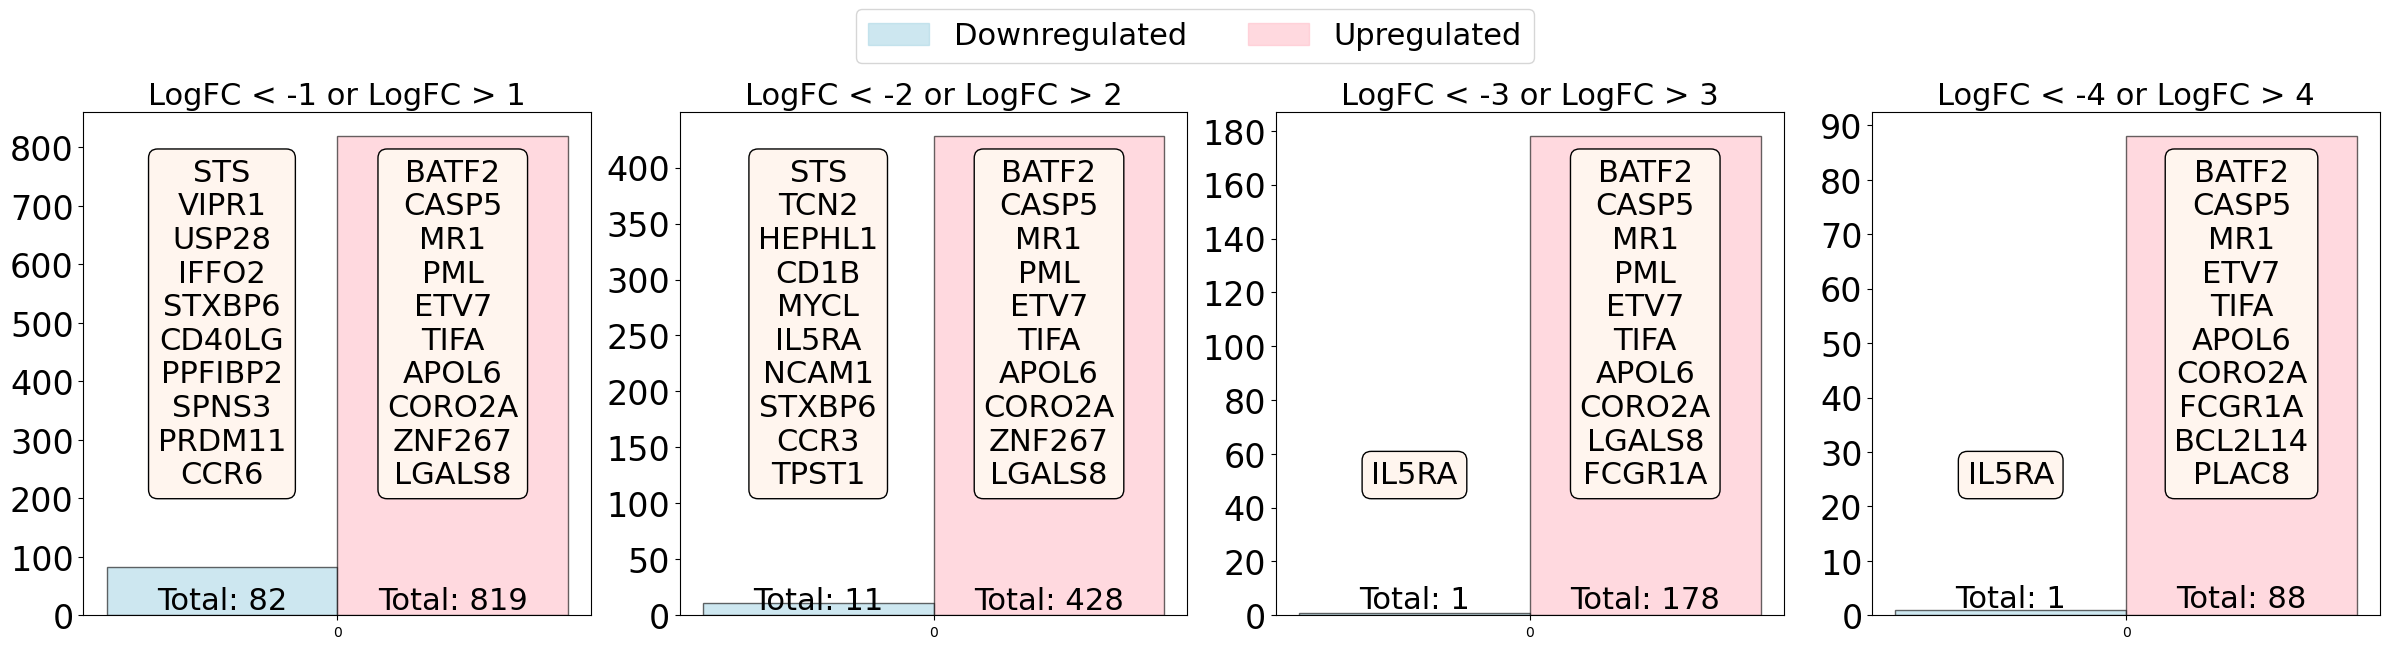

In [10]:
Data = dataframes['EdgeR_DPI_0_vs_DPI_5']
Data.rename(columns={'GeneSymbol': 'Gene Symbol'}, inplace=True)
title = 'EdgeR_DPI_0_vs_DPI_5'
config_Upset = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
AllGenes_DE_HLTY_vs_SARS_CoV_2, Significant_DE_HLTY_vs_SARS_CoV_2 = volcano_plot_no_visualization(Data, M=config_Upset['Magnitude (M)'], A=config_Upset['Altitude (A)'], title=title, method=config_Upset['method'], alpha=config_Upset['alpha'], logFC_threshold=config_Upset['logFC_threshold'], highlight_genes=config_Upset['highlight_genes'], top_genes=config_Upset['top_genes'], upreg_criteria=config_Upset['upreg_criteria'], downreg_criteria=config_Upset['downreg_criteria'], upregulated_color=config_Upset['upregulated_color'], downregulated_color=config_Upset['downregulated_color'], not_significant_color=config_Upset['not_significant_color'], not_significant_between_logFC_threshold_color=config_Upset['not_significant_between_logFC_threshold_color'], pie_chart_size=config_Upset['pie_chart_size'], pie_chart_position=config_Upset['pie_chart_position'], ranking_method=config_Upset['ranking_method'], up_or_down_or_both=config_Upset['up_or_down_or_both'], g100=config_Upset['g100'], g010=config_Upset['g010'], g001=config_Upset['g001'], g110=config_Upset['g110'], g101=config_Upset['g101'], g011=config_Upset['g011'], g111=config_Upset['g111'])
config = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
logFC_threshold_values = range(1, 5)
fig, axs = plt.subplots(1, 4, figsize=(24, 6))
axs = axs.flatten()
title_font = {'family': 'serif', 'color': 'darkred', 'weight': 'bold', 'size': 24}
label_font = {'family': 'arial', 'color': 'navy', 'weight': 'bold', 'size': 24}
title_font2 = {'family': 'serif', 'color': 'black', 'size': 24}
for idx, logFC_threshold in enumerate(logFC_threshold_values):
    ax = axs[idx]
    config['logFC_threshold'] = logFC_threshold
    AllGenes, Significant = volcano_plot_no_visualization(Data, M=config['Magnitude (M)'], A=config['Altitude (A)'], title=title, method=config['method'], alpha=config['alpha'], logFC_threshold=config['logFC_threshold'], highlight_genes=config['highlight_genes'], top_genes=config['top_genes'], upreg_criteria=config['upreg_criteria'], downreg_criteria=config['downreg_criteria'], upregulated_color=config['upregulated_color'], downregulated_color=config['downregulated_color'], not_significant_color=config['not_significant_color'], not_significant_between_logFC_threshold_color=config['not_significant_between_logFC_threshold_color'], pie_chart_size=config['pie_chart_size'], pie_chart_position=config['pie_chart_position'], ranking_method=config['ranking_method'], up_or_down_or_both=config['up_or_down_or_both'], g100=config['g100'], g010=config['g010'], g001=config['g001'], g110=config['g110'], g101=config['g101'], g011=config['g011'], g111=config['g111'])
    upregulated_counts = Significant[Significant['Category'] == 'Upregulated'].shape[0]
    downregulated_counts = Significant[Significant['Category'] == 'Downregulated'].shape[0]
    positions = np.arange(1)
    width = 1
    ax.bar(positions - width / 2, downregulated_counts, width, label='Downregulated', color='lightblue', edgecolor='black', alpha=0.6)
    ax.bar(positions + width / 2, upregulated_counts, width, label='Upregulated', color='pink', edgecolor='black', alpha=0.6)
    if logFC_threshold == 0:
        title = f'LogFC < {logFC_threshold} or LogFC > {logFC_threshold}'
    else:
        title = f'LogFC < -{logFC_threshold} or LogFC > {logFC_threshold}'
    ax.set_title(title, fontsize=22)
    ax.set_xticks(positions)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis='y', labelsize=24)
    top_10_down_genes = {'BH': Significant[Significant['logFC'] < 0].head(10)['Gene Symbol'].tolist()}
    top_10_up_genes = {'BH': Significant[Significant['logFC'] > 0].head(10)['Gene Symbol'].tolist()}
    summary_stats = {'BH': {'Total': Significant.shape[0], 'Upregulated': Significant[Significant['Category'] == 'Upregulated'].shape[0], 'Downregulated': Significant[Significant['Category'] == 'Downregulated'].shape[0]}}
    upregulated_counts = [summary_stats[obj]['Upregulated'] for obj in summary_stats]
    downregulated_counts = [summary_stats[obj]['Downregulated'] for obj in summary_stats]
    annotate_bars_vertical_with_totals(ax, positions, top_10_down_genes, top_10_up_genes, upregulated_counts, downregulated_counts, width)
upregulated_patch = mpatches.Patch(color='pink', label='Upregulated', edgecolor='black', alpha=0.6)
downregulated_patch = mpatches.Patch(color='lightblue', label='Downregulated', edgecolor='black', alpha=0.6)
fig.legend(handles=[downregulated_patch, upregulated_patch], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.1), fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
Bonferroni_Upregulated = Significant_DE_HLTY_vs_SARS_CoV_2[Significant_DE_HLTY_vs_SARS_CoV_2['logFC'] > 1]
Bonferroni_Downregulated = Significant_DE_HLTY_vs_SARS_CoV_2[Significant_DE_HLTY_vs_SARS_CoV_2['logFC'] < -1]
Bonferroni_Significant = Significant_DE_HLTY_vs_SARS_CoV_2.copy()
Bonferroni_Upregulated.to_csv('EdgeR_Upregulated_DPI-5.csv', index=False)
Bonferroni_Downregulated.to_csv('EdgeR_Downregulated_DPI-5.csv', index=False)
Bonferroni_Significant.to_csv('EdgeR_Significant_DPI-5.csv', index=False)


C:\Users\13367\AppData\Local\Temp\ipykernel_38220\3183973232.py:37: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  upregulated_patch = mpatches.Patch(color='pink', label='Upregulated', edgecolor='black', alpha=0.6)
C:\Users\13367\AppData\Local\Temp\ipykernel_38220\3183973232.py:38: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  downregulated_patch = mpatches.Patch(color='lightblue', label='Downregulated', edgecolor='black', alpha=0.6)


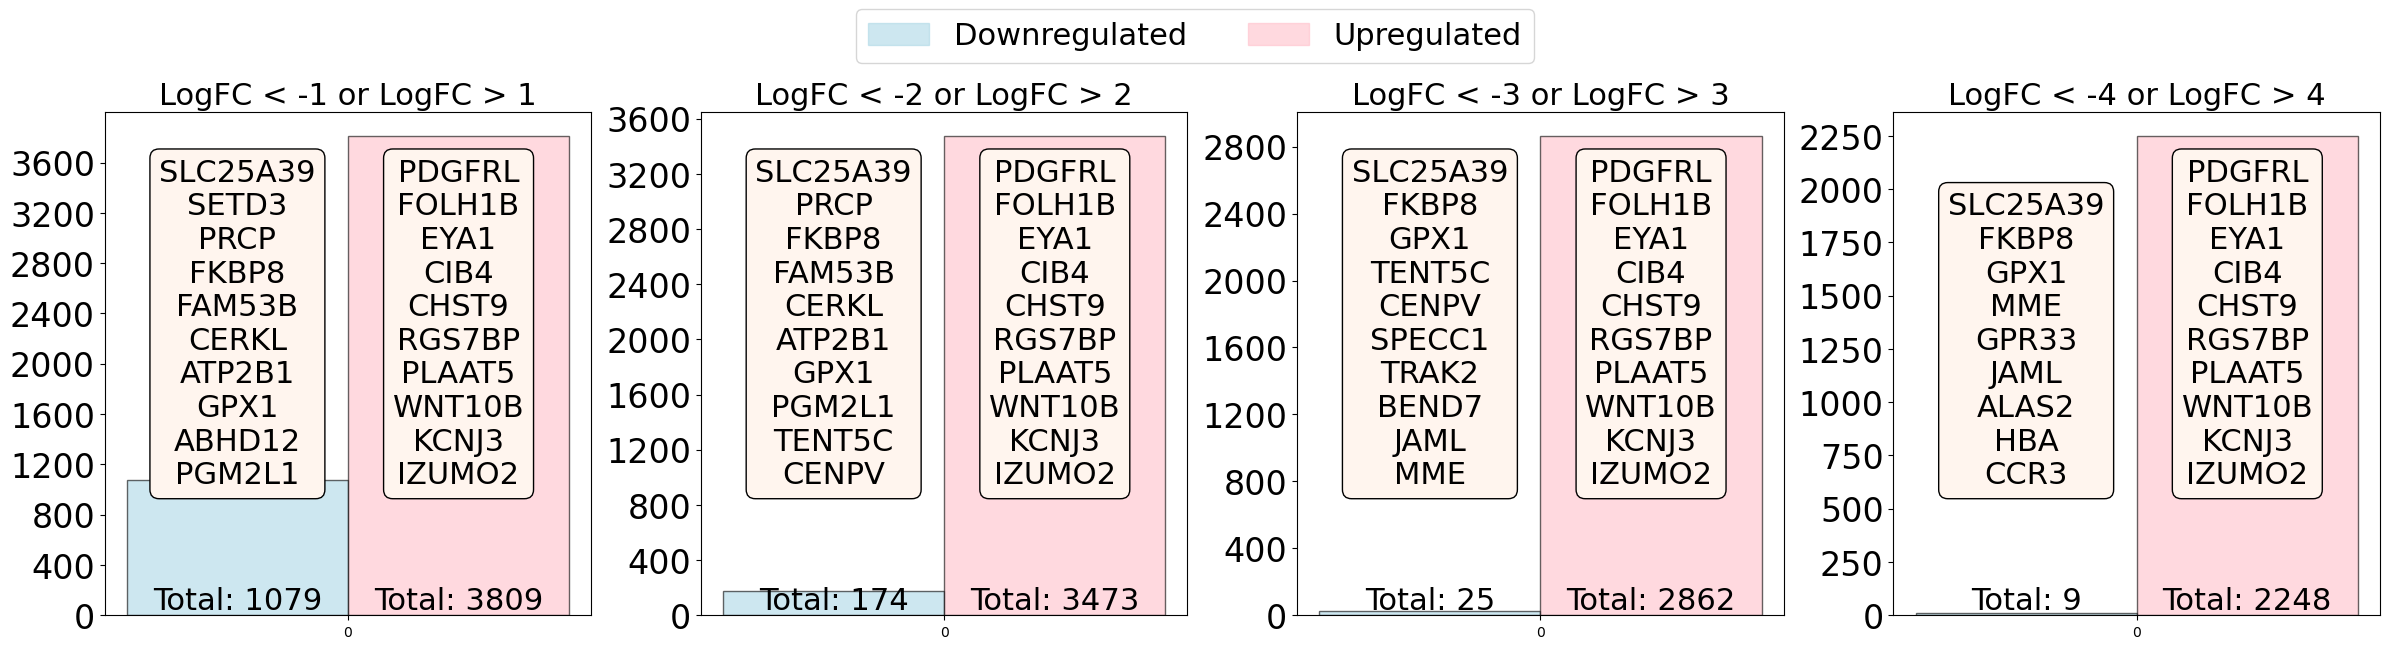

In [11]:
Data = dataframes['EdgeR_DPI_0_vs_DPI_7']
Data.rename(columns={'GeneSymbol': 'Gene Symbol'}, inplace=True)
title = 'EdgeR_DPI_0_vs_DPI_7'
config_Upset = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
AllGenes_DE_HLTY_vs_SARS_CoV_2, Significant_DE_HLTY_vs_SARS_CoV_2 = volcano_plot_no_visualization(Data, M=config_Upset['Magnitude (M)'], A=config_Upset['Altitude (A)'], title=title, method=config_Upset['method'], alpha=config_Upset['alpha'], logFC_threshold=config_Upset['logFC_threshold'], highlight_genes=config_Upset['highlight_genes'], top_genes=config_Upset['top_genes'], upreg_criteria=config_Upset['upreg_criteria'], downreg_criteria=config_Upset['downreg_criteria'], upregulated_color=config_Upset['upregulated_color'], downregulated_color=config_Upset['downregulated_color'], not_significant_color=config_Upset['not_significant_color'], not_significant_between_logFC_threshold_color=config_Upset['not_significant_between_logFC_threshold_color'], pie_chart_size=config_Upset['pie_chart_size'], pie_chart_position=config_Upset['pie_chart_position'], ranking_method=config_Upset['ranking_method'], up_or_down_or_both=config_Upset['up_or_down_or_both'], g100=config_Upset['g100'], g010=config_Upset['g010'], g001=config_Upset['g001'], g110=config_Upset['g110'], g101=config_Upset['g101'], g011=config_Upset['g011'], g111=config_Upset['g111'])
config = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
logFC_threshold_values = range(1, 5)
fig, axs = plt.subplots(1, 4, figsize=(24, 6))
axs = axs.flatten()
title_font = {'family': 'serif', 'color': 'darkred', 'weight': 'bold', 'size': 24}
label_font = {'family': 'arial', 'color': 'navy', 'weight': 'bold', 'size': 24}
title_font2 = {'family': 'serif', 'color': 'black', 'size': 24}
for idx, logFC_threshold in enumerate(logFC_threshold_values):
    ax = axs[idx]
    config['logFC_threshold'] = logFC_threshold
    AllGenes, Significant = volcano_plot_no_visualization(Data, M=config['Magnitude (M)'], A=config['Altitude (A)'], title=title, method=config['method'], alpha=config['alpha'], logFC_threshold=config['logFC_threshold'], highlight_genes=config['highlight_genes'], top_genes=config['top_genes'], upreg_criteria=config['upreg_criteria'], downreg_criteria=config['downreg_criteria'], upregulated_color=config['upregulated_color'], downregulated_color=config['downregulated_color'], not_significant_color=config['not_significant_color'], not_significant_between_logFC_threshold_color=config['not_significant_between_logFC_threshold_color'], pie_chart_size=config['pie_chart_size'], pie_chart_position=config['pie_chart_position'], ranking_method=config['ranking_method'], up_or_down_or_both=config['up_or_down_or_both'], g100=config['g100'], g010=config['g010'], g001=config['g001'], g110=config['g110'], g101=config['g101'], g011=config['g011'], g111=config['g111'])
    upregulated_counts = Significant[Significant['Category'] == 'Upregulated'].shape[0]
    downregulated_counts = Significant[Significant['Category'] == 'Downregulated'].shape[0]
    positions = np.arange(1)
    width = 1
    ax.bar(positions - width / 2, downregulated_counts, width, label='Downregulated', color='lightblue', edgecolor='black', alpha=0.6)
    ax.bar(positions + width / 2, upregulated_counts, width, label='Upregulated', color='pink', edgecolor='black', alpha=0.6)
    if logFC_threshold == 0:
        title = f'LogFC < {logFC_threshold} or LogFC > {logFC_threshold}'
    else:
        title = f'LogFC < -{logFC_threshold} or LogFC > {logFC_threshold}'
    ax.set_title(title, fontsize=22)
    ax.set_xticks(positions)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis='y', labelsize=24)
    top_10_down_genes = {'BH': Significant[Significant['logFC'] < 0].head(10)['Gene Symbol'].tolist()}
    top_10_up_genes = {'BH': Significant[Significant['logFC'] > 0].head(10)['Gene Symbol'].tolist()}
    summary_stats = {'BH': {'Total': Significant.shape[0], 'Upregulated': Significant[Significant['Category'] == 'Upregulated'].shape[0], 'Downregulated': Significant[Significant['Category'] == 'Downregulated'].shape[0]}}
    upregulated_counts = [summary_stats[obj]['Upregulated'] for obj in summary_stats]
    downregulated_counts = [summary_stats[obj]['Downregulated'] for obj in summary_stats]
    annotate_bars_vertical_with_totals(ax, positions, top_10_down_genes, top_10_up_genes, upregulated_counts, downregulated_counts, width)
upregulated_patch = mpatches.Patch(color='pink', label='Upregulated', edgecolor='black', alpha=0.6)
downregulated_patch = mpatches.Patch(color='lightblue', label='Downregulated', edgecolor='black', alpha=0.6)
fig.legend(handles=[downregulated_patch, upregulated_patch], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.1), fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
Bonferroni_Upregulated = Significant_DE_HLTY_vs_SARS_CoV_2[Significant_DE_HLTY_vs_SARS_CoV_2['logFC'] > 1]
Bonferroni_Downregulated = Significant_DE_HLTY_vs_SARS_CoV_2[Significant_DE_HLTY_vs_SARS_CoV_2['logFC'] < -1]
Bonferroni_Significant = Significant_DE_HLTY_vs_SARS_CoV_2.copy()
Bonferroni_Upregulated.to_csv('EdgeR_Upregulated_DPI-7.csv', index=False)
Bonferroni_Downregulated.to_csv('EdgeR_Downregulated_DPI-7.csv', index=False)
Bonferroni_Significant.to_csv('EdgeR_Significant_DPI-7.csv', index=False)


C:\Users\13367\AppData\Local\Temp\ipykernel_38220\1761902115.py:37: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  upregulated_patch = mpatches.Patch(color='pink', label='Upregulated', edgecolor='black', alpha=0.6)
C:\Users\13367\AppData\Local\Temp\ipykernel_38220\1761902115.py:38: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  downregulated_patch = mpatches.Patch(color='lightblue', label='Downregulated', edgecolor='black', alpha=0.6)


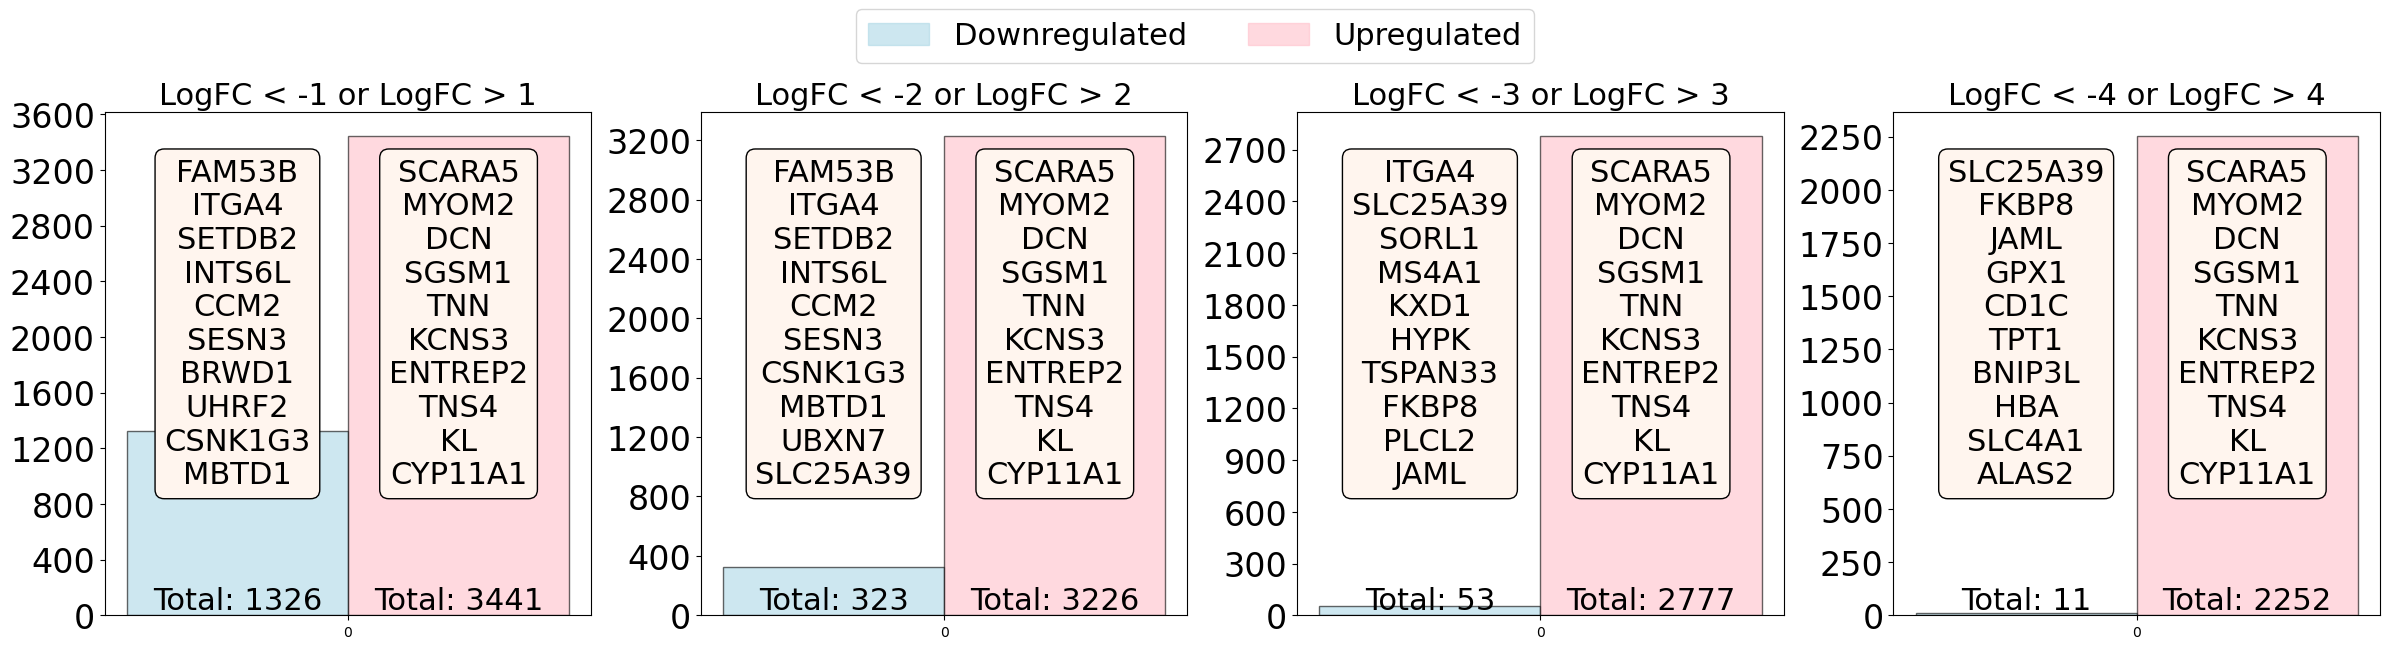

In [12]:
Data = dataframes['EdgeR_DPI_0_vs_DPI_NEC']
Data.rename(columns={'GeneSymbol': 'Gene Symbol'}, inplace=True)
title = 'EdgeR_DPI_0_vs_DPI_NEC'
config_Upset = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
AllGenes_DE_HLTY_vs_SARS_CoV_2, Significant_DE_HLTY_vs_SARS_CoV_2 = volcano_plot_no_visualization(Data, M=config_Upset['Magnitude (M)'], A=config_Upset['Altitude (A)'], title=title, method=config_Upset['method'], alpha=config_Upset['alpha'], logFC_threshold=config_Upset['logFC_threshold'], highlight_genes=config_Upset['highlight_genes'], top_genes=config_Upset['top_genes'], upreg_criteria=config_Upset['upreg_criteria'], downreg_criteria=config_Upset['downreg_criteria'], upregulated_color=config_Upset['upregulated_color'], downregulated_color=config_Upset['downregulated_color'], not_significant_color=config_Upset['not_significant_color'], not_significant_between_logFC_threshold_color=config_Upset['not_significant_between_logFC_threshold_color'], pie_chart_size=config_Upset['pie_chart_size'], pie_chart_position=config_Upset['pie_chart_position'], ranking_method=config_Upset['ranking_method'], up_or_down_or_both=config_Upset['up_or_down_or_both'], g100=config_Upset['g100'], g010=config_Upset['g010'], g001=config_Upset['g001'], g110=config_Upset['g110'], g101=config_Upset['g101'], g011=config_Upset['g011'], g111=config_Upset['g111'])
config = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
logFC_threshold_values = range(1, 5)
fig, axs = plt.subplots(1, 4, figsize=(24, 6))
axs = axs.flatten()
title_font = {'family': 'serif', 'color': 'darkred', 'weight': 'bold', 'size': 24}
label_font = {'family': 'arial', 'color': 'navy', 'weight': 'bold', 'size': 24}
title_font2 = {'family': 'serif', 'color': 'black', 'size': 24}
for idx, logFC_threshold in enumerate(logFC_threshold_values):
    ax = axs[idx]
    config['logFC_threshold'] = logFC_threshold
    AllGenes, Significant = volcano_plot_no_visualization(Data, M=config['Magnitude (M)'], A=config['Altitude (A)'], title=title, method=config['method'], alpha=config['alpha'], logFC_threshold=config['logFC_threshold'], highlight_genes=config['highlight_genes'], top_genes=config['top_genes'], upreg_criteria=config['upreg_criteria'], downreg_criteria=config['downreg_criteria'], upregulated_color=config['upregulated_color'], downregulated_color=config['downregulated_color'], not_significant_color=config['not_significant_color'], not_significant_between_logFC_threshold_color=config['not_significant_between_logFC_threshold_color'], pie_chart_size=config['pie_chart_size'], pie_chart_position=config['pie_chart_position'], ranking_method=config['ranking_method'], up_or_down_or_both=config['up_or_down_or_both'], g100=config['g100'], g010=config['g010'], g001=config['g001'], g110=config['g110'], g101=config['g101'], g011=config['g011'], g111=config['g111'])
    upregulated_counts = Significant[Significant['Category'] == 'Upregulated'].shape[0]
    downregulated_counts = Significant[Significant['Category'] == 'Downregulated'].shape[0]
    positions = np.arange(1)
    width = 1
    ax.bar(positions - width / 2, downregulated_counts, width, label='Downregulated', color='lightblue', edgecolor='black', alpha=0.6)
    ax.bar(positions + width / 2, upregulated_counts, width, label='Upregulated', color='pink', edgecolor='black', alpha=0.6)
    if logFC_threshold == 0:
        title = f'LogFC < {logFC_threshold} or LogFC > {logFC_threshold}'
    else:
        title = f'LogFC < -{logFC_threshold} or LogFC > {logFC_threshold}'
    ax.set_title(title, fontsize=22)
    ax.set_xticks(positions)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis='y', labelsize=24)
    top_10_down_genes = {'BH': Significant[Significant['logFC'] < 0].head(10)['Gene Symbol'].tolist()}
    top_10_up_genes = {'BH': Significant[Significant['logFC'] > 0].head(10)['Gene Symbol'].tolist()}
    summary_stats = {'BH': {'Total': Significant.shape[0], 'Upregulated': Significant[Significant['Category'] == 'Upregulated'].shape[0], 'Downregulated': Significant[Significant['Category'] == 'Downregulated'].shape[0]}}
    upregulated_counts = [summary_stats[obj]['Upregulated'] for obj in summary_stats]
    downregulated_counts = [summary_stats[obj]['Downregulated'] for obj in summary_stats]
    annotate_bars_vertical_with_totals(ax, positions, top_10_down_genes, top_10_up_genes, upregulated_counts, downregulated_counts, width)
upregulated_patch = mpatches.Patch(color='pink', label='Upregulated', edgecolor='black', alpha=0.6)
downregulated_patch = mpatches.Patch(color='lightblue', label='Downregulated', edgecolor='black', alpha=0.6)
fig.legend(handles=[downregulated_patch, upregulated_patch], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.1), fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
Bonferroni_Upregulated = Significant_DE_HLTY_vs_SARS_CoV_2[Significant_DE_HLTY_vs_SARS_CoV_2['logFC'] > 1]
Bonferroni_Downregulated = Significant_DE_HLTY_vs_SARS_CoV_2[Significant_DE_HLTY_vs_SARS_CoV_2['logFC'] < -1]
Bonferroni_Significant = Significant_DE_HLTY_vs_SARS_CoV_2.copy()
Bonferroni_Upregulated.to_csv('EdgeR_Upregulated_DPI-NEC.csv', index=False)
Bonferroni_Downregulated.to_csv('EdgeR_Downregulated_DPI-NEC.csv', index=False)
Bonferroni_Significant.to_csv('EdgeR_Significant_DPI-NEC.csv', index=False)


In [13]:
import glob
import pandas as pd
import os

def read_csv_files_to_dict(directory):
    pattern = os.path.join(directory, 'EdgeR_Significant_*.csv')
    csv_files = glob.glob(pattern)
    if not csv_files:
        print('No matching files found in the directory.')
        return {}
    dataframes_dict = {}
    for file in csv_files:
        try:
            file_name = os.path.splitext(os.path.basename(file))[0]
            df = pd.read_csv(file)
            globals()[file_name] = df
            dataframes_dict[file_name] = df
            print(f'Loaded DataFrame: {file_name} from {file}')
        except Exception as e:
            print(f'Error reading file {file}: {e}')
    return dataframes_dict
if __name__ == '__main__':
    current_directory = './'
    ranked_dataframes = read_csv_files_to_dict(current_directory)
    print('\nAccessing DataFrames:')
    for file_name, df in ranked_dataframes.items():
        print(f'\nDataFrame: {file_name}')
        print(df.head())


Loaded DataFrame: EdgeR_Significant_DPI-3 from .\EdgeR_Significant_DPI-3.csv
Loaded DataFrame: EdgeR_Significant_DPI-5 from .\EdgeR_Significant_DPI-5.csv
Loaded DataFrame: EdgeR_Significant_DPI-7 from .\EdgeR_Significant_DPI-7.csv
Loaded DataFrame: EdgeR_Significant_DPI-NEC from .\EdgeR_Significant_DPI-NEC.csv

Accessing DataFrames:

DataFrame: EdgeR_Significant_DPI-3
  Gene Symbol     logFC    logCPM          F        PValue       FDR  \
0      TRIM17 -1.257789  2.263492  62.231879  1.121564e-08  0.000065   
1     SLC5A10 -1.132195  3.314288  41.436531  6.314975e-07  0.000667   
2      EPSTI1  2.175895  8.295634  36.043475  2.317288e-06  0.001315   
3     FAM216B  2.189018  1.545838  34.482593  2.203261e-06  0.001315   
4     CCDC106 -1.093471  1.675190  34.560607  2.197861e-06  0.001315   

   Bonferroni_pvalue  Bonferroni_adjusted_p-value  MAS_Score  MAS_rank  \
0           0.000130                     0.000130        0.0         1   
1           0.007335                     0.00733

In [14]:
import pandas as pd
csv_files = ['EdgeR_Significant_DPI-3.csv', 'EdgeR_Significant_DPI-5.csv', 'EdgeR_Significant_DPI-7.csv', 'EdgeR_Significant_DPI-NEC.csv']
ranked_dataframes = {filename: pd.read_csv(filename) for filename in csv_files}
print(ranked_dataframes.keys())


dict_keys(['EdgeR_Significant_DPI-3.csv', 'EdgeR_Significant_DPI-5.csv', 'EdgeR_Significant_DPI-7.csv', 'EdgeR_Significant_DPI-NEC.csv'])


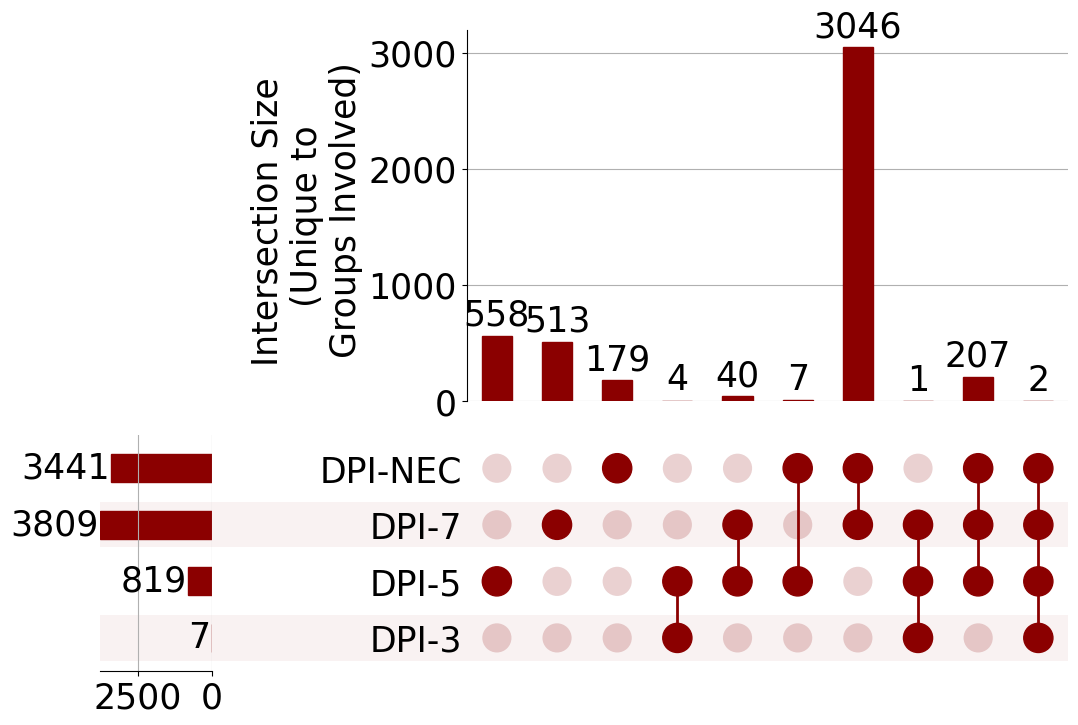

In [15]:
import os
import pandas as pd
from upsetplot import UpSet, from_contents
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import simpledialog

def filter_by_logfc(dataframes, threshold):
    filtered_data = {}
    for key, df in dataframes.items():
        upregulated = df[df['logFC'] > threshold]
        filtered_data[key] = upregulated
    return filtered_data

def ask_for_threshold():
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    threshold = simpledialog.askfloat('Input', 'Cross-MAS Analysis: Please enter the threshold for LogFC for upregulation analysis (i.e., LogFC > m):', parent=root)
    root.destroy()
    return threshold
threshold = ask_for_threshold()
upregulated_results = filter_by_logfc(ranked_dataframes, threshold)
dfs = []
group_names = []
upset_data = {}
for key, df in upregulated_results.items():
    new_key = key.replace('EdgeR_Significant_', '').replace('.csv', '')
    upset_data[new_key] = set(df['Gene Symbol'])
    dfs.append(df)
    group_names.append(new_key)
combined = from_contents(upset_data)
fig = plt.figure(figsize=(10, 4))
plt.rcParams.update({'font.size': 25, 'font.weight': 'normal', 'font.style': 'normal'})
upset = UpSet(combined, subset_size='count', element_size=60, show_counts=True, sort_categories_by=None, facecolor='darkred')
upset_ax = upset.plot(fig=fig)
for ax in fig.axes:
    if ax.get_ylabel() == '':
        for label in ax.get_yticklabels():
            label.set_fontsize(25)
            label.set_fontweight('normal')
plt.setp(plt.gca().get_yticklabels(), fontsize=25, fontweight='normal')
plt.gca().set_ylabel('Intersection Size \n (Unique to \n Groups Involved)', fontsize=25, fontweight='normal')
plt.show()


In [16]:
top_k = 10
top_genes_results = get_top_genes_by_mas_rank(dfs, group_names, top_k)
for combo, top_genes in top_genes_results.items():
    print(f'\nTop 10 genes for combination {combo}:')
    print(top_genes)
Upregulted_Ebola_vs_SarsCov2 = get_top_genes_by_mas_rank(dfs, group_names, 1000)



Top 10 genes for combination DPI-5:
['ZNF267', 'TRIM25', 'TRAFD1', 'HIRA', 'CSRNP1', 'PARP11', 'CMTR1', 'BST2', 'PHF11', 'SAMHD1']

Top 10 genes for combination DPI-7:
['ASB4', 'GNG13', 'PTPRO', 'PKD2L1', 'LOC698764', 'ALPP', 'TREH', 'SLC19A3', 'GJB1', 'PYY']

Top 10 genes for combination DPI-NEC:
['FAM219A', 'EDA2R', 'ADAM12', 'SUGCT', 'RPGRIP1', 'CASTOR2', 'SEMA4G', 'PAH', 'NOTCH4', 'EXPH5']

Top 10 genes for combination DPI-3, DPI-5:
['IFI16', 'STAT1', 'EPSTI1', 'FAM216B']

Top 10 genes for combination DPI-5, DPI-7:
['PPP1R3D', 'CD63', 'ARID5A', 'CD274', 'TIFA', 'CD93', 'SCARF1', 'FCER1G', 'ISG20', 'CMTM2']

Top 10 genes for combination DPI-5, DPI-NEC:
['ZDHHC14', 'RXRG', 'ARV1', 'CLEC6A', 'ESPL1', 'ACSL3', 'LDHC']

Top 10 genes for combination DPI-7, DPI-NEC:
['ESRP1', 'COLEC12', 'PTGIS', 'DCN', 'MARK1', 'SEC16B', 'SGSM1', 'PLAAT5', 'TNS4', 'MGARP']

Top 10 genes for combination DPI-3, DPI-5, DPI-7:
['PSME2']

Top 10 genes for combination DPI-5, DPI-7, DPI-NEC:
['FAM20A', 'XPNPEP2

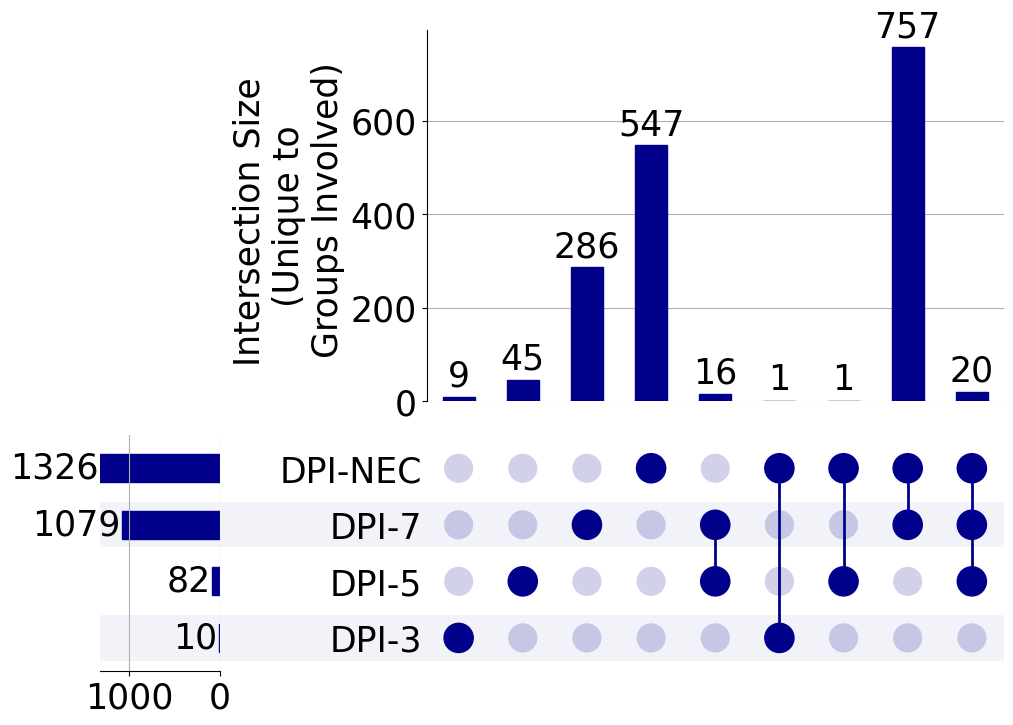

In [17]:
import os
import pandas as pd
from upsetplot import UpSet, from_contents
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import simpledialog

def filter_by_logfc(dataframes, threshold):
    filtered_data = {}
    for key, df in dataframes.items():
        upregulated = df[df['logFC'] < -threshold]
        filtered_data[key] = upregulated
    return filtered_data

def ask_for_threshold():
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    threshold = simpledialog.askfloat('Input', 'Cross-MAS Analysis: Please enter the threshold for LogFC for upregulation analysis (i.e., LogFC > m):', parent=root)
    root.destroy()
    return threshold
threshold = ask_for_threshold()
upregulated_results = filter_by_logfc(ranked_dataframes, threshold)
dfs = []
group_names = []
upset_data = {}
for key, df in upregulated_results.items():
    new_key = key.replace('EdgeR_Significant_', '').replace('.csv', '')
    upset_data[new_key] = set(df['Gene Symbol'])
    dfs.append(df)
    group_names.append(new_key)
combined = from_contents(upset_data)
fig = plt.figure(figsize=(10, 4))
plt.rcParams.update({'font.size': 25, 'font.weight': 'normal', 'font.style': 'normal'})
upset = UpSet(combined, subset_size='count', element_size=60, show_counts=True, sort_categories_by=None, facecolor='darkblue')
upset_ax = upset.plot(fig=fig)
for ax in fig.axes:
    if ax.get_ylabel() == '':
        for label in ax.get_yticklabels():
            label.set_fontsize(25)
            label.set_fontweight('normal')
plt.setp(plt.gca().get_yticklabels(), fontsize=25, fontweight='normal')
plt.gca().set_ylabel('Intersection Size \n (Unique to \n Groups Involved)', fontsize=25, fontweight='normal')
plt.show()


In [18]:
top_genes_results = get_top_genes_by_mas_rank(dfs, group_names, top_k)
for combo, top_genes in top_genes_results.items():
    print(f'\nTop 10 genes for combination {combo}:')
    print(top_genes)
Downregulted_Ebola_vs_MPXV = get_top_genes_by_mas_rank(dfs, group_names, 1000)



Top 10 genes for combination DPI-3:
['SLC5A10', 'CCDC106', 'CHRNG', 'PIGQ', 'M1AP', 'WNK4', 'RAI1', 'HR', 'B3GNT4']

Top 10 genes for combination DPI-5:
['VIPR1', 'IFFO2', 'STXBP6', 'SPNS3', 'PRDM11', 'TCN2', 'TPCN1', 'NBEA', 'CA8', 'IL5RA']

Top 10 genes for combination DPI-7:
['MICAL2', 'SPECC1L', 'CCDC15', 'HADH', 'STK39', 'WDR11', 'EFL1', 'SQLE', 'ANO6', 'TMEM273']

Top 10 genes for combination DPI-NEC:
['UBXN7', 'CD99', 'FAM120A', 'ARHGAP25', 'TSPAN33', 'NAP1L1', 'NCAPG', 'KCTD20', 'STK4', 'HSPA4']

Top 10 genes for combination DPI-3, DPI-NEC:
['TRIM17']

Top 10 genes for combination DPI-5, DPI-7:
['TGFBR3', 'DAAM1', 'GZMK', 'ADK', 'NCALD', 'PPFIBP2', 'STS', 'CCR3', 'SLC16A7', 'CD1B']

Top 10 genes for combination DPI-5, DPI-NEC:
['ZCCHC7']

Top 10 genes for combination DPI-7, DPI-NEC:
['SLC25A39', 'FAM53B', 'SESN3', 'ABHD12', 'FKBP8', 'AHR', 'GPX1', 'IVNS1ABP', 'KLF3', 'R3HDM4']

Top 10 genes for combination DPI-5, DPI-7, DPI-NEC:
['MFNG', 'SRPK2', 'PDE7A', 'ITGA4', 'AKT3', 'MAM

In [ ]:
import subprocess

def run_r_script():
    command = ['Rscript', 'DESeq2.R']
    result = subprocess.run(command, stdout=subprocess.PIPE, stderr=subprocess.PIPE, universal_newlines=True)
    if result.stdout:
        print('R script output:', result.stdout)
    if result.stderr:
        print('R script errors:', result.stderr)
if __name__ == '__main__':
    run_r_script()


In [20]:
import glob
import pandas as pd
import os

def read_csv_files_to_dict(directory):
    pattern = os.path.join(directory, 'DESeq2_DPI_0_vs_*.csv')
    csv_files = glob.glob(pattern)
    if not csv_files:
        print('No matching files found in the directory.')
        return {}
    dataframes_dict = {}
    for file in csv_files:
        try:
            file_name = os.path.splitext(os.path.basename(file))[0]
            df = pd.read_csv(file)
            globals()[file_name] = df
            dataframes_dict[file_name] = df
            print(f'Loaded DataFrame: {file_name} from {file}')
        except Exception as e:
            print(f'Error reading file {file}: {e}')
    return dataframes_dict
if __name__ == '__main__':
    current_directory = './'
    dataframes = read_csv_files_to_dict(current_directory)
    print('\nAccessing DataFrames:')
    for file_name, df in dataframes.items():
        print(f'\nDataFrame: {file_name}')
        print(df.head())


Loaded DataFrame: DESeq2_DPI_0_vs_DPI_3_with_FDR_and_Bonferroni from .\DESeq2_DPI_0_vs_DPI_3_with_FDR_and_Bonferroni.csv
Loaded DataFrame: DESeq2_DPI_0_vs_DPI_5_with_FDR_and_Bonferroni from .\DESeq2_DPI_0_vs_DPI_5_with_FDR_and_Bonferroni.csv
Loaded DataFrame: DESeq2_DPI_0_vs_DPI_7_with_FDR_and_Bonferroni from .\DESeq2_DPI_0_vs_DPI_7_with_FDR_and_Bonferroni.csv
Loaded DataFrame: DESeq2_DPI_0_vs_DPI_NEC_with_FDR_and_Bonferroni from .\DESeq2_DPI_0_vs_DPI_NEC_with_FDR_and_Bonferroni.csv

Accessing DataFrames:

DataFrame: DESeq2_DPI_0_vs_DPI_3_with_FDR_and_Bonferroni
  GeneSymbol     baseMean     logFC     lfcSE      stat        PValue  \
0      IFIT5  1043.391523  2.590032  0.343601  7.537907  4.775756e-14   
1     FAM53B  1717.881891 -0.849801  0.118280 -7.184645  6.738213e-13   
2     TRIM17    36.872293 -1.297867  0.183006 -7.091931  1.322534e-12   
3     EPSTI1  4754.593483  2.121289  0.310952  6.821910  8.983782e-12   
4       ACO1  1108.342452  2.049077  0.300910  6.809595  9.787393e

C:\Users\13367\AppData\Local\Temp\ipykernel_38220\3543918782.py:37: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  upregulated_patch = mpatches.Patch(color='pink', label='Upregulated', edgecolor='black', alpha=0.6)
C:\Users\13367\AppData\Local\Temp\ipykernel_38220\3543918782.py:38: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  downregulated_patch = mpatches.Patch(color='lightblue', label='Downregulated', edgecolor='black', alpha=0.6)
C:\Users\13367\AppData\Local\Temp\ipykernel_38220\3543918782.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


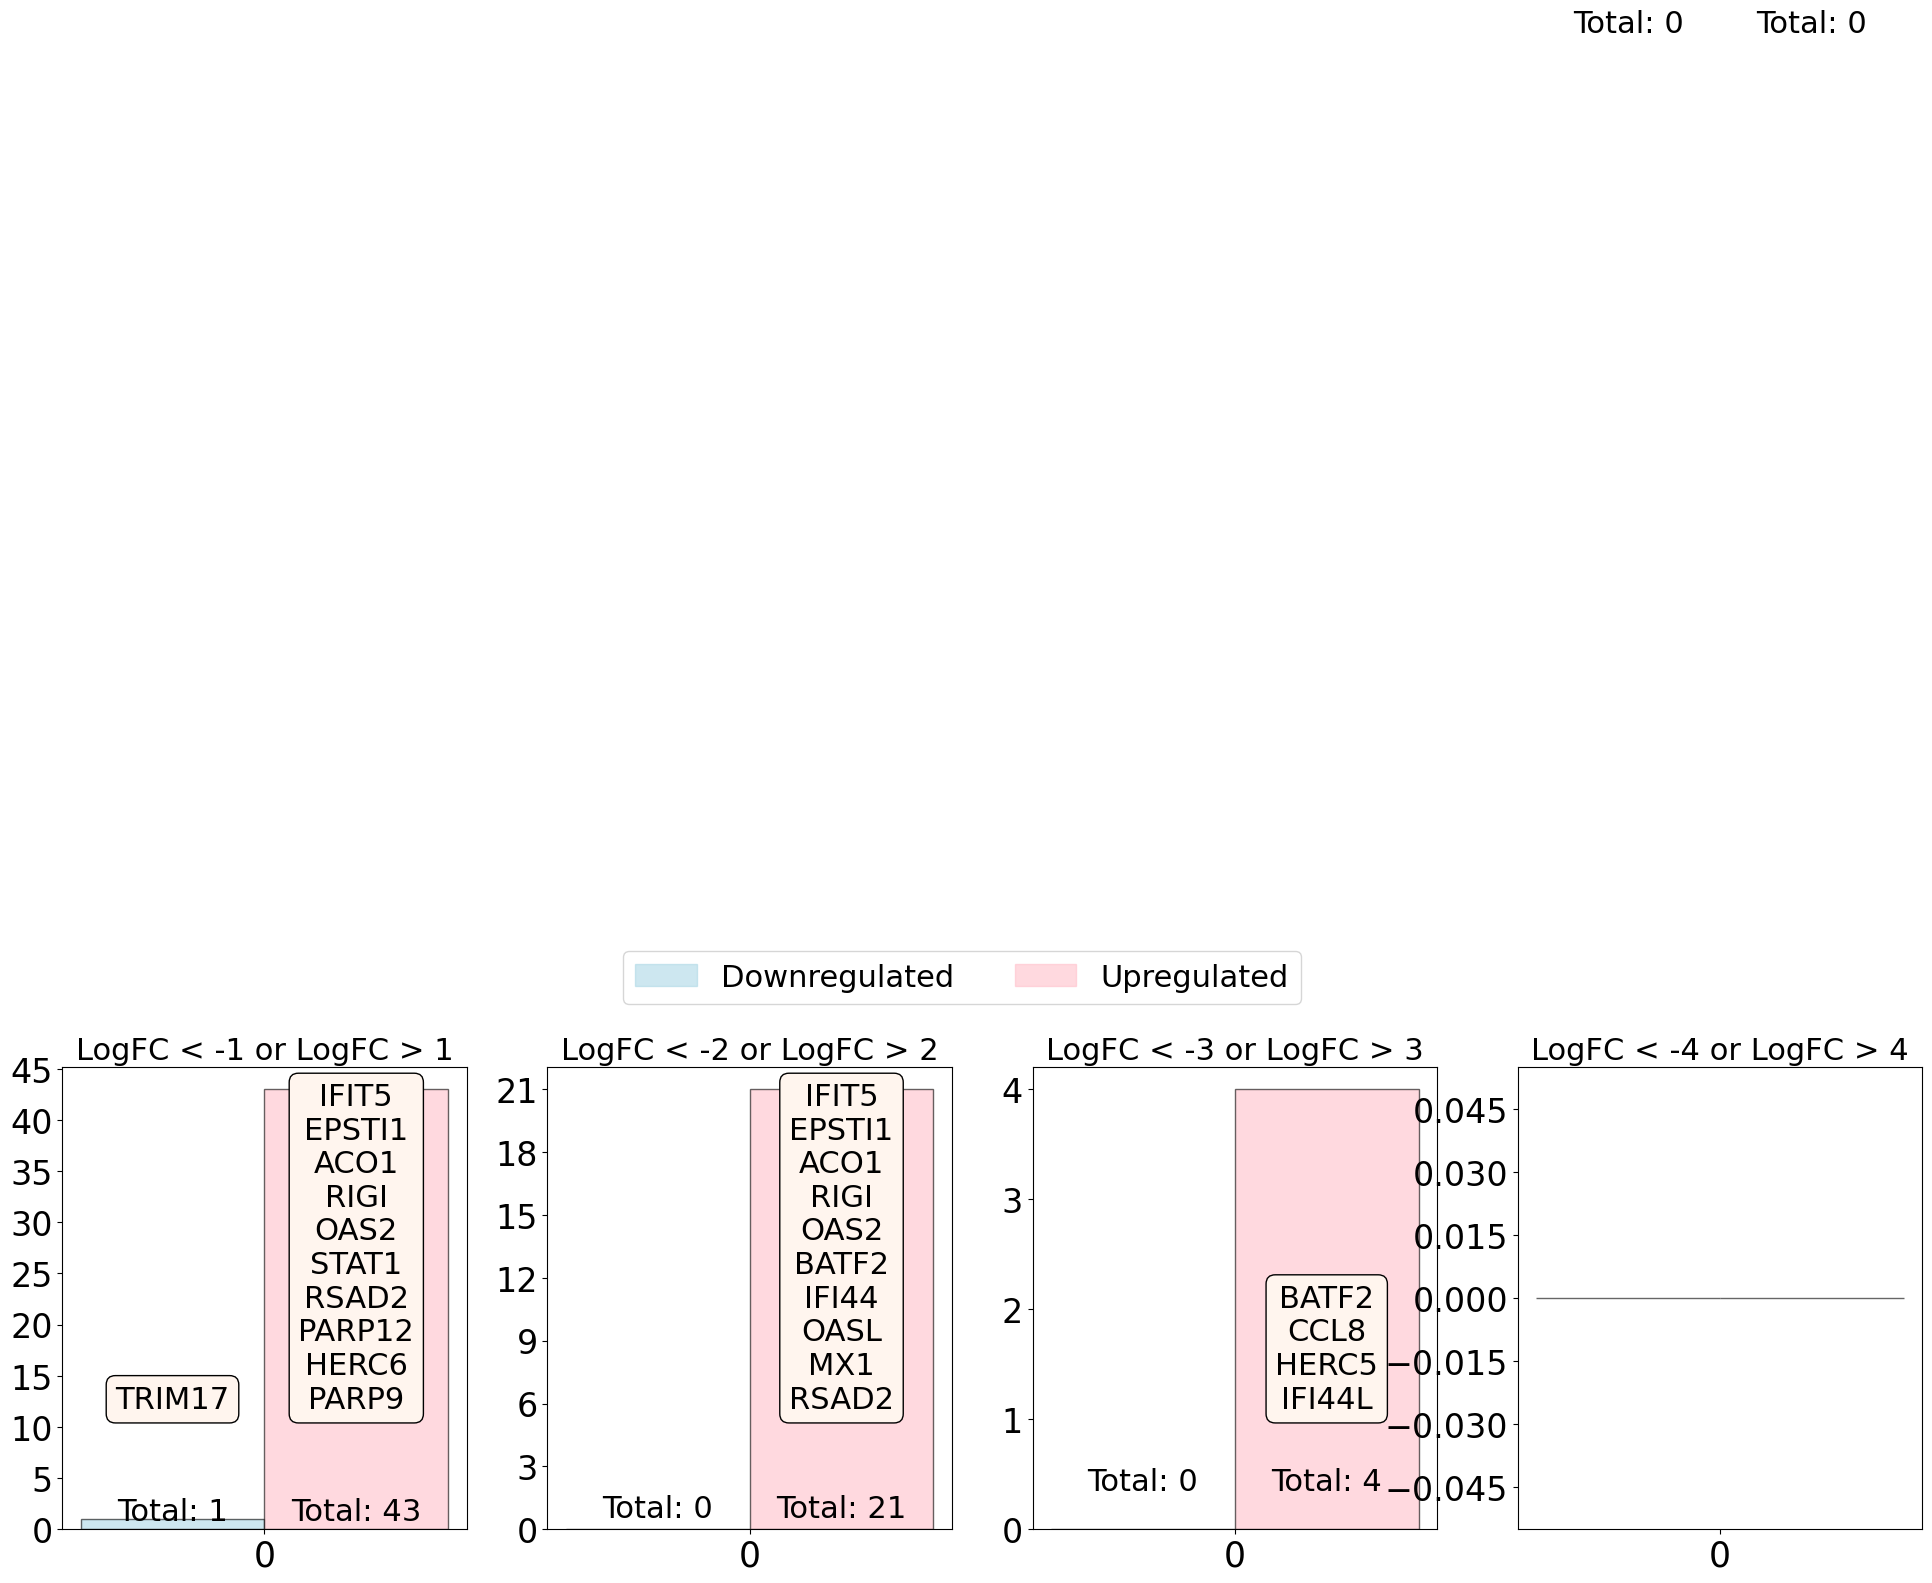

In [21]:
Data = dataframes['DESeq2_DPI_0_vs_DPI_3_with_FDR_and_Bonferroni']
Data.rename(columns={'GeneSymbol': 'Gene Symbol'}, inplace=True)
title = 'DESeq2_DPI_0_vs_DPI_3_with_FDR_and_Bonferroni'
config_Upset = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
AllGenes_DE_HLTY_vs_SARS_CoV_2, Significant_DE_HLTY_vs_SARS_CoV_2 = volcano_plot_no_visualization(Data, M=config_Upset['Magnitude (M)'], A=config_Upset['Altitude (A)'], title=title, method=config_Upset['method'], alpha=config_Upset['alpha'], logFC_threshold=config_Upset['logFC_threshold'], highlight_genes=config_Upset['highlight_genes'], top_genes=config_Upset['top_genes'], upreg_criteria=config_Upset['upreg_criteria'], downreg_criteria=config_Upset['downreg_criteria'], upregulated_color=config_Upset['upregulated_color'], downregulated_color=config_Upset['downregulated_color'], not_significant_color=config_Upset['not_significant_color'], not_significant_between_logFC_threshold_color=config_Upset['not_significant_between_logFC_threshold_color'], pie_chart_size=config_Upset['pie_chart_size'], pie_chart_position=config_Upset['pie_chart_position'], ranking_method=config_Upset['ranking_method'], up_or_down_or_both=config_Upset['up_or_down_or_both'], g100=config_Upset['g100'], g010=config_Upset['g010'], g001=config_Upset['g001'], g110=config_Upset['g110'], g101=config_Upset['g101'], g011=config_Upset['g011'], g111=config_Upset['g111'])
config = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
logFC_threshold_values = range(1, 5)
fig, axs = plt.subplots(1, 4, figsize=(24, 6))
axs = axs.flatten()
title_font = {'family': 'serif', 'color': 'darkred', 'weight': 'bold', 'size': 24}
label_font = {'family': 'arial', 'color': 'navy', 'weight': 'bold', 'size': 24}
title_font2 = {'family': 'serif', 'color': 'black', 'size': 24}
for idx, logFC_threshold in enumerate(logFC_threshold_values):
    ax = axs[idx]
    config['logFC_threshold'] = logFC_threshold
    AllGenes, Significant = volcano_plot_no_visualization(Data, M=config['Magnitude (M)'], A=config['Altitude (A)'], title=title, method=config['method'], alpha=config['alpha'], logFC_threshold=config['logFC_threshold'], highlight_genes=config['highlight_genes'], top_genes=config['top_genes'], upreg_criteria=config['upreg_criteria'], downreg_criteria=config['downreg_criteria'], upregulated_color=config['upregulated_color'], downregulated_color=config['downregulated_color'], not_significant_color=config['not_significant_color'], not_significant_between_logFC_threshold_color=config['not_significant_between_logFC_threshold_color'], pie_chart_size=config['pie_chart_size'], pie_chart_position=config['pie_chart_position'], ranking_method=config['ranking_method'], up_or_down_or_both=config['up_or_down_or_both'], g100=config['g100'], g010=config['g010'], g001=config['g001'], g110=config['g110'], g101=config['g101'], g011=config['g011'], g111=config['g111'])
    upregulated_counts = Significant[Significant['Category'] == 'Upregulated'].shape[0]
    downregulated_counts = Significant[Significant['Category'] == 'Downregulated'].shape[0]
    positions = np.arange(1)
    width = 1
    ax.bar(positions - width / 2, downregulated_counts, width, label='Downregulated', color='lightblue', edgecolor='black', alpha=0.6)
    ax.bar(positions + width / 2, upregulated_counts, width, label='Upregulated', color='pink', edgecolor='black', alpha=0.6)
    if logFC_threshold == 0:
        title = f'LogFC < {logFC_threshold} or LogFC > {logFC_threshold}'
    else:
        title = f'LogFC < -{logFC_threshold} or LogFC > {logFC_threshold}'
    ax.set_title(title, fontsize=22)
    ax.set_xticks(positions)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis='y', labelsize=24)
    top_10_down_genes = {'BH': Significant[Significant['logFC'] < 0].head(10)['Gene Symbol'].tolist()}
    top_10_up_genes = {'BH': Significant[Significant['logFC'] > 0].head(10)['Gene Symbol'].tolist()}
    summary_stats = {'BH': {'Total': Significant.shape[0], 'Upregulated': Significant[Significant['Category'] == 'Upregulated'].shape[0], 'Downregulated': Significant[Significant['Category'] == 'Downregulated'].shape[0]}}
    upregulated_counts = [summary_stats[obj]['Upregulated'] for obj in summary_stats]
    downregulated_counts = [summary_stats[obj]['Downregulated'] for obj in summary_stats]
    annotate_bars_vertical_with_totals(ax, positions, top_10_down_genes, top_10_up_genes, upregulated_counts, downregulated_counts, width)
upregulated_patch = mpatches.Patch(color='pink', label='Upregulated', edgecolor='black', alpha=0.6)
downregulated_patch = mpatches.Patch(color='lightblue', label='Downregulated', edgecolor='black', alpha=0.6)
fig.legend(handles=[downregulated_patch, upregulated_patch], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.1), fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
Bonferroni_Upregulated = Significant_DE_HLTY_vs_SARS_CoV_2[Significant_DE_HLTY_vs_SARS_CoV_2['logFC'] > 1]
Bonferroni_Downregulated = Significant_DE_HLTY_vs_SARS_CoV_2[Significant_DE_HLTY_vs_SARS_CoV_2['logFC'] < -1]
Bonferroni_Significant = Significant_DE_HLTY_vs_SARS_CoV_2.copy()
Bonferroni_Upregulated.to_csv('DESeq2_Upregulated_DPI-3.csv', index=False)
Bonferroni_Downregulated.to_csv('DESeq2_Downregulated_DPI-3.csv', index=False)
Bonferroni_Significant.to_csv('DESeq2_Significant_DPI-3.csv', index=False)


C:\Users\13367\AppData\Local\Temp\ipykernel_38220\3661568240.py:37: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  upregulated_patch = mpatches.Patch(color='pink', label='Upregulated', edgecolor='black', alpha=0.6)
C:\Users\13367\AppData\Local\Temp\ipykernel_38220\3661568240.py:38: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  downregulated_patch = mpatches.Patch(color='lightblue', label='Downregulated', edgecolor='black', alpha=0.6)


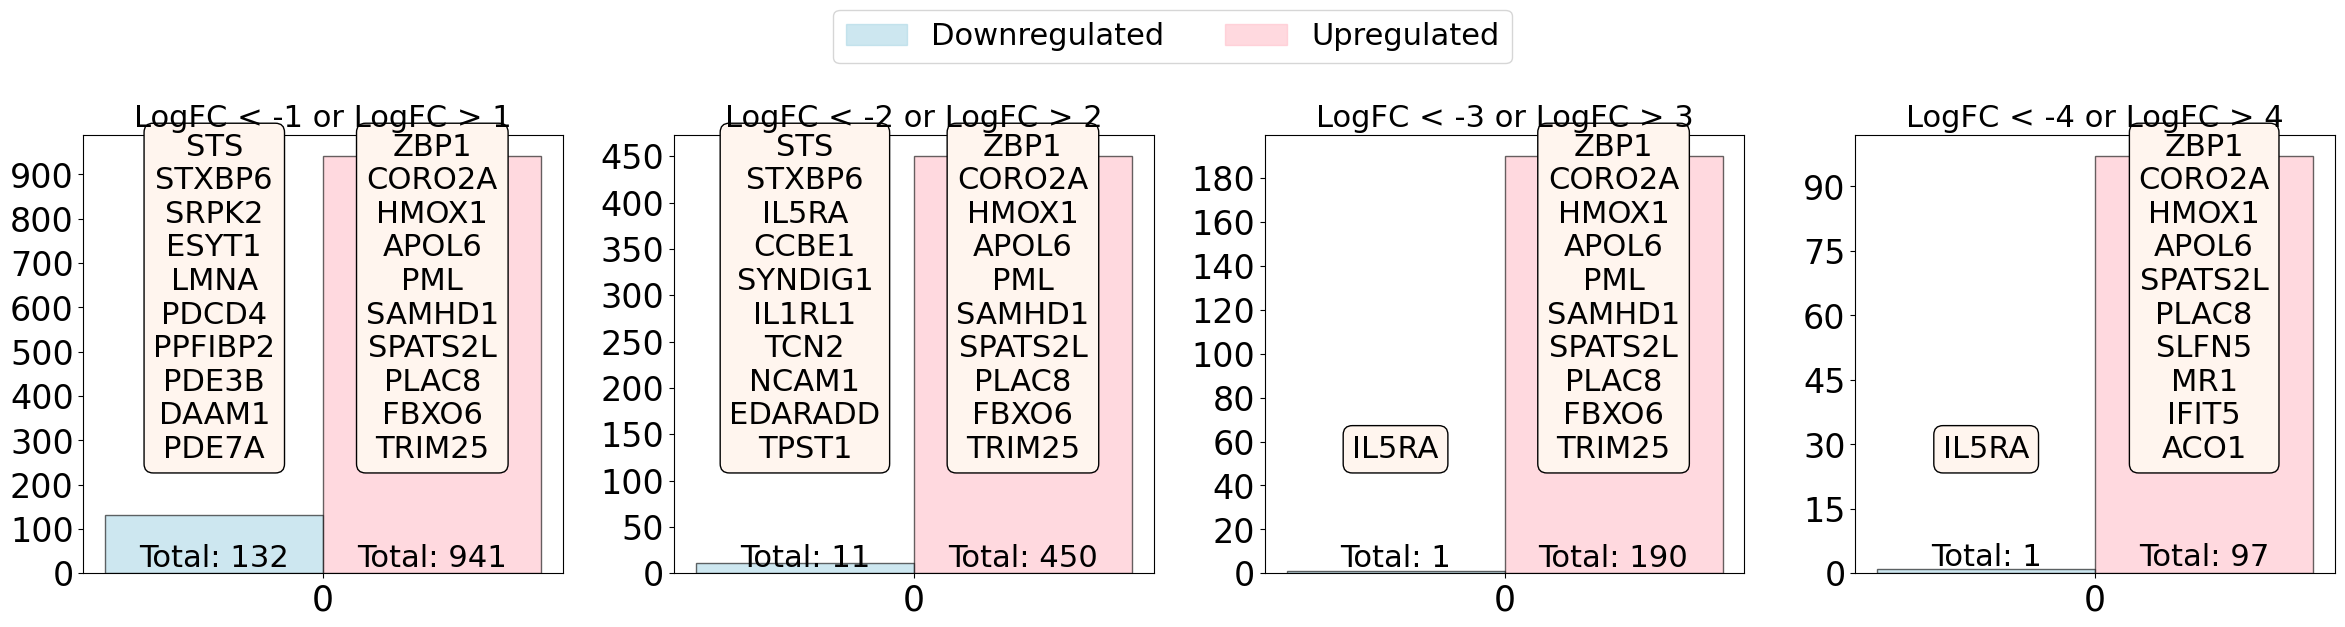

In [22]:
Data = dataframes['DESeq2_DPI_0_vs_DPI_5_with_FDR_and_Bonferroni']
Data.rename(columns={'GeneSymbol': 'Gene Symbol'}, inplace=True)
title = 'DESeq2_DPI_0_vs_DPI_5_with_FDR_and_Bonferroni'
config_Upset = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
AllGenes_DE_HLTY_vs_SARS_CoV_2, Significant_DE_HLTY_vs_SARS_CoV_2 = volcano_plot_no_visualization(Data, M=config_Upset['Magnitude (M)'], A=config_Upset['Altitude (A)'], title=title, method=config_Upset['method'], alpha=config_Upset['alpha'], logFC_threshold=config_Upset['logFC_threshold'], highlight_genes=config_Upset['highlight_genes'], top_genes=config_Upset['top_genes'], upreg_criteria=config_Upset['upreg_criteria'], downreg_criteria=config_Upset['downreg_criteria'], upregulated_color=config_Upset['upregulated_color'], downregulated_color=config_Upset['downregulated_color'], not_significant_color=config_Upset['not_significant_color'], not_significant_between_logFC_threshold_color=config_Upset['not_significant_between_logFC_threshold_color'], pie_chart_size=config_Upset['pie_chart_size'], pie_chart_position=config_Upset['pie_chart_position'], ranking_method=config_Upset['ranking_method'], up_or_down_or_both=config_Upset['up_or_down_or_both'], g100=config_Upset['g100'], g010=config_Upset['g010'], g001=config_Upset['g001'], g110=config_Upset['g110'], g101=config_Upset['g101'], g011=config_Upset['g011'], g111=config_Upset['g111'])
config = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
logFC_threshold_values = range(1, 5)
fig, axs = plt.subplots(1, 4, figsize=(24, 6))
axs = axs.flatten()
title_font = {'family': 'serif', 'color': 'darkred', 'weight': 'bold', 'size': 24}
label_font = {'family': 'arial', 'color': 'navy', 'weight': 'bold', 'size': 24}
title_font2 = {'family': 'serif', 'color': 'black', 'size': 24}
for idx, logFC_threshold in enumerate(logFC_threshold_values):
    ax = axs[idx]
    config['logFC_threshold'] = logFC_threshold
    AllGenes, Significant = volcano_plot_no_visualization(Data, M=config['Magnitude (M)'], A=config['Altitude (A)'], title=title, method=config['method'], alpha=config['alpha'], logFC_threshold=config['logFC_threshold'], highlight_genes=config['highlight_genes'], top_genes=config['top_genes'], upreg_criteria=config['upreg_criteria'], downreg_criteria=config['downreg_criteria'], upregulated_color=config['upregulated_color'], downregulated_color=config['downregulated_color'], not_significant_color=config['not_significant_color'], not_significant_between_logFC_threshold_color=config['not_significant_between_logFC_threshold_color'], pie_chart_size=config['pie_chart_size'], pie_chart_position=config['pie_chart_position'], ranking_method=config['ranking_method'], up_or_down_or_both=config['up_or_down_or_both'], g100=config['g100'], g010=config['g010'], g001=config['g001'], g110=config['g110'], g101=config['g101'], g011=config['g011'], g111=config['g111'])
    upregulated_counts = Significant[Significant['Category'] == 'Upregulated'].shape[0]
    downregulated_counts = Significant[Significant['Category'] == 'Downregulated'].shape[0]
    positions = np.arange(1)
    width = 1
    ax.bar(positions - width / 2, downregulated_counts, width, label='Downregulated', color='lightblue', edgecolor='black', alpha=0.6)
    ax.bar(positions + width / 2, upregulated_counts, width, label='Upregulated', color='pink', edgecolor='black', alpha=0.6)
    if logFC_threshold == 0:
        title = f'LogFC < {logFC_threshold} or LogFC > {logFC_threshold}'
    else:
        title = f'LogFC < -{logFC_threshold} or LogFC > {logFC_threshold}'
    ax.set_title(title, fontsize=22)
    ax.set_xticks(positions)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis='y', labelsize=24)
    top_10_down_genes = {'BH': Significant[Significant['logFC'] < 0].head(10)['Gene Symbol'].tolist()}
    top_10_up_genes = {'BH': Significant[Significant['logFC'] > 0].head(10)['Gene Symbol'].tolist()}
    summary_stats = {'BH': {'Total': Significant.shape[0], 'Upregulated': Significant[Significant['Category'] == 'Upregulated'].shape[0], 'Downregulated': Significant[Significant['Category'] == 'Downregulated'].shape[0]}}
    upregulated_counts = [summary_stats[obj]['Upregulated'] for obj in summary_stats]
    downregulated_counts = [summary_stats[obj]['Downregulated'] for obj in summary_stats]
    annotate_bars_vertical_with_totals(ax, positions, top_10_down_genes, top_10_up_genes, upregulated_counts, downregulated_counts, width)
upregulated_patch = mpatches.Patch(color='pink', label='Upregulated', edgecolor='black', alpha=0.6)
downregulated_patch = mpatches.Patch(color='lightblue', label='Downregulated', edgecolor='black', alpha=0.6)
fig.legend(handles=[downregulated_patch, upregulated_patch], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.1), fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
Bonferroni_Upregulated = Significant_DE_HLTY_vs_SARS_CoV_2[Significant_DE_HLTY_vs_SARS_CoV_2['logFC'] > 1]
Bonferroni_Downregulated = Significant_DE_HLTY_vs_SARS_CoV_2[Significant_DE_HLTY_vs_SARS_CoV_2['logFC'] < -1]
Bonferroni_Significant = Significant_DE_HLTY_vs_SARS_CoV_2.copy()
Bonferroni_Upregulated.to_csv('DESeq2_Upregulated_DPI-5.csv', index=False)
Bonferroni_Downregulated.to_csv('DESeq2_Downregulated_DPI-5.csv', index=False)
Bonferroni_Significant.to_csv('DESeq2_Significant_DPI-5.csv', index=False)


C:\Users\13367\AppData\Local\Temp\ipykernel_38220\849553508.py:37: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  upregulated_patch = mpatches.Patch(color='pink', label='Upregulated', edgecolor='black', alpha=0.6)
C:\Users\13367\AppData\Local\Temp\ipykernel_38220\849553508.py:38: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  downregulated_patch = mpatches.Patch(color='lightblue', label='Downregulated', edgecolor='black', alpha=0.6)


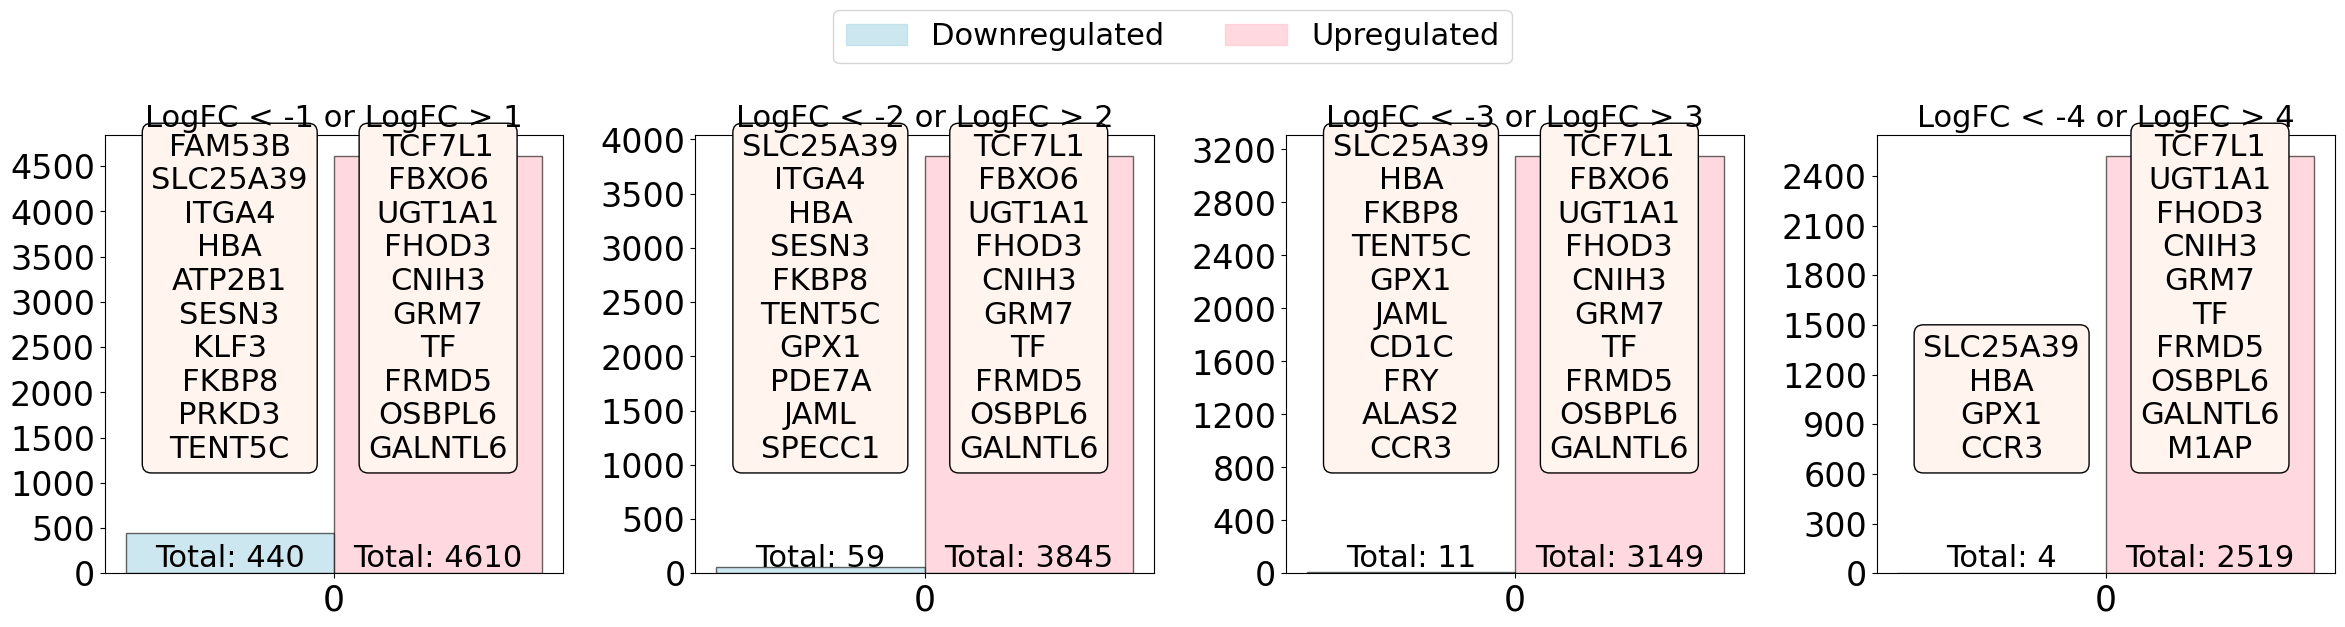

In [23]:
Data = dataframes['DESeq2_DPI_0_vs_DPI_7_with_FDR_and_Bonferroni']
Data.rename(columns={'GeneSymbol': 'Gene Symbol'}, inplace=True)
title = 'DESeq2_DPI_0_vs_DPI_7_with_FDR_and_Bonferroni'
config_Upset = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
AllGenes_DE_HLTY_vs_SARS_CoV_2, Significant_DE_HLTY_vs_SARS_CoV_2 = volcano_plot_no_visualization(Data, M=config_Upset['Magnitude (M)'], A=config_Upset['Altitude (A)'], title=title, method=config_Upset['method'], alpha=config_Upset['alpha'], logFC_threshold=config_Upset['logFC_threshold'], highlight_genes=config_Upset['highlight_genes'], top_genes=config_Upset['top_genes'], upreg_criteria=config_Upset['upreg_criteria'], downreg_criteria=config_Upset['downreg_criteria'], upregulated_color=config_Upset['upregulated_color'], downregulated_color=config_Upset['downregulated_color'], not_significant_color=config_Upset['not_significant_color'], not_significant_between_logFC_threshold_color=config_Upset['not_significant_between_logFC_threshold_color'], pie_chart_size=config_Upset['pie_chart_size'], pie_chart_position=config_Upset['pie_chart_position'], ranking_method=config_Upset['ranking_method'], up_or_down_or_both=config_Upset['up_or_down_or_both'], g100=config_Upset['g100'], g010=config_Upset['g010'], g001=config_Upset['g001'], g110=config_Upset['g110'], g101=config_Upset['g101'], g011=config_Upset['g011'], g111=config_Upset['g111'])
config = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
logFC_threshold_values = range(1, 5)
fig, axs = plt.subplots(1, 4, figsize=(24, 6))
axs = axs.flatten()
title_font = {'family': 'serif', 'color': 'darkred', 'weight': 'bold', 'size': 24}
label_font = {'family': 'arial', 'color': 'navy', 'weight': 'bold', 'size': 24}
title_font2 = {'family': 'serif', 'color': 'black', 'size': 24}
for idx, logFC_threshold in enumerate(logFC_threshold_values):
    ax = axs[idx]
    config['logFC_threshold'] = logFC_threshold
    AllGenes, Significant = volcano_plot_no_visualization(Data, M=config['Magnitude (M)'], A=config['Altitude (A)'], title=title, method=config['method'], alpha=config['alpha'], logFC_threshold=config['logFC_threshold'], highlight_genes=config['highlight_genes'], top_genes=config['top_genes'], upreg_criteria=config['upreg_criteria'], downreg_criteria=config['downreg_criteria'], upregulated_color=config['upregulated_color'], downregulated_color=config['downregulated_color'], not_significant_color=config['not_significant_color'], not_significant_between_logFC_threshold_color=config['not_significant_between_logFC_threshold_color'], pie_chart_size=config['pie_chart_size'], pie_chart_position=config['pie_chart_position'], ranking_method=config['ranking_method'], up_or_down_or_both=config['up_or_down_or_both'], g100=config['g100'], g010=config['g010'], g001=config['g001'], g110=config['g110'], g101=config['g101'], g011=config['g011'], g111=config['g111'])
    upregulated_counts = Significant[Significant['Category'] == 'Upregulated'].shape[0]
    downregulated_counts = Significant[Significant['Category'] == 'Downregulated'].shape[0]
    positions = np.arange(1)
    width = 1
    ax.bar(positions - width / 2, downregulated_counts, width, label='Downregulated', color='lightblue', edgecolor='black', alpha=0.6)
    ax.bar(positions + width / 2, upregulated_counts, width, label='Upregulated', color='pink', edgecolor='black', alpha=0.6)
    if logFC_threshold == 0:
        title = f'LogFC < {logFC_threshold} or LogFC > {logFC_threshold}'
    else:
        title = f'LogFC < -{logFC_threshold} or LogFC > {logFC_threshold}'
    ax.set_title(title, fontsize=22)
    ax.set_xticks(positions)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis='y', labelsize=24)
    top_10_down_genes = {'BH': Significant[Significant['logFC'] < 0].head(10)['Gene Symbol'].tolist()}
    top_10_up_genes = {'BH': Significant[Significant['logFC'] > 0].head(10)['Gene Symbol'].tolist()}
    summary_stats = {'BH': {'Total': Significant.shape[0], 'Upregulated': Significant[Significant['Category'] == 'Upregulated'].shape[0], 'Downregulated': Significant[Significant['Category'] == 'Downregulated'].shape[0]}}
    upregulated_counts = [summary_stats[obj]['Upregulated'] for obj in summary_stats]
    downregulated_counts = [summary_stats[obj]['Downregulated'] for obj in summary_stats]
    annotate_bars_vertical_with_totals(ax, positions, top_10_down_genes, top_10_up_genes, upregulated_counts, downregulated_counts, width)
upregulated_patch = mpatches.Patch(color='pink', label='Upregulated', edgecolor='black', alpha=0.6)
downregulated_patch = mpatches.Patch(color='lightblue', label='Downregulated', edgecolor='black', alpha=0.6)
fig.legend(handles=[downregulated_patch, upregulated_patch], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.1), fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
Bonferroni_Upregulated = Significant_DE_HLTY_vs_SARS_CoV_2[Significant_DE_HLTY_vs_SARS_CoV_2['logFC'] > 1]
Bonferroni_Downregulated = Significant_DE_HLTY_vs_SARS_CoV_2[Significant_DE_HLTY_vs_SARS_CoV_2['logFC'] < -1]
Bonferroni_Significant = Significant_DE_HLTY_vs_SARS_CoV_2.copy()
Bonferroni_Upregulated.to_csv('DESeq2_Upregulated_DPI-7.csv', index=False)
Bonferroni_Downregulated.to_csv('DESeq2_Downregulated_DPI-7.csv', index=False)
Bonferroni_Significant.to_csv('DESeq2_Significant_DPI-7.csv', index=False)


C:\Users\13367\AppData\Local\Temp\ipykernel_38220\3166128094.py:37: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  upregulated_patch = mpatches.Patch(color='pink', label='Upregulated', edgecolor='black', alpha=0.6)
C:\Users\13367\AppData\Local\Temp\ipykernel_38220\3166128094.py:38: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  downregulated_patch = mpatches.Patch(color='lightblue', label='Downregulated', edgecolor='black', alpha=0.6)


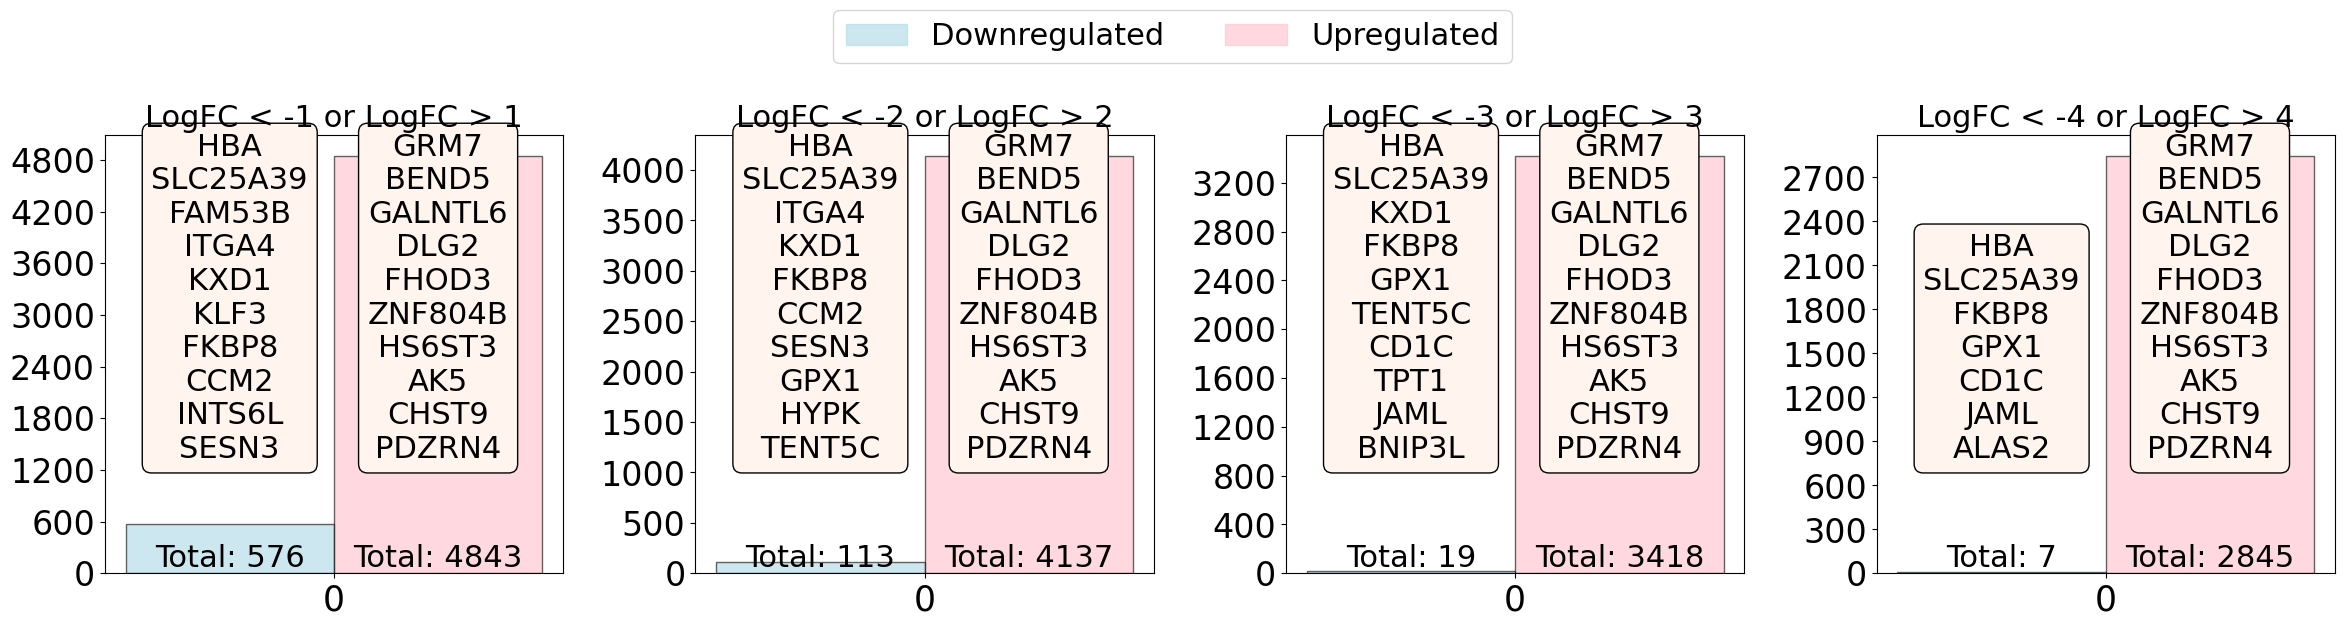

In [24]:
Data = dataframes['DESeq2_DPI_0_vs_DPI_NEC_with_FDR_and_Bonferroni']
Data.rename(columns={'GeneSymbol': 'Gene Symbol'}, inplace=True)
title = 'DESeq2_DPI_0_vs_DPI_NEC_with_FDR_and_Bonferroni'
config_Upset = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
AllGenes_DE_HLTY_vs_SARS_CoV_2, Significant_DE_HLTY_vs_SARS_CoV_2 = volcano_plot_no_visualization(Data, M=config_Upset['Magnitude (M)'], A=config_Upset['Altitude (A)'], title=title, method=config_Upset['method'], alpha=config_Upset['alpha'], logFC_threshold=config_Upset['logFC_threshold'], highlight_genes=config_Upset['highlight_genes'], top_genes=config_Upset['top_genes'], upreg_criteria=config_Upset['upreg_criteria'], downreg_criteria=config_Upset['downreg_criteria'], upregulated_color=config_Upset['upregulated_color'], downregulated_color=config_Upset['downregulated_color'], not_significant_color=config_Upset['not_significant_color'], not_significant_between_logFC_threshold_color=config_Upset['not_significant_between_logFC_threshold_color'], pie_chart_size=config_Upset['pie_chart_size'], pie_chart_position=config_Upset['pie_chart_position'], ranking_method=config_Upset['ranking_method'], up_or_down_or_both=config_Upset['up_or_down_or_both'], g100=config_Upset['g100'], g010=config_Upset['g010'], g001=config_Upset['g001'], g110=config_Upset['g110'], g101=config_Upset['g101'], g011=config_Upset['g011'], g111=config_Upset['g111'])
config = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
logFC_threshold_values = range(1, 5)
fig, axs = plt.subplots(1, 4, figsize=(24, 6))
axs = axs.flatten()
title_font = {'family': 'serif', 'color': 'darkred', 'weight': 'bold', 'size': 24}
label_font = {'family': 'arial', 'color': 'navy', 'weight': 'bold', 'size': 24}
title_font2 = {'family': 'serif', 'color': 'black', 'size': 24}
for idx, logFC_threshold in enumerate(logFC_threshold_values):
    ax = axs[idx]
    config['logFC_threshold'] = logFC_threshold
    AllGenes, Significant = volcano_plot_no_visualization(Data, M=config['Magnitude (M)'], A=config['Altitude (A)'], title=title, method=config['method'], alpha=config['alpha'], logFC_threshold=config['logFC_threshold'], highlight_genes=config['highlight_genes'], top_genes=config['top_genes'], upreg_criteria=config['upreg_criteria'], downreg_criteria=config['downreg_criteria'], upregulated_color=config['upregulated_color'], downregulated_color=config['downregulated_color'], not_significant_color=config['not_significant_color'], not_significant_between_logFC_threshold_color=config['not_significant_between_logFC_threshold_color'], pie_chart_size=config['pie_chart_size'], pie_chart_position=config['pie_chart_position'], ranking_method=config['ranking_method'], up_or_down_or_both=config['up_or_down_or_both'], g100=config['g100'], g010=config['g010'], g001=config['g001'], g110=config['g110'], g101=config['g101'], g011=config['g011'], g111=config['g111'])
    upregulated_counts = Significant[Significant['Category'] == 'Upregulated'].shape[0]
    downregulated_counts = Significant[Significant['Category'] == 'Downregulated'].shape[0]
    positions = np.arange(1)
    width = 1
    ax.bar(positions - width / 2, downregulated_counts, width, label='Downregulated', color='lightblue', edgecolor='black', alpha=0.6)
    ax.bar(positions + width / 2, upregulated_counts, width, label='Upregulated', color='pink', edgecolor='black', alpha=0.6)
    if logFC_threshold == 0:
        title = f'LogFC < {logFC_threshold} or LogFC > {logFC_threshold}'
    else:
        title = f'LogFC < -{logFC_threshold} or LogFC > {logFC_threshold}'
    ax.set_title(title, fontsize=22)
    ax.set_xticks(positions)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis='y', labelsize=24)
    top_10_down_genes = {'BH': Significant[Significant['logFC'] < 0].head(10)['Gene Symbol'].tolist()}
    top_10_up_genes = {'BH': Significant[Significant['logFC'] > 0].head(10)['Gene Symbol'].tolist()}
    summary_stats = {'BH': {'Total': Significant.shape[0], 'Upregulated': Significant[Significant['Category'] == 'Upregulated'].shape[0], 'Downregulated': Significant[Significant['Category'] == 'Downregulated'].shape[0]}}
    upregulated_counts = [summary_stats[obj]['Upregulated'] for obj in summary_stats]
    downregulated_counts = [summary_stats[obj]['Downregulated'] for obj in summary_stats]
    annotate_bars_vertical_with_totals(ax, positions, top_10_down_genes, top_10_up_genes, upregulated_counts, downregulated_counts, width)
upregulated_patch = mpatches.Patch(color='pink', label='Upregulated', edgecolor='black', alpha=0.6)
downregulated_patch = mpatches.Patch(color='lightblue', label='Downregulated', edgecolor='black', alpha=0.6)
fig.legend(handles=[downregulated_patch, upregulated_patch], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.1), fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
Bonferroni_Upregulated = Significant_DE_HLTY_vs_SARS_CoV_2[Significant_DE_HLTY_vs_SARS_CoV_2['logFC'] > 1]
Bonferroni_Downregulated = Significant_DE_HLTY_vs_SARS_CoV_2[Significant_DE_HLTY_vs_SARS_CoV_2['logFC'] < -1]
Bonferroni_Significant = Significant_DE_HLTY_vs_SARS_CoV_2.copy()
Bonferroni_Upregulated.to_csv('DESeq2_Upregulated_DPI-NEC.csv', index=False)
Bonferroni_Downregulated.to_csv('DESeq2_Downregulated_DPI-NEC.csv', index=False)
Bonferroni_Significant.to_csv('DESeq2_Significant_DPI-NEC.csv', index=False)


In [25]:
import glob
import pandas as pd
import os

def read_csv_files_to_dict(directory):
    pattern = os.path.join(directory, 'DESeq2_Significant_*.csv')
    csv_files = glob.glob(pattern)
    if not csv_files:
        print('No matching files found in the directory.')
        return {}
    dataframes_dict = {}
    for file in csv_files:
        try:
            file_name = os.path.splitext(os.path.basename(file))[0]
            df = pd.read_csv(file)
            globals()[file_name] = df
            dataframes_dict[file_name] = df
            print(f'Loaded DataFrame: {file_name} from {file}')
        except Exception as e:
            print(f'Error reading file {file}: {e}')
    return dataframes_dict
if __name__ == '__main__':
    current_directory = './'
    ranked_dataframes = read_csv_files_to_dict(current_directory)
    print('\nAccessing DataFrames:')
    for file_name, df in ranked_dataframes.items():
        print(f'\nDataFrame: {file_name}')
        print(df.head())


Loaded DataFrame: DESeq2_Significant_DPI-3 from .\DESeq2_Significant_DPI-3.csv
Loaded DataFrame: DESeq2_Significant_DPI-5 from .\DESeq2_Significant_DPI-5.csv
Loaded DataFrame: DESeq2_Significant_DPI-7 from .\DESeq2_Significant_DPI-7.csv
Loaded DataFrame: DESeq2_Significant_DPI-NEC from .\DESeq2_Significant_DPI-NEC.csv

Accessing DataFrames:

DataFrame: DESeq2_Significant_DPI-3
  Gene Symbol     baseMean     logFC     lfcSE      stat        PValue  \
0       IFIT5  1043.391523  2.590032  0.343601  7.537907  4.775756e-14   
1      TRIM17    36.872293 -1.297867  0.183006 -7.091931  1.322534e-12   
2      EPSTI1  4754.593483  2.121289  0.310952  6.821910  8.983782e-12   
3        ACO1  1108.342452  2.049077  0.300910  6.809595  9.787393e-12   
4        RIGI  7167.720887  2.647251  0.391557  6.760831  1.372025e-11   

            FDR  Bonferroni_pvalue  Bonferroni_adjusted_p-value  MAS_Score  \
0  3.764729e-10       5.303477e-10                 5.547041e-10   9.255939   
1           NaN    

In [26]:
import pandas as pd
csv_files = ['DESeq2_Significant_DPI-3.csv', 'DESeq2_Significant_DPI-5.csv', 'DESeq2_Significant_DPI-7.csv', 'DESeq2_Significant_DPI-NEC.csv']
ranked_dataframes = {filename: pd.read_csv(filename) for filename in csv_files}
print(ranked_dataframes.keys())


dict_keys(['DESeq2_Significant_DPI-3.csv', 'DESeq2_Significant_DPI-5.csv', 'DESeq2_Significant_DPI-7.csv', 'DESeq2_Significant_DPI-NEC.csv'])


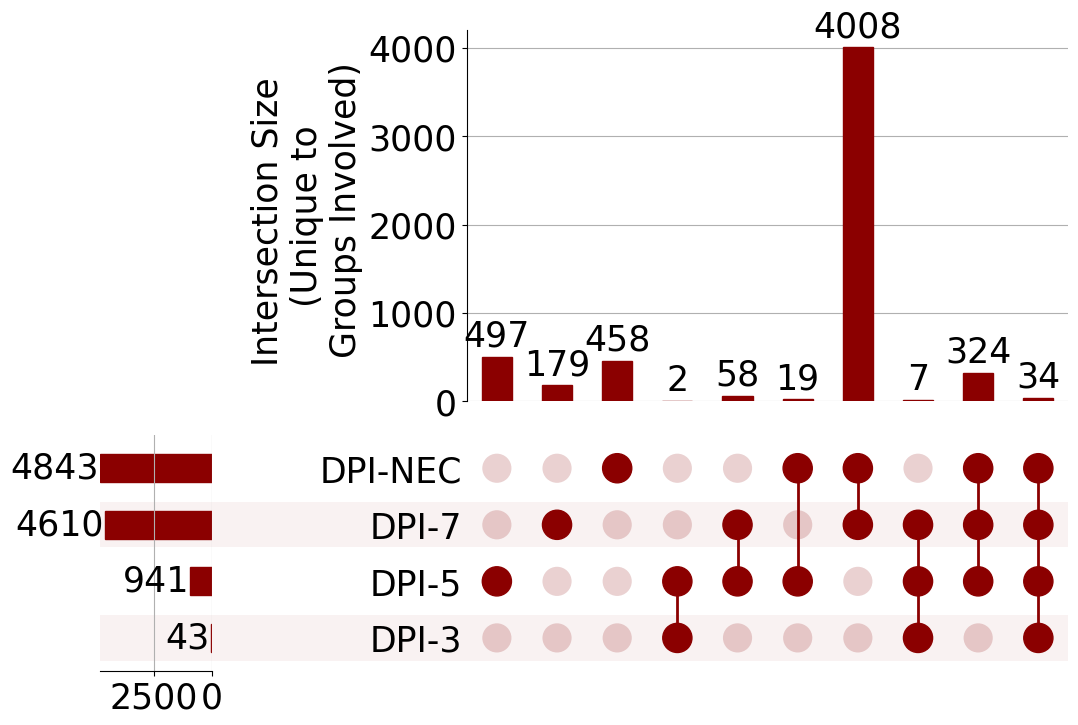

In [27]:
import os
import pandas as pd
from upsetplot import UpSet, from_contents
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import simpledialog

def filter_by_logfc(dataframes, threshold):
    filtered_data = {}
    for key, df in dataframes.items():
        upregulated = df[df['logFC'] > threshold]
        filtered_data[key] = upregulated
    return filtered_data

def ask_for_threshold():
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    threshold = simpledialog.askfloat('Input', 'Cross-MAS Analysis: Please enter the threshold for LogFC for upregulation analysis (i.e., LogFC > m):', parent=root)
    root.destroy()
    return threshold
threshold = ask_for_threshold()
upregulated_results = filter_by_logfc(ranked_dataframes, threshold)
dfs = []
group_names = []
upset_data = {}
for key, df in upregulated_results.items():
    new_key = key.replace('DESeq2_Significant_', '').replace('.csv', '')
    upset_data[new_key] = set(df['Gene Symbol'])
    dfs.append(df)
    group_names.append(new_key)
combined = from_contents(upset_data)
fig = plt.figure(figsize=(10, 4))
plt.rcParams.update({'font.size': 25, 'font.weight': 'normal', 'font.style': 'normal'})
upset = UpSet(combined, subset_size='count', element_size=60, show_counts=True, sort_categories_by=None, facecolor='darkred')
upset_ax = upset.plot(fig=fig)
for ax in fig.axes:
    if ax.get_ylabel() == '':
        for label in ax.get_yticklabels():
            label.set_fontsize(25)
            label.set_fontweight('normal')
plt.setp(plt.gca().get_yticklabels(), fontsize=25, fontweight='normal')
plt.gca().set_ylabel('Intersection Size \n (Unique to \n Groups Involved)', fontsize=25, fontweight='normal')
plt.show()


In [28]:
top_k = 10
top_genes_results = get_top_genes_by_mas_rank(dfs, group_names, top_k)
for combo, top_genes in top_genes_results.items():
    print(f'\nTop 10 genes for combination {combo}:')
    print(top_genes)
Upregulted_Ebola_vs_SarsCov2 = get_top_genes_by_mas_rank(dfs, group_names, 1000)



Top 10 genes for combination DPI-5:
['ABHD6', 'MED17', 'NAGK', 'MVP', 'TRIM26', 'CGAS', 'SRSF11', 'ZC3HAV1', 'SP100', 'IL4R']

Top 10 genes for combination DPI-7:
['PSMD3', 'ALOX12', 'PPCS', 'NDUFS6', 'POLDIP2', 'PTPN23', 'HEXB', 'SEPTIN5', 'CDK11B', 'SSU72']

Top 10 genes for combination DPI-NEC:
['LOC699403', 'DNAH11', 'TENM1', 'RMDN2', 'FBXL13', 'GRIA1', 'UNC13B', 'DGKH', 'HHAT', 'GRAMD2B']

Top 10 genes for combination DPI-3, DPI-5:
['GBP6', 'TNFSF13B']

Top 10 genes for combination DPI-5, DPI-7:
['TIFA', 'CARS1', 'TMEM60', 'SLC39A1', 'PARP11', 'TRIM21', 'GNS', 'GLRX', 'SERPINA1', 'DOK3']

Top 10 genes for combination DPI-5, DPI-NEC:
['RXRG', 'ADCY10', 'NLRC4', 'DTHD1', 'RRBP1', 'DENND5A', 'SNTB1', 'HSPA4L', 'DNAAF11', 'PRKCE']

Top 10 genes for combination DPI-7, DPI-NEC:
['FHOD3', 'GRM7', 'GALNTL6', 'UGT1A1', 'FRMD5', 'CNIH3', 'CHST9', 'KCNH5', 'ICA1', 'OSBPL6']

Top 10 genes for combination DPI-3, DPI-5, DPI-7:
['TRAFD1', 'ZNF267', 'IFI16', 'GBP3', 'GBP7', 'PARP14', 'LACTB']

T

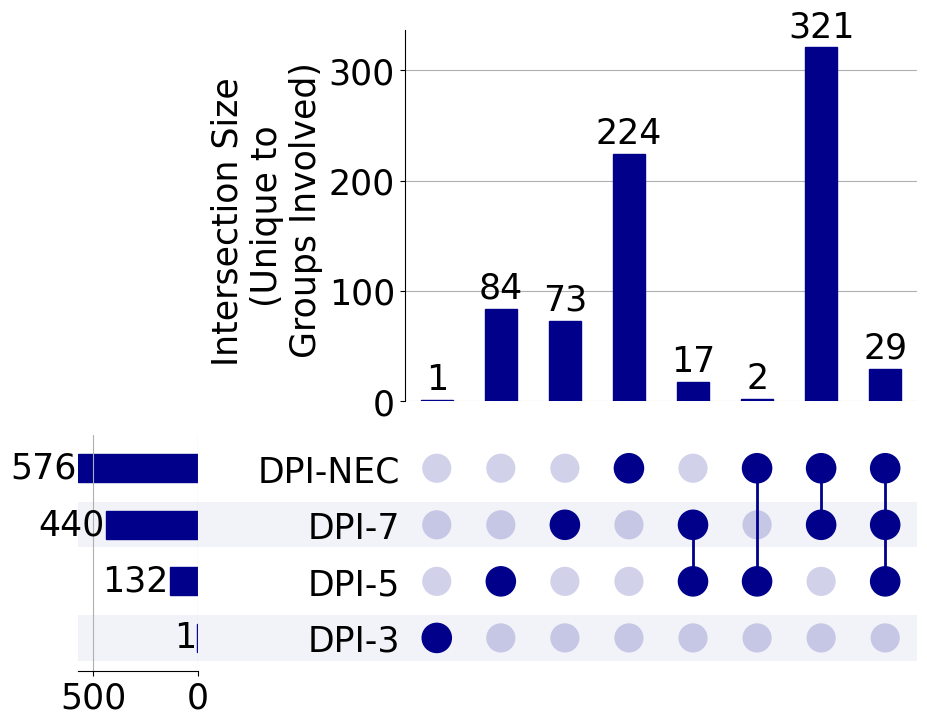

In [29]:
import os
import pandas as pd
from upsetplot import UpSet, from_contents
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import simpledialog

def filter_by_logfc(dataframes, threshold):
    filtered_data = {}
    for key, df in dataframes.items():
        upregulated = df[df['logFC'] < -threshold]
        filtered_data[key] = upregulated
    return filtered_data

def ask_for_threshold():
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    threshold = simpledialog.askfloat('Input', 'Cross-MAS Analysis: Please enter the threshold for LogFC for upregulation analysis (i.e., LogFC > m):', parent=root)
    root.destroy()
    return threshold
threshold = ask_for_threshold()
upregulated_results = filter_by_logfc(ranked_dataframes, threshold)
dfs = []
group_names = []
upset_data = {}
for key, df in upregulated_results.items():
    new_key = key.replace('DESeq2_Significant_', '').replace('.csv', '')
    upset_data[new_key] = set(df['Gene Symbol'])
    dfs.append(df)
    group_names.append(new_key)
combined = from_contents(upset_data)
fig = plt.figure(figsize=(10, 4))
plt.rcParams.update({'font.size': 25, 'font.weight': 'normal', 'font.style': 'normal'})
upset = UpSet(combined, subset_size='count', element_size=60, show_counts=True, sort_categories_by=None, facecolor='darkblue')
upset_ax = upset.plot(fig=fig)
for ax in fig.axes:
    if ax.get_ylabel() == '':
        for label in ax.get_yticklabels():
            label.set_fontsize(25)
            label.set_fontweight('normal')
plt.setp(plt.gca().get_yticklabels(), fontsize=25, fontweight='normal')
plt.gca().set_ylabel('Intersection Size \n (Unique to \n Groups Involved)', fontsize=25, fontweight='normal')
plt.show()


In [30]:
top_genes_results = get_top_genes_by_mas_rank(dfs, group_names, top_k)
for combo, top_genes in top_genes_results.items():
    print(f'\nTop 10 genes for combination {combo}:')
    print(top_genes)
Downregulted_Ebola_vs_MPXV = get_top_genes_by_mas_rank(dfs, group_names, 1000)



Top 10 genes for combination DPI-3:
['TRIM17']

Top 10 genes for combination DPI-5:
['STXBP6', 'LMNA', 'PPFIBP2', 'TPCN1', 'PCMTD2', 'COQ8A', 'CA8', 'IL5RA', 'NCALD', 'IFFO2']

Top 10 genes for combination DPI-7:
['SMAD2', 'SETD3', 'TBL1X', 'MFSD6', 'ABHD12', 'TRMO', 'TLK1', 'KANSL1', 'MME', 'SLC24A1']

Top 10 genes for combination DPI-NEC:
['BPTF', 'FAM13B', 'GDI2', 'ZMYND8', 'EIF4B', 'MAPK1', 'HECA', 'PABPC1', 'JAK1', 'LOC713490']

Top 10 genes for combination DPI-5, DPI-7:
['DAAM1', 'STK39', 'CDC14A', 'TGFBR3', 'KCNQ5', 'PTPN4', 'PDE3B', 'CHN2', 'PACS1', 'SLC16A7']

Top 10 genes for combination DPI-5, DPI-NEC:
['PDCD4', 'GGA2']

Top 10 genes for combination DPI-7, DPI-NEC:
['HBA', 'SLC25A39', 'FAM53B', 'KLF3', 'FKBP8', 'CCM2', 'SESN3', 'GPX1', 'BRWD1', 'TENT5C']

Top 10 genes for combination DPI-5, DPI-7, DPI-NEC:
['ESYT1', 'ITGA4', 'PDE7A', 'CD1C', 'CD40LG', 'AHR', 'MAMU-DMB', 'IL24', 'C2CD2L', 'GRAP']


In [31]:
def analyze_gene_data(Data):
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np
    from matplotlib.ticker import MaxNLocator
    Data.rename(columns={'GeneSymbol': 'Gene Symbol'}, inplace=True)
    title = 'Ranked Genes'
    config = {'method': 'Bonferroni', 'alpha': 0.05, 'logFC_threshold': 1, 'up_or_down_or_both': 'both_up_and_down_regulated', 'highlight_genes': [], 'top_genes': 20, 'upreg_criteria': None, 'downreg_criteria': None, 'upregulated_color': '#FF0000', 'downregulated_color': '#0000FF', 'not_significant_color': '#808080', 'not_significant_between_logFC_threshold_color': '#A0A0A0', 'pie_chart_size': 0.2, 'pie_chart_position': (0.85, 0.85), 'ranking_method': 'MAS', 'Magnitude (M)': 0, 'Altitude (A)': 1, 'g100': (-1, 0.2), 'g010': (1, 0.24), 'g001': (-0.4, -0.5), 'g110': (-0.6, 0.24), 'g101': (-0.8, -0.3), 'g011': (0.7, -0.1), 'g111': (0.4, -0.6)}
    AllGenes, Significant = volcano_plot_no_visualization(Data, M=config['Magnitude (M)'], A=config['Altitude (A)'], title=title, method=config['method'], alpha=config['alpha'], logFC_threshold=config['logFC_threshold'], highlight_genes=config['highlight_genes'], top_genes=config['top_genes'], upreg_criteria=config['upreg_criteria'], downreg_criteria=config['downreg_criteria'], upregulated_color=config['upregulated_color'], downregulated_color=config['downregulated_color'], not_significant_color=config['not_significant_color'], not_significant_between_logFC_threshold_color=config['not_significant_between_logFC_threshold_color'], pie_chart_size=config['pie_chart_size'], pie_chart_position=config['pie_chart_position'], ranking_method=config['ranking_method'], up_or_down_or_both=config['up_or_down_or_both'], g100=config['g100'], g010=config['g010'], g001=config['g001'], g110=config['g110'], g101=config['g101'], g011=config['g011'], g111=config['g111'])
    fig, ax = plt.subplots(1, 1, figsize=(5, 6))
    upregulated_counts = Significant[Significant['Category'] == 'Upregulated'].shape[0]
    downregulated_counts = Significant[Significant['Category'] == 'Downregulated'].shape[0]
    positions = np.arange(1)
    width = 0.6
    ax.bar(positions - width / 2, downregulated_counts, width, label='Downregulated', color='lightblue', edgecolor='black', alpha=0.7, linewidth=1.2)
    ax.bar(positions + width / 2, upregulated_counts, width, label='Upregulated', color='pink', edgecolor='black', alpha=0.7, linewidth=1.2)
    ax.set_title('LogFC < -1 or LogFC > 1', fontsize=18, weight='bold')
    ax.set_xticks(positions)
    ax.set_xticklabels([], fontsize=0)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis='y', labelsize=16)
    top_10_down_genes = {'BH': Significant[Significant['logFC'] < 0].head(10)['Gene Symbol'].tolist()}
    top_10_up_genes = {'BH': Significant[Significant['logFC'] > 0].head(10)['Gene Symbol'].tolist()}
    summary_stats = {'BH': {'Total': Significant.shape[0], 'Upregulated': upregulated_counts, 'Downregulated': downregulated_counts}}
    up_counts = [summary_stats[obj]['Upregulated'] for obj in summary_stats]
    down_counts = [summary_stats[obj]['Downregulated'] for obj in summary_stats]
    annotate_bars_vertical_with_totals(ax, positions, top_10_down_genes, top_10_up_genes, up_counts, down_counts, width)
    up_patch = mpatches.Patch(color='pink', label='Upregulated', edgecolor='black', alpha=0.7)
    down_patch = mpatches.Patch(color='lightblue', label='Downregulated', edgecolor='black', alpha=0.7)
    fig.legend(handles=[down_patch, up_patch], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.01), fontsize=16, frameon=False)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    return (AllGenes, Significant)


Processing file: EdgeR_Significant_DPI-3.csv


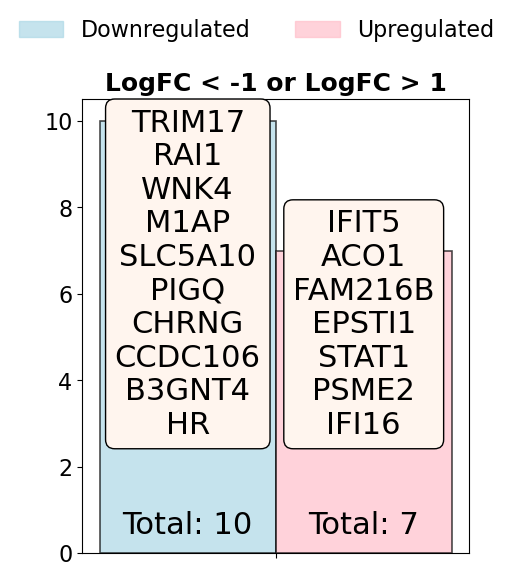

In [32]:
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

def load_and_process_data():
    file_names = ['EdgeR_Significant_DPI-3.csv']
    current_dir = os.getcwd()
    for file_name in file_names:
        file_path = os.path.join(current_dir, file_name)
        if os.path.exists(file_path):
            print(f'Processing file: {file_name}')
            data = pd.read_csv(file_path)
            all_genes, significant_genes = analyze_gene_data(data)
            new_base_name = file_name.replace('DE_', 'Ranked_DE_')
        else:
            print(f'File not found: {file_name}')
load_and_process_data()


Processing file: EdgeR_Significant_DPI-5.csv


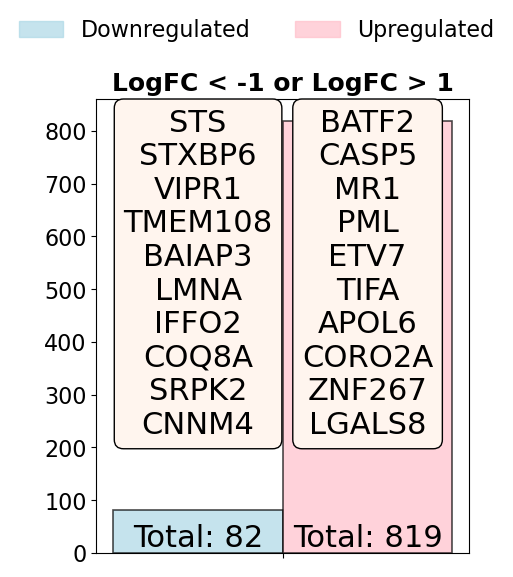

In [33]:
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

def load_and_process_data():
    file_names = ['EdgeR_Significant_DPI-5.csv']
    current_dir = os.getcwd()
    for file_name in file_names:
        file_path = os.path.join(current_dir, file_name)
        if os.path.exists(file_path):
            print(f'Processing file: {file_name}')
            data = pd.read_csv(file_path)
            all_genes, significant_genes = analyze_gene_data(data)
            new_base_name = file_name.replace('DE_', 'Ranked_DE_')
        else:
            print(f'File not found: {file_name}')
load_and_process_data()


Processing file: EdgeR_Significant_DPI-7.csv


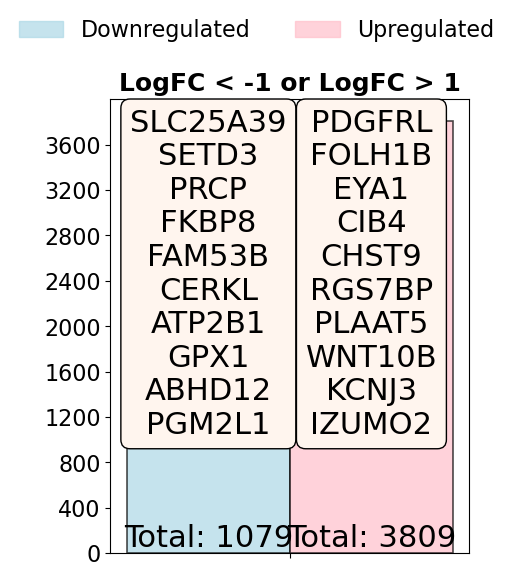

In [34]:
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

def load_and_process_data():
    file_names = ['EdgeR_Significant_DPI-7.csv']
    current_dir = os.getcwd()
    for file_name in file_names:
        file_path = os.path.join(current_dir, file_name)
        if os.path.exists(file_path):
            print(f'Processing file: {file_name}')
            data = pd.read_csv(file_path)
            all_genes, significant_genes = analyze_gene_data(data)
            new_base_name = file_name.replace('DE_', 'Ranked_DE_')
        else:
            print(f'File not found: {file_name}')
load_and_process_data()


Processing file: EdgeR_Significant_DPI-NEC.csv


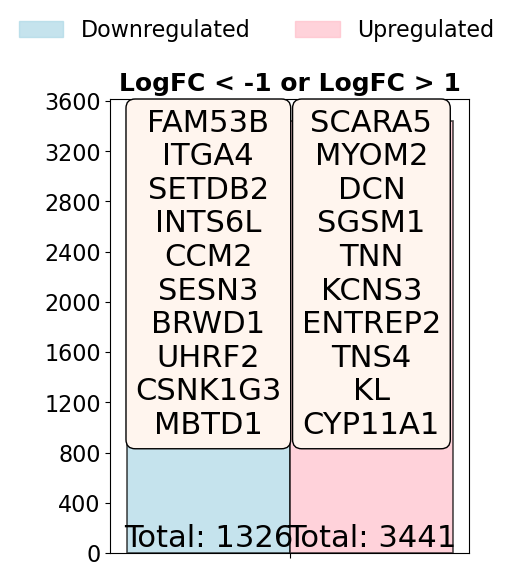

In [35]:
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

def load_and_process_data():
    file_names = ['EdgeR_Significant_DPI-NEC.csv']
    current_dir = os.getcwd()
    for file_name in file_names:
        file_path = os.path.join(current_dir, file_name)
        if os.path.exists(file_path):
            print(f'Processing file: {file_name}')
            data = pd.read_csv(file_path)
            all_genes, significant_genes = analyze_gene_data(data)
            new_base_name = file_name.replace('DE_', 'Ranked_DE_')
        else:
            print(f'File not found: {file_name}')
load_and_process_data()


Processing file: DESeq2_Significant_DPI-3.csv


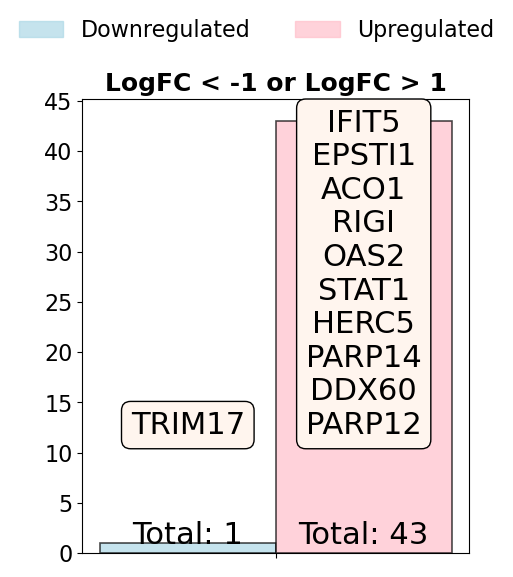

In [36]:
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

def load_and_process_data():
    file_names = ['DESeq2_Significant_DPI-3.csv']
    current_dir = os.getcwd()
    for file_name in file_names:
        file_path = os.path.join(current_dir, file_name)
        if os.path.exists(file_path):
            print(f'Processing file: {file_name}')
            data = pd.read_csv(file_path)
            all_genes, significant_genes = analyze_gene_data(data)
            new_base_name = file_name.replace('DE_', 'Ranked_DE_')
        else:
            print(f'File not found: {file_name}')
load_and_process_data()


Processing file: DESeq2_Significant_DPI-5.csv


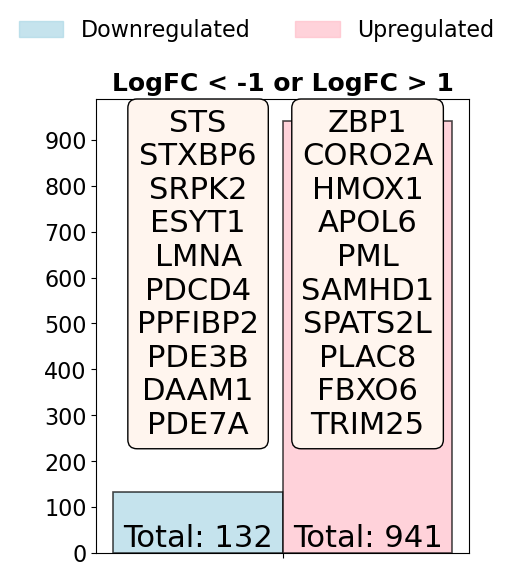

In [37]:
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

def load_and_process_data():
    file_names = ['DESeq2_Significant_DPI-5.csv']
    current_dir = os.getcwd()
    for file_name in file_names:
        file_path = os.path.join(current_dir, file_name)
        if os.path.exists(file_path):
            print(f'Processing file: {file_name}')
            data = pd.read_csv(file_path)
            all_genes, significant_genes = analyze_gene_data(data)
            new_base_name = file_name.replace('DE_', 'Ranked_DE_')
        else:
            print(f'File not found: {file_name}')
load_and_process_data()


Processing file: DESeq2_Significant_DPI-7.csv


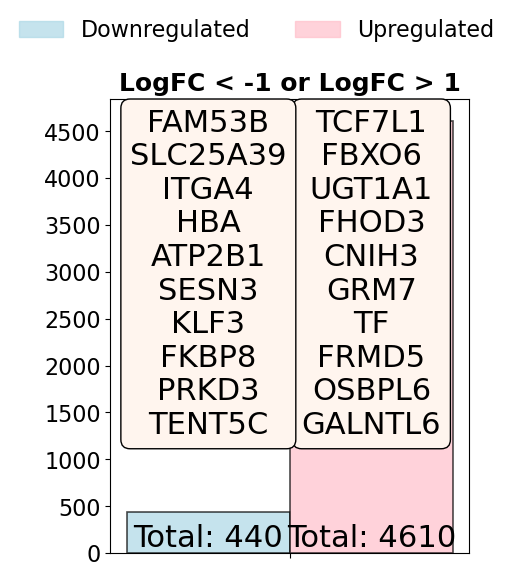

In [38]:
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

def load_and_process_data():
    file_names = ['DESeq2_Significant_DPI-7.csv']
    current_dir = os.getcwd()
    for file_name in file_names:
        file_path = os.path.join(current_dir, file_name)
        if os.path.exists(file_path):
            print(f'Processing file: {file_name}')
            data = pd.read_csv(file_path)
            all_genes, significant_genes = analyze_gene_data(data)
            new_base_name = file_name.replace('DE_', 'Ranked_DE_')
        else:
            print(f'File not found: {file_name}')
load_and_process_data()


Processing file: DESeq2_Significant_DPI-NEC.csv


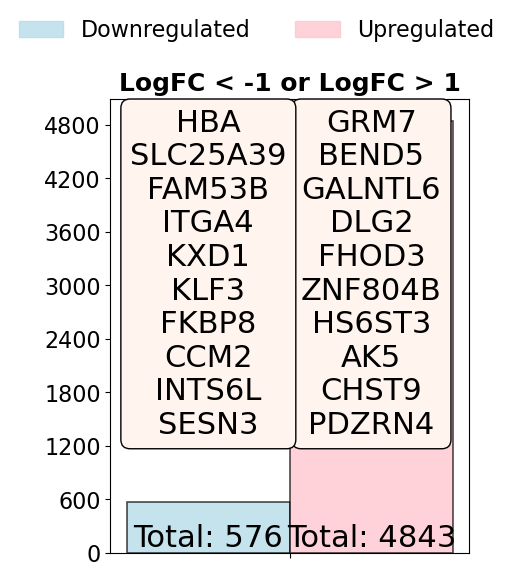

In [39]:
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

def load_and_process_data():
    file_names = ['DESeq2_Significant_DPI-NEC.csv']
    current_dir = os.getcwd()
    for file_name in file_names:
        file_path = os.path.join(current_dir, file_name)
        if os.path.exists(file_path):
            print(f'Processing file: {file_name}')
            data = pd.read_csv(file_path)
            all_genes, significant_genes = analyze_gene_data(data)
            new_base_name = file_name.replace('DE_', 'Ranked_DE_')
        else:
            print(f'File not found: {file_name}')
load_and_process_data()


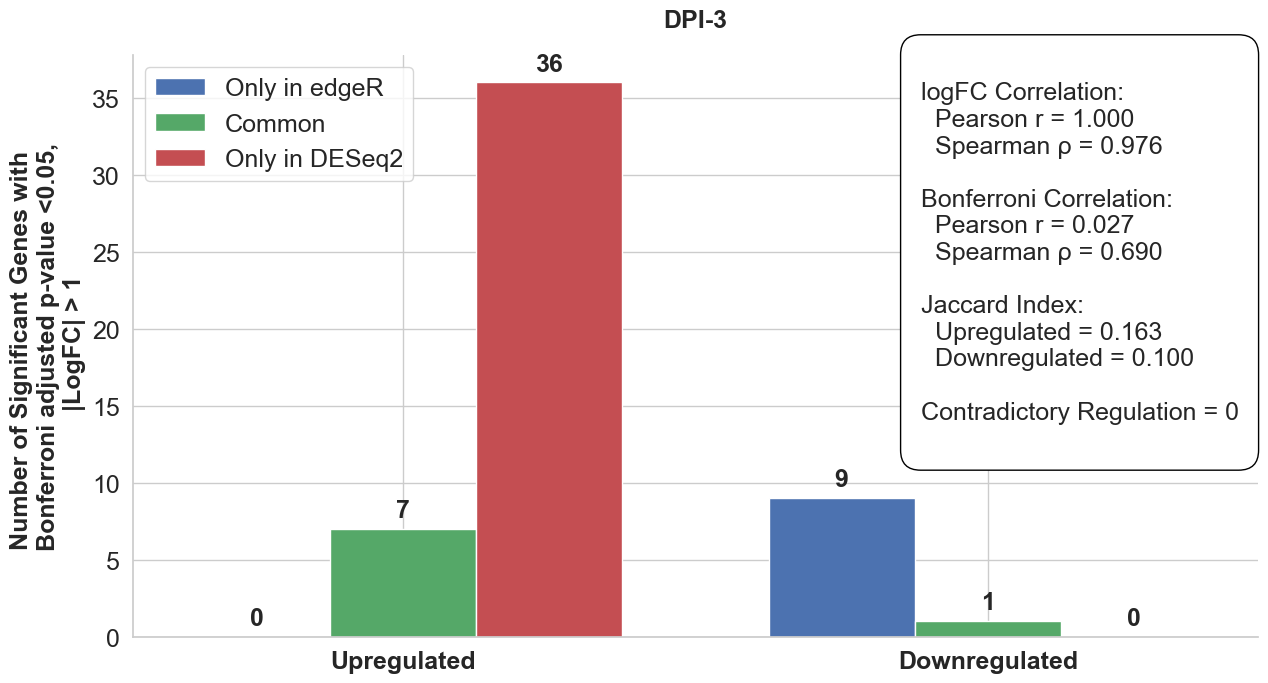

Significant Gene Counts:
  edgeR: 17
  DESeq2: 44
  Common: 8

Upregulated Genes:
  Common: 7
  Only in edgeR: 0
  Only in DESeq2: 36
  Jaccard Index: 0.163

Downregulated Genes:
  Common: 1
  Only in edgeR: 9
  Only in DESeq2: 0
  Jaccard Index: 0.100

Contradictory Regulation (Up in one, Down in other): 0

Correlation of logFC:
  Pearson r = 1.000
  Spearman ρ = 0.976

Correlation of Bonferroni-adjusted p-values:
  Pearson r = 0.027
  Spearman ρ = 0.690
Top 10 common_up: ['ACO1', 'EPSTI1', 'FAM216B', 'IFI16', 'IFIT5', 'PSME2', 'STAT1']
Top 10 common_down: ['TRIM17']
Top 10 edgeR_only_up: []
Top 10 deseq2_only_up: ['APOL6', 'ARMCX1', 'BATF2', 'CASP5', 'CCL8', 'CD274', 'DDX60', 'GBP3', 'GBP6', 'GBP7']
Top 10 edgeR_only_down: ['B3GNT4', 'CCDC106', 'CHRNG', 'HR', 'M1AP', 'PIGQ', 'RAI1', 'SLC5A10', 'WNK4']
Top 10 deseq2_only_down: []


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
edgeR_sig_df = pd.read_csv('EdgeR_Significant_DPI-3.csv').set_index('Gene Symbol')
deseq2_sig_df = pd.read_csv('DESeq2_Significant_DPI-3.csv').set_index('Gene Symbol')
edgeR_up = set(edgeR_sig_df[edgeR_sig_df['Category'] == 'Upregulated'].index)
edgeR_down = set(edgeR_sig_df[edgeR_sig_df['Category'] == 'Downregulated'].index)
deseq2_up = set(deseq2_sig_df[deseq2_sig_df['Category'] == 'Upregulated'].index)
deseq2_down = set(deseq2_sig_df[deseq2_sig_df['Category'] == 'Downregulated'].index)
common_genes = edgeR_sig_df.index.intersection(deseq2_sig_df.index)
df1 = edgeR_sig_df.loc[common_genes]
df2 = deseq2_sig_df.loc[common_genes]
valid_rows = df1['logFC'].notna() & df2['logFC'].notna() & df1['Bonferroni_adjusted_p-value'].notna() & df2['Bonferroni_adjusted_p-value'].notna() & np.isfinite(df1['logFC']) & np.isfinite(df2['logFC']) & np.isfinite(df1['Bonferroni_adjusted_p-value']) & np.isfinite(df2['Bonferroni_adjusted_p-value'])
df1_clean = df1[valid_rows]
df2_clean = df2[valid_rows]
logfc1 = df1_clean['logFC']
logfc2 = df2_clean['logFC']
bonf1 = df1_clean['Bonferroni_adjusted_p-value']
bonf2 = df2_clean['Bonferroni_adjusted_p-value']
pearson_logfc, _ = pearsonr(logfc1, logfc2)
spearman_logfc, _ = spearmanr(logfc1, logfc2)
pearson_bonf, _ = pearsonr(bonf1, bonf2)
spearman_bonf, _ = spearmanr(bonf1, bonf2)
jaccard_up = len(edgeR_up & deseq2_up) / len(edgeR_up | deseq2_up)
jaccard_down = len(edgeR_down & deseq2_down) / len(edgeR_down | deseq2_down)
contradictory = len(edgeR_up & deseq2_down | edgeR_down & deseq2_up)
common_up = edgeR_up & deseq2_up
common_down = edgeR_down & deseq2_down
edgeR_only_up = edgeR_up - deseq2_up
deseq2_only_up = deseq2_up - edgeR_up
edgeR_only_down = edgeR_down - deseq2_down
deseq2_only_down = deseq2_down - edgeR_down
labels = ['Upregulated', 'Downregulated']
x = np.arange(len(labels))
width = 0.25
edgeR_only_counts = [len(edgeR_only_up), len(edgeR_only_down)]
common_counts = [len(common_up), len(common_down)]
deseq2_only_counts = [len(deseq2_only_up), len(deseq2_only_down)]
sns.set(style='whitegrid')
plt.rcParams.update({'font.size': 12})
colors = {'Only in edgeR': '#4C72B0', 'Common': '#55A868', 'Only in DESeq2': '#C44E52'}
fig, ax = plt.subplots(figsize=(13, 7))
bar1 = ax.bar(x - width, edgeR_only_counts, width, label='Only in edgeR', color=colors['Only in edgeR'])
bar2 = ax.bar(x, common_counts, width, label='Common', color=colors['Common'])
bar3 = ax.bar(x + width, deseq2_only_counts, width, label='Only in DESeq2', color=colors['Only in DESeq2'])
ax.set_ylabel('Number of Significant Genes with \n Bonferroni adjusted p-value <0.05, \n |LogFC| > 1', fontsize=18, weight='bold')
ax.set_title('DPI-3', fontsize=18, weight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=18, weight='bold')
ax.tick_params(axis='y', labelsize=18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=True, fontsize=18, loc='upper left', bbox_to_anchor=(0, 1))
for bars in [bar1, bar2, bar3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 5), textcoords='offset points', ha='center', va='bottom', fontsize=18, weight='bold')
textstr = f'\nlogFC Correlation:\n  Pearson r = {pearson_logfc:.3f}\n  Spearman ρ = {spearman_logfc:.3f}\n\nBonferroni Correlation:\n  Pearson r = {pearson_bonf:.3f}\n  Spearman ρ = {spearman_bonf:.3f}\n\nJaccard Index:\n  Upregulated = {jaccard_up:.3f}\n  Downregulated = {jaccard_down:.3f}\n\nContradictory Regulation = {contradictory}\n'
props = dict(boxstyle='round,pad=0.8', facecolor='white', edgecolor='black')
ax.text(0.7, 1, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
plt.tight_layout()
plt.show()
common_up = edgeR_up & deseq2_up
common_down = edgeR_down & deseq2_down
edgeR_only_up = edgeR_up - deseq2_up
deseq2_only_up = deseq2_up - edgeR_up
edgeR_only_down = edgeR_down - deseq2_down
deseq2_only_down = deseq2_down - edgeR_down
print('Significant Gene Counts:')
print(f'  edgeR: {edgeR_sig_df.shape[0]}')
print(f'  DESeq2: {deseq2_sig_df.shape[0]}')
print(f'  Common: {len(common_genes)}')
print('\nUpregulated Genes:')
print(f'  Common: {len(common_up)}')
print(f'  Only in edgeR: {len(edgeR_only_up)}')
print(f'  Only in DESeq2: {len(deseq2_only_up)}')
print(f'  Jaccard Index: {jaccard_up:.3f}')
print('\nDownregulated Genes:')
print(f'  Common: {len(common_down)}')
print(f'  Only in edgeR: {len(edgeR_only_down)}')
print(f'  Only in DESeq2: {len(deseq2_only_down)}')
print(f'  Jaccard Index: {jaccard_down:.3f}')
print(f'\nContradictory Regulation (Up in one, Down in other): {contradictory}')
print('\nCorrelation of logFC:')
print(f'  Pearson r = {pearson_logfc:.3f}')
print(f'  Spearman ρ = {spearman_logfc:.3f}')
print('\nCorrelation of Bonferroni-adjusted p-values:')
print(f'  Pearson r = {pearson_bonf:.3f}')
print(f'  Spearman ρ = {spearman_bonf:.3f}')
common_up = sorted(list(edgeR_up & deseq2_up))
common_down = sorted(list(edgeR_down & deseq2_down))
edgeR_only_up = sorted(list(edgeR_up - deseq2_up))
deseq2_only_up = sorted(list(deseq2_up - edgeR_up))
edgeR_only_down = sorted(list(edgeR_down - deseq2_down))
deseq2_only_down = sorted(list(deseq2_down - edgeR_down))
print('Top 10 common_up:', common_up[:10])
print('Top 10 common_down:', common_down[:10])
print('Top 10 edgeR_only_up:', edgeR_only_up[:10])
print('Top 10 deseq2_only_up:', deseq2_only_up[:10])
print('Top 10 edgeR_only_down:', edgeR_only_down[:10])
print('Top 10 deseq2_only_down:', deseq2_only_down[:10])


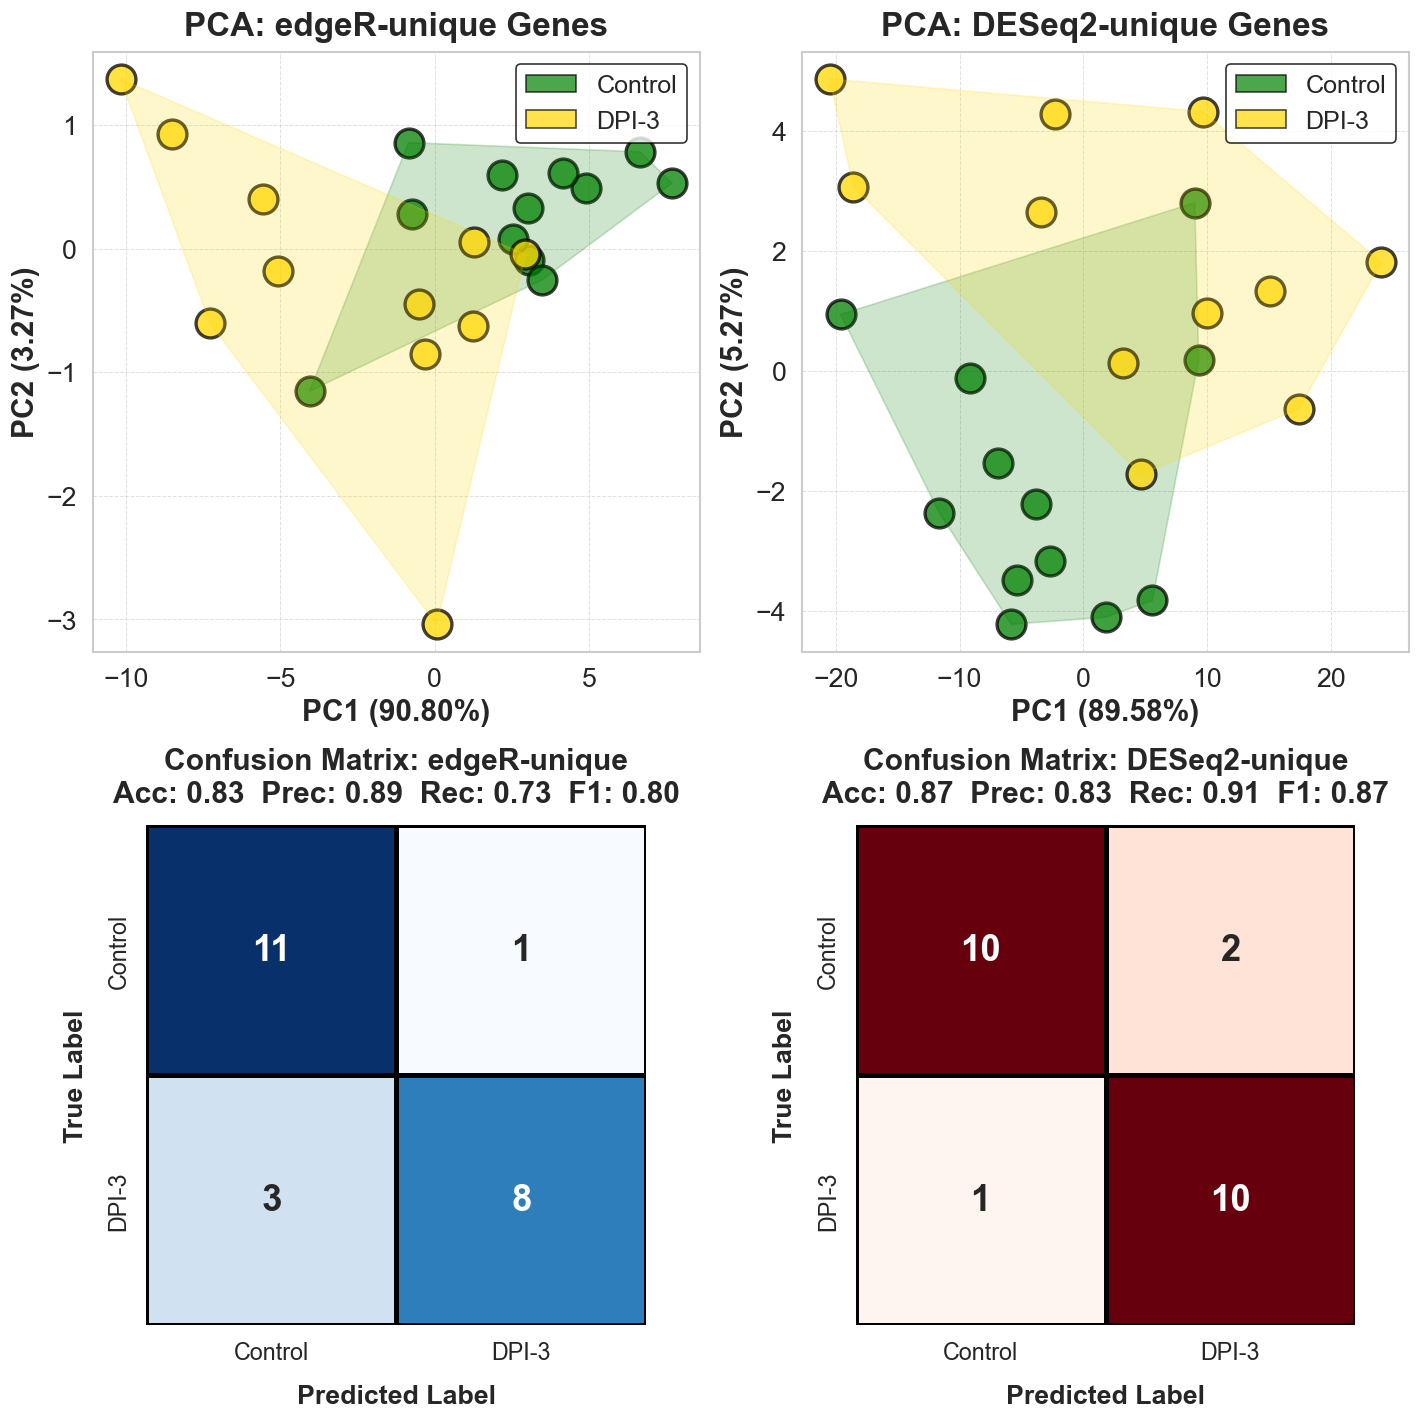

edgeR-unique Metrics
Accuracy:  0.826
Precision: 0.889
Recall:    0.727
F1 Score:  0.800
------------------------------
DESeq2-unique Metrics
Accuracy:  0.870
Precision: 0.833
Recall:    0.909
F1 Score:  0.870


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from matplotlib.patches import Patch
from scipy.spatial import ConvexHull
from matplotlib import gridspec
import seaborn as sns

def prepare_data(gene_list, df):
    data = df.copy()
    filtered_genes = [g for g in gene_list if g in data.index]
    data = data.loc[filtered_genes]
    data_transposed = np.log2(data.transpose() + 1)
    group_names = ['Control' if 'DPI_0' in s else 'DPI-3' for s in data_transposed.index]
    labels = [0 if g == 'Control' else 1 for g in group_names]
    return (data_transposed, labels, group_names)

def plot_pca(ax, data_scaled, group_names, title, color_map):
    pca = PCA(n_components=2)
    components = pca.fit_transform(data_scaled)
    explained = pca.explained_variance_ratio_
    explained_text = [f'{v:.2%}' for v in explained]
    df = pd.DataFrame(components, columns=['PC1', 'PC2'])
    df['Group'] = group_names
    for label in df['Group'].unique():
        points = df[df['Group'] == label][['PC1', 'PC2']].values
        ax.scatter(points[:, 0], points[:, 1], s=300, color=color_map[label], label=label, edgecolor='black', alpha=0.75, linewidth=2)
        if len(points) > 2:
            hull = ConvexHull(points)
            hull_pts = points[hull.vertices]
            ax.fill(hull_pts[:, 0], hull_pts[:, 1], color=color_map[label], alpha=0.2)
    ax.set_title(title, fontsize=20, weight='bold', pad=10)
    ax.set_xlabel(f'PC1 ({explained_text[0]})', fontsize=18, weight='bold')
    ax.set_ylabel(f'PC2 ({explained_text[1]})', fontsize=18, weight='bold')
    ax.tick_params(axis='both', labelsize=16, width=2)
    ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
    handles = [Patch(facecolor=color_map[l], edgecolor='black', label=l, alpha=0.7) for l in df['Group'].unique()]
    ax.legend(handles=handles, fontsize=15, frameon=True, edgecolor='black', loc='upper right')
    return components
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def plot_conf_matrix(ax, cm, title, cmap, class_labels, y_true, y_pred):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, xticklabels=class_labels, yticklabels=class_labels, linewidths=2, linecolor='black', square=True, ax=ax, annot_kws={'size': 22, 'weight': 'bold'})
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    metrics_title = f'{title}\nAcc: {acc:.2f}  Prec: {prec:.2f}  Rec: {rec:.2f}  F1: {f1:.2f}'
    ax.set_title(metrics_title, fontsize=18, fontweight='bold', pad=14)
    ax.set_xlabel('Predicted Label', fontsize=16, fontweight='bold', labelpad=12)
    ax.set_ylabel('True Label', fontsize=16, fontweight='bold', labelpad=12)
    ax.tick_params(axis='both', labelsize=14, width=2)
color_map = {'Control': 'green', 'DPI-3': 'gold'}
data_scaled_er, labels_er, group_names_er = prepare_data(edgeR_only_up + edgeR_only_down, Control_dpi3)
data_scaled_dq, labels_dq, group_names_dq = prepare_data(deseq2_only_up + deseq2_only_down, Control_dpi3)
fig = plt.figure(figsize=(12, 12), dpi=120)
gs = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1])
ax1 = fig.add_subplot(gs[0, 0])
components_er = plot_pca(ax1, data_scaled_er, group_names_er, 'PCA: edgeR-unique Genes', color_map)
ax2 = fig.add_subplot(gs[0, 1])
components_dq = plot_pca(ax2, data_scaled_dq, group_names_dq, 'PCA: DESeq2-unique Genes', color_map)
clf_er = LogisticRegression().fit(components_er, labels_er)
preds_er = clf_er.predict(components_er)
cm_er = confusion_matrix(labels_er, preds_er)
clf_dq = LogisticRegression().fit(components_dq, labels_dq)
preds_dq = clf_dq.predict(components_dq)
cm_dq = confusion_matrix(labels_dq, preds_dq)
ax3 = fig.add_subplot(gs[1, 0])
plot_conf_matrix(ax3, cm_er, 'Confusion Matrix: edgeR-unique', cmap='Blues', class_labels=['Control', 'DPI-3'], y_true=labels_er, y_pred=preds_er)
ax4 = fig.add_subplot(gs[1, 1])
plot_conf_matrix(ax4, cm_dq, 'Confusion Matrix: DESeq2-unique', cmap='Reds', class_labels=['Control', 'DPI-3'], y_true=labels_dq, y_pred=preds_dq)
plt.tight_layout()
plt.show()
acc_er = accuracy_score(labels_er, preds_er)
prec_er = precision_score(labels_er, preds_er)
rec_er = recall_score(labels_er, preds_er)
f1_er = f1_score(labels_er, preds_er)
print('edgeR-unique Metrics')
print(f'Accuracy:  {acc_er:.3f}')
print(f'Precision: {prec_er:.3f}')
print(f'Recall:    {rec_er:.3f}')
print(f'F1 Score:  {f1_er:.3f}')
print('-' * 30)
acc_dq = accuracy_score(labels_dq, preds_dq)
prec_dq = precision_score(labels_dq, preds_dq)
rec_dq = recall_score(labels_dq, preds_dq)
f1_dq = f1_score(labels_dq, preds_dq)
print('DESeq2-unique Metrics')
print(f'Accuracy:  {acc_dq:.3f}')
print(f'Precision: {prec_dq:.3f}')
print(f'Recall:    {rec_dq:.3f}')
print(f'F1 Score:  {f1_dq:.3f}')


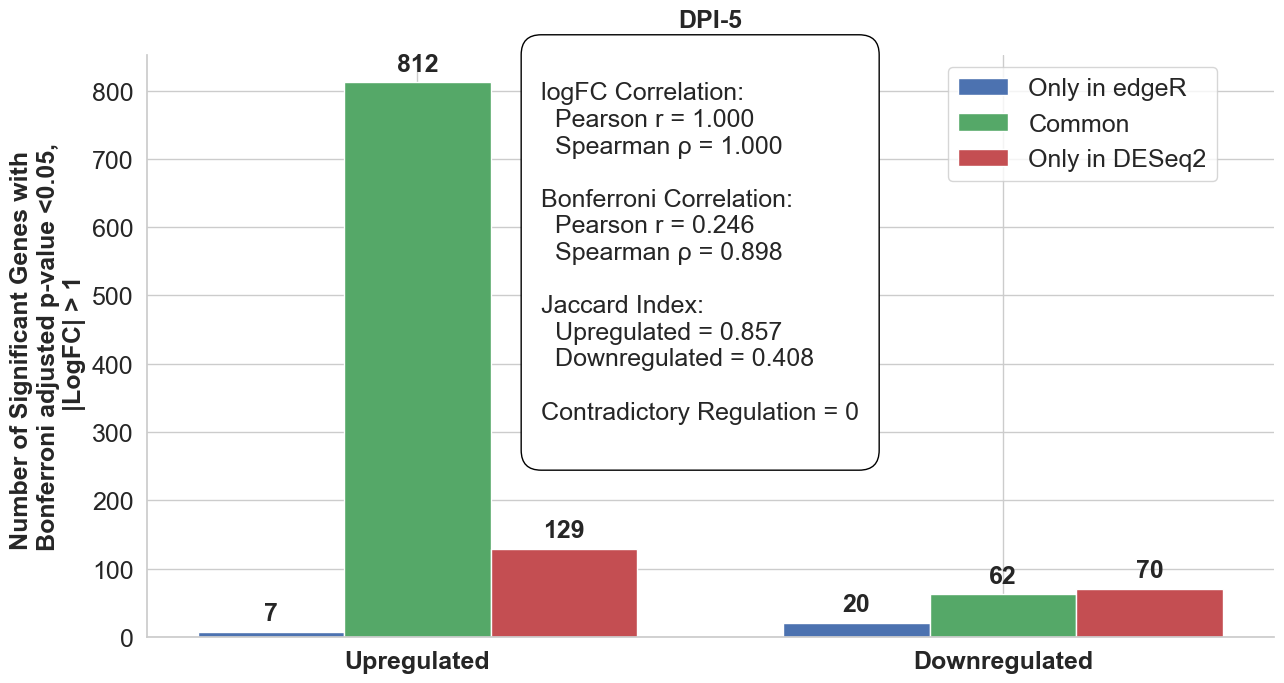

Significant Gene Counts:
  edgeR: 901
  DESeq2: 1073
  Common: 874

Upregulated Genes:
  Common: 812
  Only in edgeR: 7
  Only in DESeq2: 129
  Jaccard Index: 0.857

Downregulated Genes:
  Common: 62
  Only in edgeR: 20
  Only in DESeq2: 70
  Jaccard Index: 0.408

Contradictory Regulation (Up in one, Down in other): 0

Correlation of logFC:
  Pearson r = 1.000
  Spearman ρ = 1.000

Correlation of Bonferroni-adjusted p-values:
  Pearson r = 0.246
  Spearman ρ = 0.898
Top 10 common_up: ['AANAT', 'ABCA13', 'ABHD12B', 'ABHD6', 'ABL2', 'ACO1', 'ACP3', 'ACSL3', 'ACSL4', 'ACTR2']
Top 10 common_down: ['ADGRG5', 'AKT3', 'ANKH', 'BCR', 'C2CD2L', 'CA8', 'CALHM2', 'CCDC88A', 'CCR3', 'CCR6']
Top 10 edgeR_only_up: ['ABCC11', 'ADM', 'CLEC6A', 'PPL', 'SCARF1', 'TMEM217', 'ZNF496']
Top 10 deseq2_only_up: ['ACSS2', 'AFF2', 'ALDH1A1', 'ANXA5', 'ARHGAP27', 'ARHGAP31', 'ARL5B', 'ARPC3', 'ASRGL1', 'AZU1']
Top 10 edgeR_only_down: ['ADK', 'APBA1', 'BAIAP3', 'CD1B', 'CRYL1', 'CXCR3', 'FAM81A', 'GPSM1', 'GZMK',

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
edgeR_sig_df = pd.read_csv('EdgeR_Significant_DPI-5.csv').set_index('Gene Symbol')
deseq2_sig_df = pd.read_csv('DESeq2_Significant_DPI-5.csv').set_index('Gene Symbol')
edgeR_up = set(edgeR_sig_df[edgeR_sig_df['Category'] == 'Upregulated'].index)
edgeR_down = set(edgeR_sig_df[edgeR_sig_df['Category'] == 'Downregulated'].index)
deseq2_up = set(deseq2_sig_df[deseq2_sig_df['Category'] == 'Upregulated'].index)
deseq2_down = set(deseq2_sig_df[deseq2_sig_df['Category'] == 'Downregulated'].index)
common_genes = edgeR_sig_df.index.intersection(deseq2_sig_df.index)
df1 = edgeR_sig_df.loc[common_genes]
df2 = deseq2_sig_df.loc[common_genes]
valid_rows = df1['logFC'].notna() & df2['logFC'].notna() & df1['Bonferroni_adjusted_p-value'].notna() & df2['Bonferroni_adjusted_p-value'].notna() & np.isfinite(df1['logFC']) & np.isfinite(df2['logFC']) & np.isfinite(df1['Bonferroni_adjusted_p-value']) & np.isfinite(df2['Bonferroni_adjusted_p-value'])
df1_clean = df1[valid_rows]
df2_clean = df2[valid_rows]
logfc1 = df1_clean['logFC']
logfc2 = df2_clean['logFC']
bonf1 = df1_clean['Bonferroni_adjusted_p-value']
bonf2 = df2_clean['Bonferroni_adjusted_p-value']
pearson_logfc, _ = pearsonr(logfc1, logfc2)
spearman_logfc, _ = spearmanr(logfc1, logfc2)
pearson_bonf, _ = pearsonr(bonf1, bonf2)
spearman_bonf, _ = spearmanr(bonf1, bonf2)
jaccard_up = len(edgeR_up & deseq2_up) / len(edgeR_up | deseq2_up)
jaccard_down = len(edgeR_down & deseq2_down) / len(edgeR_down | deseq2_down)
contradictory = len(edgeR_up & deseq2_down | edgeR_down & deseq2_up)
common_up = edgeR_up & deseq2_up
common_down = edgeR_down & deseq2_down
edgeR_only_up = edgeR_up - deseq2_up
deseq2_only_up = deseq2_up - edgeR_up
edgeR_only_down = edgeR_down - deseq2_down
deseq2_only_down = deseq2_down - edgeR_down
labels = ['Upregulated', 'Downregulated']
x = np.arange(len(labels))
width = 0.25
edgeR_only_counts = [len(edgeR_only_up), len(edgeR_only_down)]
common_counts = [len(common_up), len(common_down)]
deseq2_only_counts = [len(deseq2_only_up), len(deseq2_only_down)]
sns.set(style='whitegrid')
plt.rcParams.update({'font.size': 12})
colors = {'Only in edgeR': '#4C72B0', 'Common': '#55A868', 'Only in DESeq2': '#C44E52'}
fig, ax = plt.subplots(figsize=(13, 7))
bar1 = ax.bar(x - width, edgeR_only_counts, width, label='Only in edgeR', color=colors['Only in edgeR'])
bar2 = ax.bar(x, common_counts, width, label='Common', color=colors['Common'])
bar3 = ax.bar(x + width, deseq2_only_counts, width, label='Only in DESeq2', color=colors['Only in DESeq2'])
ax.set_ylabel('Number of Significant Genes with \n Bonferroni adjusted p-value <0.05, \n |LogFC| > 1', fontsize=18, weight='bold')
ax.set_title('DPI-5', fontsize=18, weight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=18, weight='bold')
ax.tick_params(axis='y', labelsize=18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=True, fontsize=18, loc='upper left', bbox_to_anchor=(0.7, 1))
for bars in [bar1, bar2, bar3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 5), textcoords='offset points', ha='center', va='bottom', fontsize=18, weight='bold')
textstr = f'\nlogFC Correlation:\n  Pearson r = {pearson_logfc:.3f}\n  Spearman ρ = {spearman_logfc:.3f}\n\nBonferroni Correlation:\n  Pearson r = {pearson_bonf:.3f}\n  Spearman ρ = {spearman_bonf:.3f}\n\nJaccard Index:\n  Upregulated = {jaccard_up:.3f}\n  Downregulated = {jaccard_down:.3f}\n\nContradictory Regulation = {contradictory}\n'
props = dict(boxstyle='round,pad=0.8', facecolor='white', edgecolor='black')
ax.text(0.35, 1, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
plt.tight_layout()
plt.show()
common_up = edgeR_up & deseq2_up
common_down = edgeR_down & deseq2_down
edgeR_only_up = edgeR_up - deseq2_up
deseq2_only_up = deseq2_up - edgeR_up
edgeR_only_down = edgeR_down - deseq2_down
deseq2_only_down = deseq2_down - edgeR_down
print('Significant Gene Counts:')
print(f'  edgeR: {edgeR_sig_df.shape[0]}')
print(f'  DESeq2: {deseq2_sig_df.shape[0]}')
print(f'  Common: {len(common_genes)}')
print('\nUpregulated Genes:')
print(f'  Common: {len(common_up)}')
print(f'  Only in edgeR: {len(edgeR_only_up)}')
print(f'  Only in DESeq2: {len(deseq2_only_up)}')
print(f'  Jaccard Index: {jaccard_up:.3f}')
print('\nDownregulated Genes:')
print(f'  Common: {len(common_down)}')
print(f'  Only in edgeR: {len(edgeR_only_down)}')
print(f'  Only in DESeq2: {len(deseq2_only_down)}')
print(f'  Jaccard Index: {jaccard_down:.3f}')
print(f'\nContradictory Regulation (Up in one, Down in other): {contradictory}')
print('\nCorrelation of logFC:')
print(f'  Pearson r = {pearson_logfc:.3f}')
print(f'  Spearman ρ = {spearman_logfc:.3f}')
print('\nCorrelation of Bonferroni-adjusted p-values:')
print(f'  Pearson r = {pearson_bonf:.3f}')
print(f'  Spearman ρ = {spearman_bonf:.3f}')
common_up = sorted(list(edgeR_up & deseq2_up))
common_down = sorted(list(edgeR_down & deseq2_down))
edgeR_only_up = sorted(list(edgeR_up - deseq2_up))
deseq2_only_up = sorted(list(deseq2_up - edgeR_up))
edgeR_only_down = sorted(list(edgeR_down - deseq2_down))
deseq2_only_down = sorted(list(deseq2_down - edgeR_down))
print('Top 10 common_up:', common_up[:10])
print('Top 10 common_down:', common_down[:10])
print('Top 10 edgeR_only_up:', edgeR_only_up[:10])
print('Top 10 deseq2_only_up:', deseq2_only_up[:10])
print('Top 10 edgeR_only_down:', edgeR_only_down[:10])
print('Top 10 deseq2_only_down:', deseq2_only_down[:10])


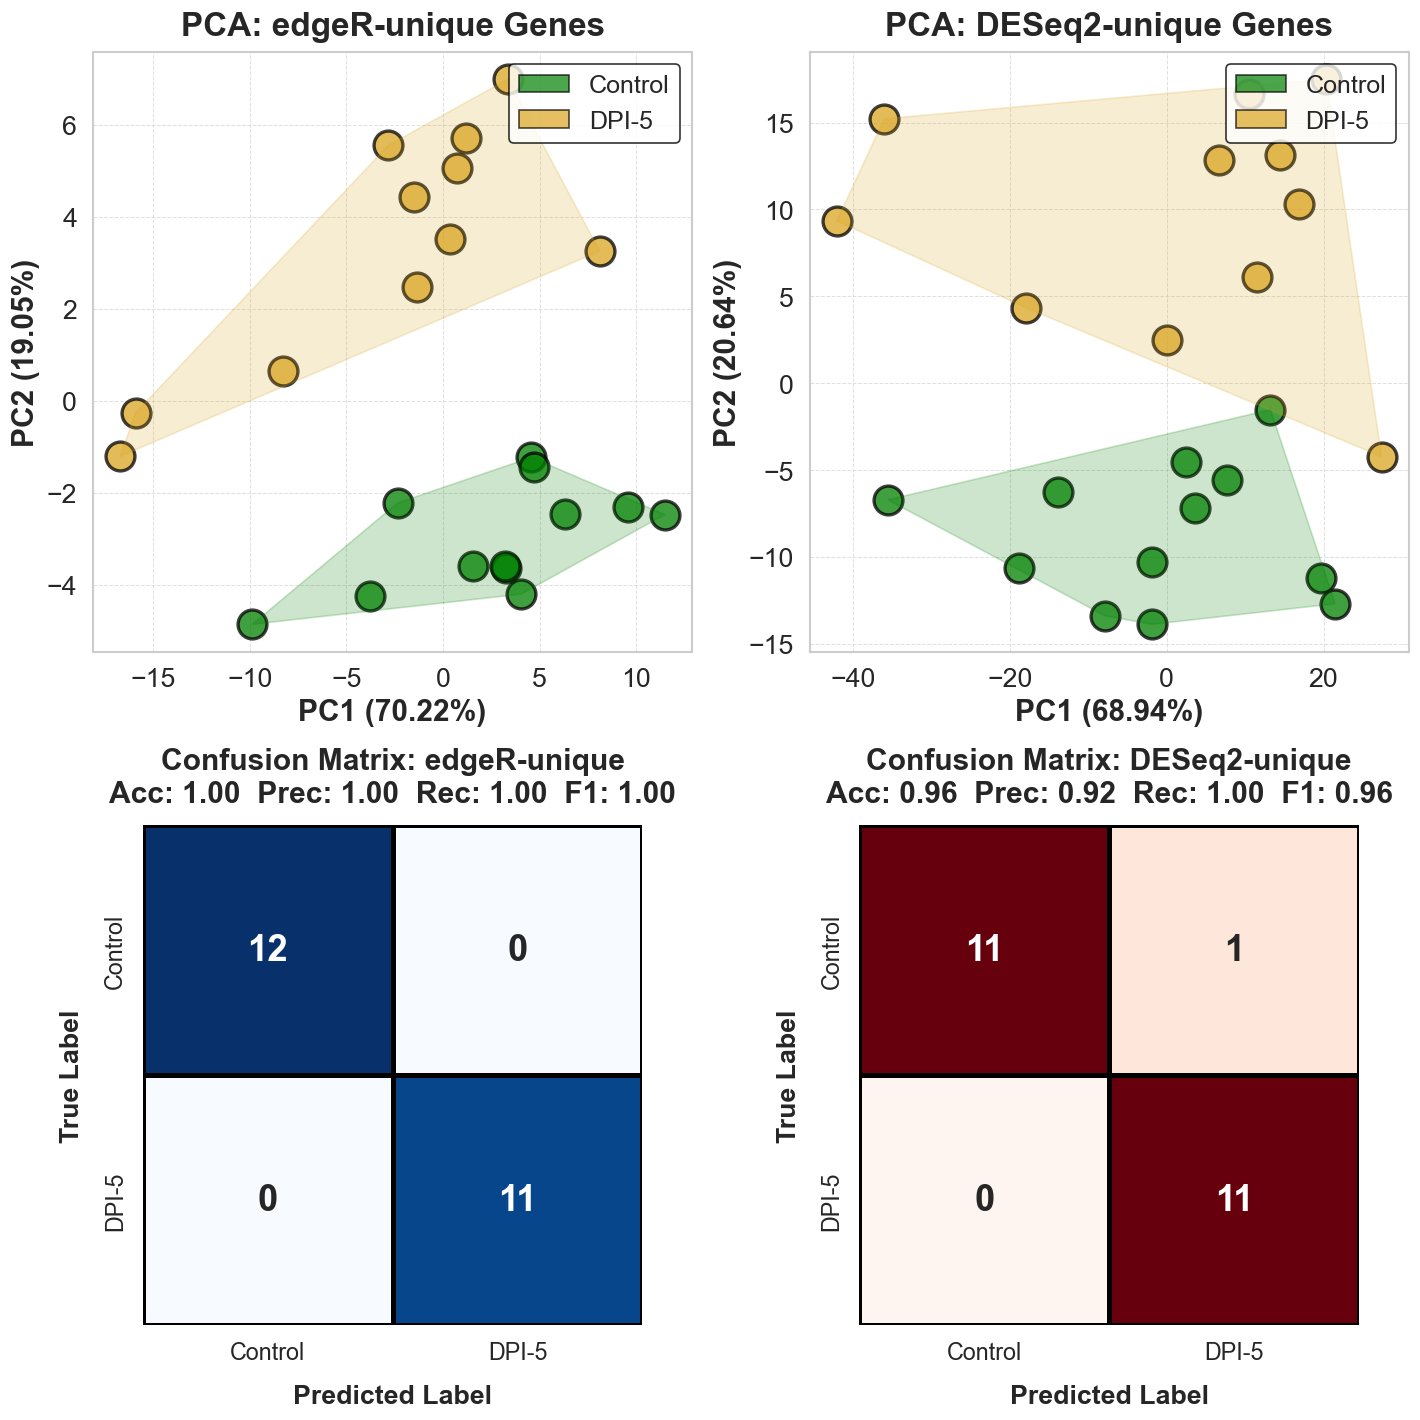

edgeR-unique Metrics
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1 Score:  1.000
------------------------------
DESeq2-unique Metrics
Accuracy:  0.957
Precision: 0.917
Recall:    1.000
F1 Score:  0.957


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from matplotlib.patches import Patch
from scipy.spatial import ConvexHull
from matplotlib import gridspec
import seaborn as sns

def prepare_data(gene_list, df):
    data = df.copy()
    filtered_genes = [g for g in gene_list if g in data.index]
    data = data.loc[filtered_genes]
    data_transposed = np.log2(data.transpose() + 1)
    group_names = ['Control' if 'DPI_0' in s else 'DPI-5' for s in data_transposed.index]
    labels = [0 if g == 'Control' else 1 for g in group_names]
    return (data_transposed, labels, group_names)

def plot_pca(ax, data_scaled, group_names, title, color_map):
    pca = PCA(n_components=2)
    components = pca.fit_transform(data_scaled)
    explained = pca.explained_variance_ratio_
    explained_text = [f'{v:.2%}' for v in explained]
    df = pd.DataFrame(components, columns=['PC1', 'PC2'])
    df['Group'] = group_names
    for label in df['Group'].unique():
        points = df[df['Group'] == label][['PC1', 'PC2']].values
        ax.scatter(points[:, 0], points[:, 1], s=300, color=color_map[label], label=label, edgecolor='black', alpha=0.75, linewidth=2)
        if len(points) > 2:
            hull = ConvexHull(points)
            hull_pts = points[hull.vertices]
            ax.fill(hull_pts[:, 0], hull_pts[:, 1], color=color_map[label], alpha=0.2)
    ax.set_title(title, fontsize=20, weight='bold', pad=10)
    ax.set_xlabel(f'PC1 ({explained_text[0]})', fontsize=18, weight='bold')
    ax.set_ylabel(f'PC2 ({explained_text[1]})', fontsize=18, weight='bold')
    ax.tick_params(axis='both', labelsize=16, width=2)
    ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
    handles = [Patch(facecolor=color_map[l], edgecolor='black', label=l, alpha=0.7) for l in df['Group'].unique()]
    ax.legend(handles=handles, fontsize=15, frameon=True, edgecolor='black', loc='upper right')
    return components
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def plot_conf_matrix(ax, cm, title, cmap, class_labels, y_true, y_pred):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, xticklabels=class_labels, yticklabels=class_labels, linewidths=2, linecolor='black', square=True, ax=ax, annot_kws={'size': 22, 'weight': 'bold'})
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    metrics_title = f'{title}\nAcc: {acc:.2f}  Prec: {prec:.2f}  Rec: {rec:.2f}  F1: {f1:.2f}'
    ax.set_title(metrics_title, fontsize=18, fontweight='bold', pad=14)
    ax.set_xlabel('Predicted Label', fontsize=16, fontweight='bold', labelpad=12)
    ax.set_ylabel('True Label', fontsize=16, fontweight='bold', labelpad=12)
    ax.tick_params(axis='both', labelsize=14, width=2)
color_map = {'Control': 'green', 'DPI-5': 'goldenrod'}
data_scaled_er, labels_er, group_names_er = prepare_data(edgeR_only_up + edgeR_only_down, Control_dpi5)
data_scaled_dq, labels_dq, group_names_dq = prepare_data(deseq2_only_up + deseq2_only_down, Control_dpi5)
fig = plt.figure(figsize=(12, 12), dpi=120)
gs = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1])
ax1 = fig.add_subplot(gs[0, 0])
components_er = plot_pca(ax1, data_scaled_er, group_names_er, 'PCA: edgeR-unique Genes', color_map)
ax2 = fig.add_subplot(gs[0, 1])
components_dq = plot_pca(ax2, data_scaled_dq, group_names_dq, 'PCA: DESeq2-unique Genes', color_map)
clf_er = LogisticRegression().fit(components_er, labels_er)
preds_er = clf_er.predict(components_er)
cm_er = confusion_matrix(labels_er, preds_er)
clf_dq = LogisticRegression().fit(components_dq, labels_dq)
preds_dq = clf_dq.predict(components_dq)
cm_dq = confusion_matrix(labels_dq, preds_dq)
ax3 = fig.add_subplot(gs[1, 0])
plot_conf_matrix(ax3, cm_er, 'Confusion Matrix: edgeR-unique', cmap='Blues', class_labels=['Control', 'DPI-5'], y_true=labels_er, y_pred=preds_er)
ax4 = fig.add_subplot(gs[1, 1])
plot_conf_matrix(ax4, cm_dq, 'Confusion Matrix: DESeq2-unique', cmap='Reds', class_labels=['Control', 'DPI-5'], y_true=labels_dq, y_pred=preds_dq)
plt.tight_layout()
plt.show()
acc_er = accuracy_score(labels_er, preds_er)
prec_er = precision_score(labels_er, preds_er)
rec_er = recall_score(labels_er, preds_er)
f1_er = f1_score(labels_er, preds_er)
print('edgeR-unique Metrics')
print(f'Accuracy:  {acc_er:.3f}')
print(f'Precision: {prec_er:.3f}')
print(f'Recall:    {rec_er:.3f}')
print(f'F1 Score:  {f1_er:.3f}')
print('-' * 30)
acc_dq = accuracy_score(labels_dq, preds_dq)
prec_dq = precision_score(labels_dq, preds_dq)
rec_dq = recall_score(labels_dq, preds_dq)
f1_dq = f1_score(labels_dq, preds_dq)
print('DESeq2-unique Metrics')
print(f'Accuracy:  {acc_dq:.3f}')
print(f'Precision: {prec_dq:.3f}')
print(f'Recall:    {rec_dq:.3f}')
print(f'F1 Score:  {f1_dq:.3f}')


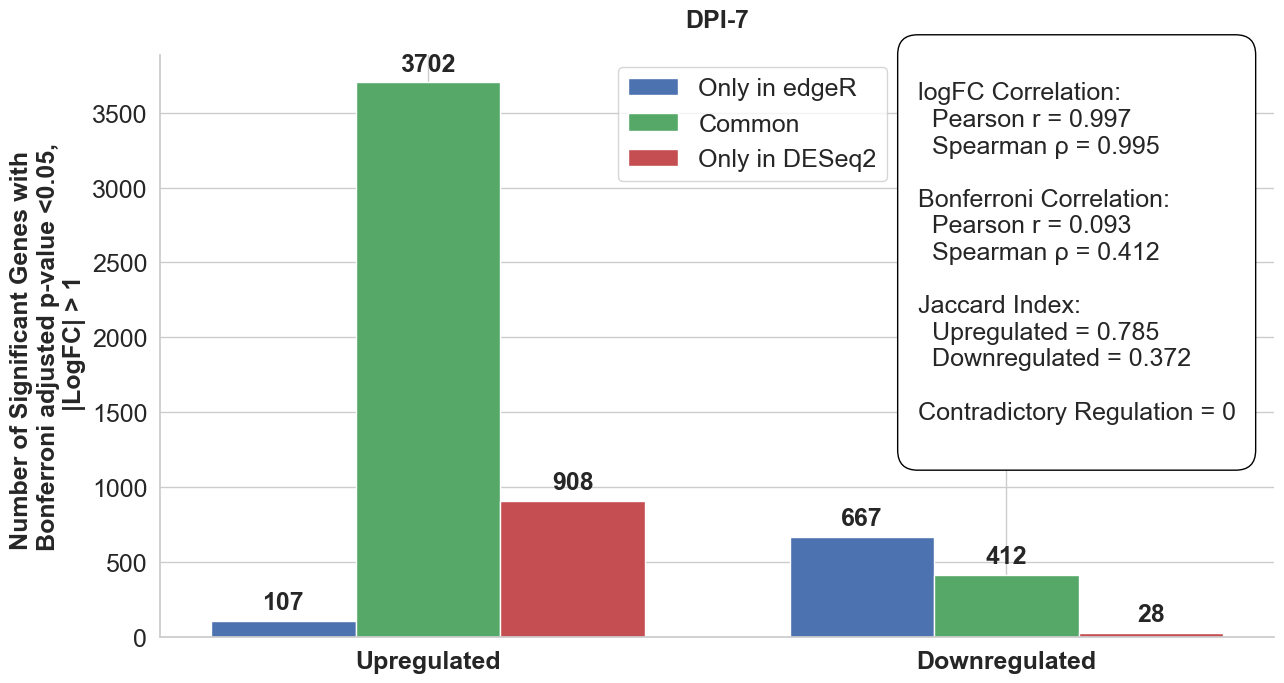

Significant Gene Counts:
  edgeR: 4888
  DESeq2: 5050
  Common: 4114

Upregulated Genes:
  Common: 3702
  Only in edgeR: 107
  Only in DESeq2: 908
  Jaccard Index: 0.785

Downregulated Genes:
  Common: 412
  Only in edgeR: 667
  Only in DESeq2: 28
  Jaccard Index: 0.372

Contradictory Regulation (Up in one, Down in other): 0

Correlation of logFC:
  Pearson r = 0.997
  Spearman ρ = 0.995

Correlation of Bonferroni-adjusted p-values:
  Pearson r = 0.093
  Spearman ρ = 0.412
Top 10 common_up: ['A2ML1', 'A3GALT2', 'AADAC', 'AADACL2', 'AADACL4', 'AADAT', 'AANAT', 'AARD', 'ABCA12', 'ABCA13']
Top 10 common_down: ['ABCC13', 'ABHD12', 'ABHD5', 'ABRA', 'ACP1', 'ACP5', 'ACTA2', 'ADAM19', 'ADIPOR1', 'AFF3']
Top 10 edgeR_only_up: ['A1BG', 'ABCG4', 'ACCSL', 'ACTL8', 'ACTL9', 'ADH6', 'AGR2', 'AMBN', 'AP1M2', 'ASXL3']
Top 10 deseq2_only_up: ['AATK', 'ABCA4', 'ABHD11', 'ABHD15', 'ABHD17A', 'ABI2', 'ABL2', 'ACAP3', 'ACBD4', 'ACD']
Top 10 edgeR_only_down: ['ABCB10', 'ABCE1', 'ABCG2', 'ABI3', 'ACADM', 'A

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
edgeR_sig_df = pd.read_csv('EdgeR_Significant_DPI-7.csv').set_index('Gene Symbol')
deseq2_sig_df = pd.read_csv('DESeq2_Significant_DPI-7.csv').set_index('Gene Symbol')
edgeR_up = set(edgeR_sig_df[edgeR_sig_df['Category'] == 'Upregulated'].index)
edgeR_down = set(edgeR_sig_df[edgeR_sig_df['Category'] == 'Downregulated'].index)
deseq2_up = set(deseq2_sig_df[deseq2_sig_df['Category'] == 'Upregulated'].index)
deseq2_down = set(deseq2_sig_df[deseq2_sig_df['Category'] == 'Downregulated'].index)
common_genes = edgeR_sig_df.index.intersection(deseq2_sig_df.index)
df1 = edgeR_sig_df.loc[common_genes]
df2 = deseq2_sig_df.loc[common_genes]
valid_rows = df1['logFC'].notna() & df2['logFC'].notna() & df1['Bonferroni_adjusted_p-value'].notna() & df2['Bonferroni_adjusted_p-value'].notna() & np.isfinite(df1['logFC']) & np.isfinite(df2['logFC']) & np.isfinite(df1['Bonferroni_adjusted_p-value']) & np.isfinite(df2['Bonferroni_adjusted_p-value'])
df1_clean = df1[valid_rows]
df2_clean = df2[valid_rows]
logfc1 = df1_clean['logFC']
logfc2 = df2_clean['logFC']
bonf1 = df1_clean['Bonferroni_adjusted_p-value']
bonf2 = df2_clean['Bonferroni_adjusted_p-value']
pearson_logfc, _ = pearsonr(logfc1, logfc2)
spearman_logfc, _ = spearmanr(logfc1, logfc2)
pearson_bonf, _ = pearsonr(bonf1, bonf2)
spearman_bonf, _ = spearmanr(bonf1, bonf2)
jaccard_up = len(edgeR_up & deseq2_up) / len(edgeR_up | deseq2_up)
jaccard_down = len(edgeR_down & deseq2_down) / len(edgeR_down | deseq2_down)
contradictory = len(edgeR_up & deseq2_down | edgeR_down & deseq2_up)
common_up = edgeR_up & deseq2_up
common_down = edgeR_down & deseq2_down
edgeR_only_up = edgeR_up - deseq2_up
deseq2_only_up = deseq2_up - edgeR_up
edgeR_only_down = edgeR_down - deseq2_down
deseq2_only_down = deseq2_down - edgeR_down
labels = ['Upregulated', 'Downregulated']
x = np.arange(len(labels))
width = 0.25
edgeR_only_counts = [len(edgeR_only_up), len(edgeR_only_down)]
common_counts = [len(common_up), len(common_down)]
deseq2_only_counts = [len(deseq2_only_up), len(deseq2_only_down)]
sns.set(style='whitegrid')
plt.rcParams.update({'font.size': 12})
colors = {'Only in edgeR': '#4C72B0', 'Common': '#55A868', 'Only in DESeq2': '#C44E52'}
fig, ax = plt.subplots(figsize=(13, 7))
bar1 = ax.bar(x - width, edgeR_only_counts, width, label='Only in edgeR', color=colors['Only in edgeR'])
bar2 = ax.bar(x, common_counts, width, label='Common', color=colors['Common'])
bar3 = ax.bar(x + width, deseq2_only_counts, width, label='Only in DESeq2', color=colors['Only in DESeq2'])
ax.set_ylabel('Number of Significant Genes with \n Bonferroni adjusted p-value <0.05, \n |LogFC| > 1', fontsize=18, weight='bold')
ax.set_title('DPI-7', fontsize=18, weight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=18, weight='bold')
ax.tick_params(axis='y', labelsize=18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=True, fontsize=18, loc='upper left', bbox_to_anchor=(0.4, 1))
for bars in [bar1, bar2, bar3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 5), textcoords='offset points', ha='center', va='bottom', fontsize=18, weight='bold')
textstr = f'\nlogFC Correlation:\n  Pearson r = {pearson_logfc:.3f}\n  Spearman ρ = {spearman_logfc:.3f}\n\nBonferroni Correlation:\n  Pearson r = {pearson_bonf:.3f}\n  Spearman ρ = {spearman_bonf:.3f}\n\nJaccard Index:\n  Upregulated = {jaccard_up:.3f}\n  Downregulated = {jaccard_down:.3f}\n\nContradictory Regulation = {contradictory}\n'
props = dict(boxstyle='round,pad=0.8', facecolor='white', edgecolor='black')
ax.text(0.68, 1, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
plt.tight_layout()
plt.show()
common_up = edgeR_up & deseq2_up
common_down = edgeR_down & deseq2_down
edgeR_only_up = edgeR_up - deseq2_up
deseq2_only_up = deseq2_up - edgeR_up
edgeR_only_down = edgeR_down - deseq2_down
deseq2_only_down = deseq2_down - edgeR_down
print('Significant Gene Counts:')
print(f'  edgeR: {edgeR_sig_df.shape[0]}')
print(f'  DESeq2: {deseq2_sig_df.shape[0]}')
print(f'  Common: {len(common_genes)}')
print('\nUpregulated Genes:')
print(f'  Common: {len(common_up)}')
print(f'  Only in edgeR: {len(edgeR_only_up)}')
print(f'  Only in DESeq2: {len(deseq2_only_up)}')
print(f'  Jaccard Index: {jaccard_up:.3f}')
print('\nDownregulated Genes:')
print(f'  Common: {len(common_down)}')
print(f'  Only in edgeR: {len(edgeR_only_down)}')
print(f'  Only in DESeq2: {len(deseq2_only_down)}')
print(f'  Jaccard Index: {jaccard_down:.3f}')
print(f'\nContradictory Regulation (Up in one, Down in other): {contradictory}')
print('\nCorrelation of logFC:')
print(f'  Pearson r = {pearson_logfc:.3f}')
print(f'  Spearman ρ = {spearman_logfc:.3f}')
print('\nCorrelation of Bonferroni-adjusted p-values:')
print(f'  Pearson r = {pearson_bonf:.3f}')
print(f'  Spearman ρ = {spearman_bonf:.3f}')
common_up = sorted(list(edgeR_up & deseq2_up))
common_down = sorted(list(edgeR_down & deseq2_down))
edgeR_only_up = sorted(list(edgeR_up - deseq2_up))
deseq2_only_up = sorted(list(deseq2_up - edgeR_up))
edgeR_only_down = sorted(list(edgeR_down - deseq2_down))
deseq2_only_down = sorted(list(deseq2_down - edgeR_down))
print('Top 10 common_up:', common_up[:10])
print('Top 10 common_down:', common_down[:10])
print('Top 10 edgeR_only_up:', edgeR_only_up[:10])
print('Top 10 deseq2_only_up:', deseq2_only_up[:10])
print('Top 10 edgeR_only_down:', edgeR_only_down[:10])
print('Top 10 deseq2_only_down:', deseq2_only_down[:10])


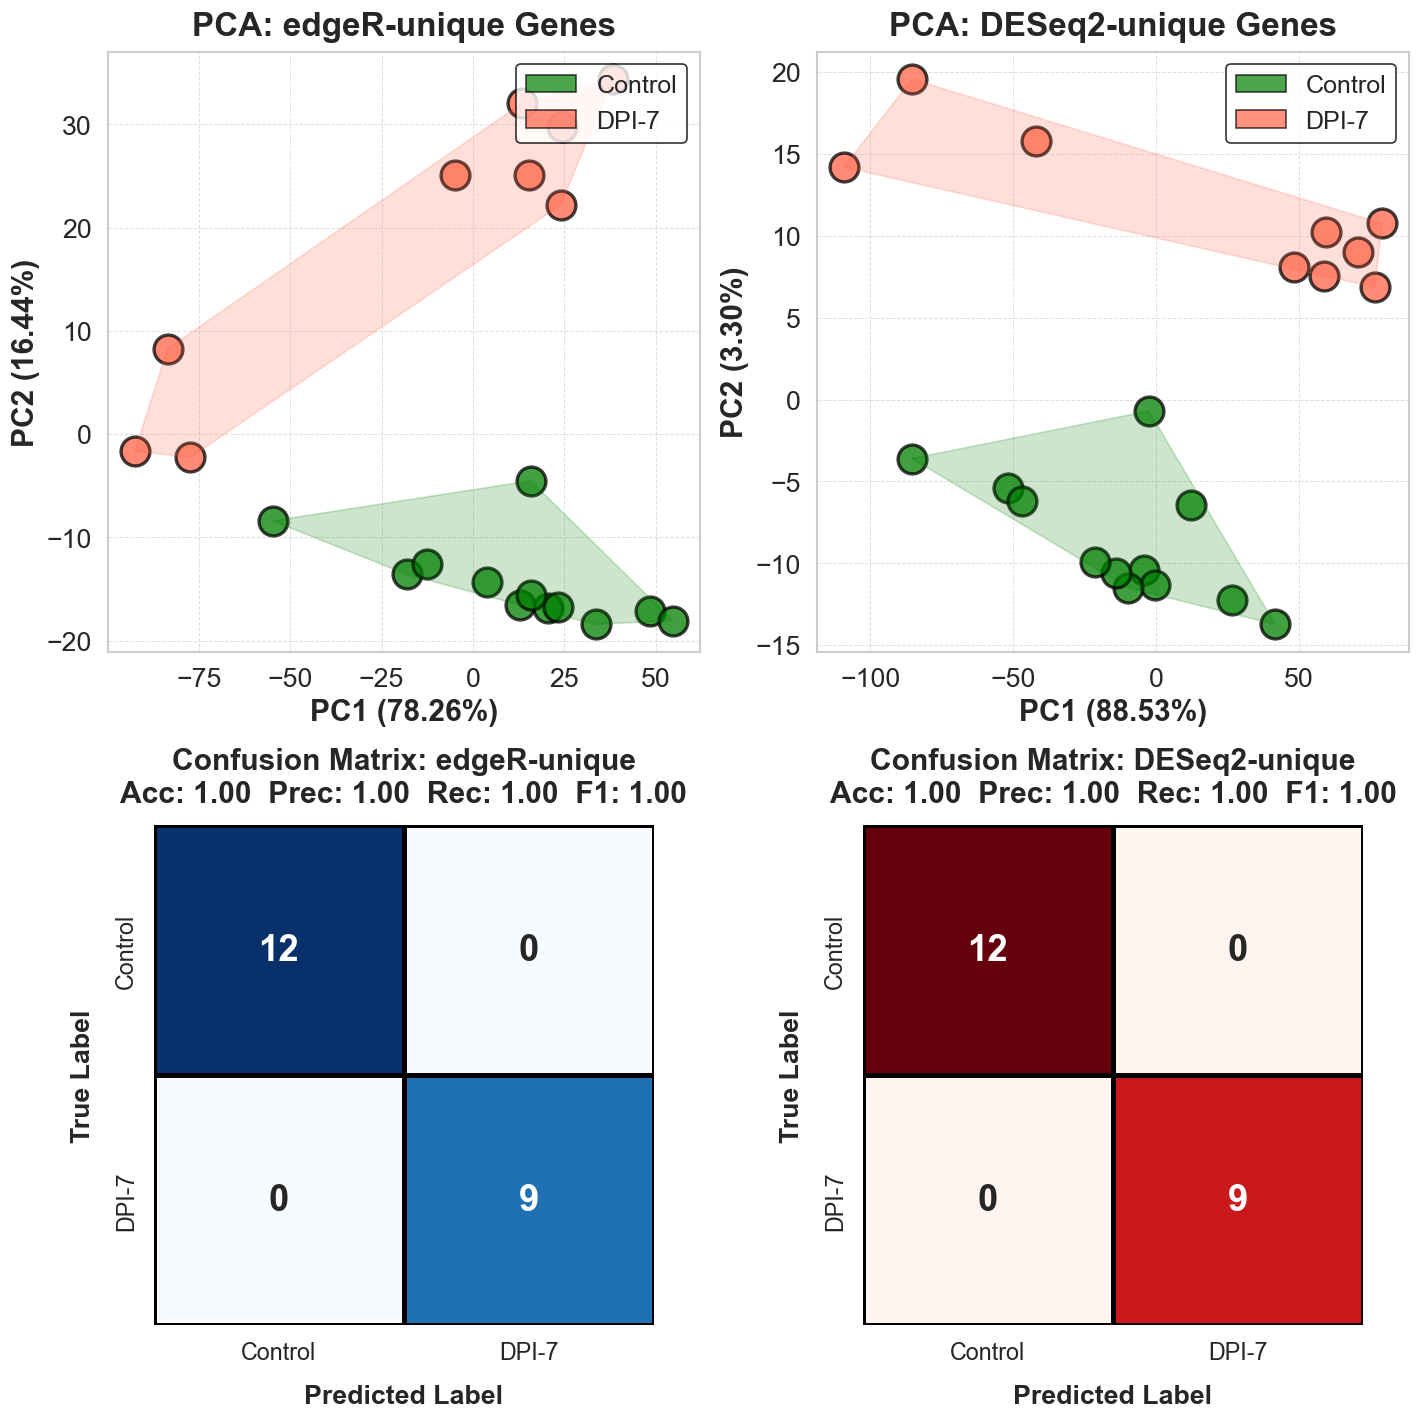

edgeR-unique Metrics
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1 Score:  1.000
------------------------------
DESeq2-unique Metrics
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1 Score:  1.000


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from matplotlib.patches import Patch
from scipy.spatial import ConvexHull
from matplotlib import gridspec
import seaborn as sns

def prepare_data(gene_list, df):
    data = df.copy()
    filtered_genes = [g for g in gene_list if g in data.index]
    data = data.loc[filtered_genes]
    data_transposed = np.log2(data.transpose() + 1)
    group_names = ['Control' if 'DPI_0' in s else 'DPI-7' for s in data_transposed.index]
    labels = [0 if g == 'Control' else 1 for g in group_names]
    return (data_transposed, labels, group_names)

def plot_pca(ax, data_scaled, group_names, title, color_map):
    pca = PCA(n_components=2)
    components = pca.fit_transform(data_scaled)
    explained = pca.explained_variance_ratio_
    explained_text = [f'{v:.2%}' for v in explained]
    df = pd.DataFrame(components, columns=['PC1', 'PC2'])
    df['Group'] = group_names
    for label in df['Group'].unique():
        points = df[df['Group'] == label][['PC1', 'PC2']].values
        ax.scatter(points[:, 0], points[:, 1], s=300, color=color_map[label], label=label, edgecolor='black', alpha=0.75, linewidth=2)
        if len(points) > 2:
            hull = ConvexHull(points)
            hull_pts = points[hull.vertices]
            ax.fill(hull_pts[:, 0], hull_pts[:, 1], color=color_map[label], alpha=0.2)
    ax.set_title(title, fontsize=20, weight='bold', pad=10)
    ax.set_xlabel(f'PC1 ({explained_text[0]})', fontsize=18, weight='bold')
    ax.set_ylabel(f'PC2 ({explained_text[1]})', fontsize=18, weight='bold')
    ax.tick_params(axis='both', labelsize=16, width=2)
    ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
    handles = [Patch(facecolor=color_map[l], edgecolor='black', label=l, alpha=0.7) for l in df['Group'].unique()]
    ax.legend(handles=handles, fontsize=15, frameon=True, edgecolor='black', loc='upper right')
    return components
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def plot_conf_matrix(ax, cm, title, cmap, class_labels, y_true, y_pred):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, xticklabels=class_labels, yticklabels=class_labels, linewidths=2, linecolor='black', square=True, ax=ax, annot_kws={'size': 22, 'weight': 'bold'})
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    metrics_title = f'{title}\nAcc: {acc:.2f}  Prec: {prec:.2f}  Rec: {rec:.2f}  F1: {f1:.2f}'
    ax.set_title(metrics_title, fontsize=18, fontweight='bold', pad=14)
    ax.set_xlabel('Predicted Label', fontsize=16, fontweight='bold', labelpad=12)
    ax.set_ylabel('True Label', fontsize=16, fontweight='bold', labelpad=12)
    ax.tick_params(axis='both', labelsize=14, width=2)
color_map = {'Control': 'green', 'DPI-7': 'tomato'}
data_scaled_er, labels_er, group_names_er = prepare_data(edgeR_only_up + edgeR_only_down, Control_dpi7)
data_scaled_dq, labels_dq, group_names_dq = prepare_data(deseq2_only_up + deseq2_only_down, Control_dpi7)
fig = plt.figure(figsize=(12, 12), dpi=120)
gs = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1])
ax1 = fig.add_subplot(gs[0, 0])
components_er = plot_pca(ax1, data_scaled_er, group_names_er, 'PCA: edgeR-unique Genes', color_map)
ax2 = fig.add_subplot(gs[0, 1])
components_dq = plot_pca(ax2, data_scaled_dq, group_names_dq, 'PCA: DESeq2-unique Genes', color_map)
clf_er = LogisticRegression().fit(components_er, labels_er)
preds_er = clf_er.predict(components_er)
cm_er = confusion_matrix(labels_er, preds_er)
clf_dq = LogisticRegression().fit(components_dq, labels_dq)
preds_dq = clf_dq.predict(components_dq)
cm_dq = confusion_matrix(labels_dq, preds_dq)
ax3 = fig.add_subplot(gs[1, 0])
plot_conf_matrix(ax3, cm_er, 'Confusion Matrix: edgeR-unique', cmap='Blues', class_labels=['Control', 'DPI-7'], y_true=labels_er, y_pred=preds_er)
ax4 = fig.add_subplot(gs[1, 1])
plot_conf_matrix(ax4, cm_dq, 'Confusion Matrix: DESeq2-unique', cmap='Reds', class_labels=['Control', 'DPI-7'], y_true=labels_dq, y_pred=preds_dq)
plt.tight_layout()
plt.show()
acc_er = accuracy_score(labels_er, preds_er)
prec_er = precision_score(labels_er, preds_er)
rec_er = recall_score(labels_er, preds_er)
f1_er = f1_score(labels_er, preds_er)
print('edgeR-unique Metrics')
print(f'Accuracy:  {acc_er:.3f}')
print(f'Precision: {prec_er:.3f}')
print(f'Recall:    {rec_er:.3f}')
print(f'F1 Score:  {f1_er:.3f}')
print('-' * 30)
acc_dq = accuracy_score(labels_dq, preds_dq)
prec_dq = precision_score(labels_dq, preds_dq)
rec_dq = recall_score(labels_dq, preds_dq)
f1_dq = f1_score(labels_dq, preds_dq)
print('DESeq2-unique Metrics')
print(f'Accuracy:  {acc_dq:.3f}')
print(f'Precision: {prec_dq:.3f}')
print(f'Recall:    {rec_dq:.3f}')
print(f'F1 Score:  {f1_dq:.3f}')


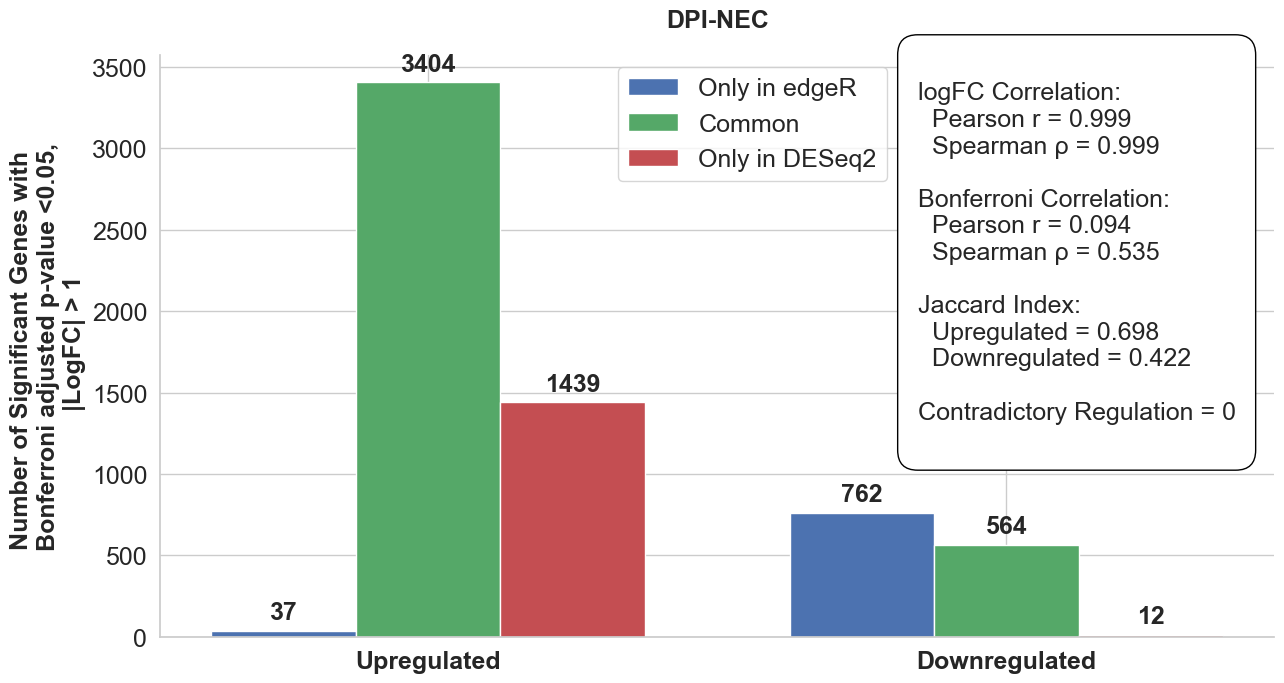

Significant Gene Counts:
  edgeR: 4767
  DESeq2: 5419
  Common: 3968

Upregulated Genes:
  Common: 3404
  Only in edgeR: 37
  Only in DESeq2: 1439
  Jaccard Index: 0.698

Downregulated Genes:
  Common: 564
  Only in edgeR: 762
  Only in DESeq2: 12
  Jaccard Index: 0.422

Contradictory Regulation (Up in one, Down in other): 0

Correlation of logFC:
  Pearson r = 0.999
  Spearman ρ = 0.999

Correlation of Bonferroni-adjusted p-values:
  Pearson r = 0.094
  Spearman ρ = 0.535
Top 10 common_up: ['A2ML1', 'A3GALT2', 'AADAT', 'AANAT', 'AARD', 'ABCA12', 'ABCA13', 'ABCA2', 'ABCA3', 'ABCA6']
Top 10 common_down: ['ABHD2', 'ABHD4', 'ABHD5', 'ACADM', 'ACP1', 'ACP5', 'ADAM19', 'ADIPOR1', 'ADRB2', 'AFF3']
Top 10 edgeR_only_up: ['ACTL9', 'ALOX15B', 'ARHGAP36', 'CCL25', 'CENPVL3', 'CRP', 'CRYGN', 'CYTL1', 'FGG', 'FOXA2']
Top 10 deseq2_only_up: ['AADAC', 'AADACL2', 'AADACL4', 'AATK', 'ABCA4', 'ABCC2', 'ABCD1', 'ABHD11', 'ABHD15', 'ABHD17A']
Top 10 edgeR_only_down: ['ABCB10', 'ABCE1', 'ABCG2', 'ABHD12',

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
edgeR_sig_df = pd.read_csv('EdgeR_Significant_DPI-NEC.csv').set_index('Gene Symbol')
deseq2_sig_df = pd.read_csv('DESeq2_Significant_DPI-NEC.csv').set_index('Gene Symbol')
edgeR_up = set(edgeR_sig_df[edgeR_sig_df['Category'] == 'Upregulated'].index)
edgeR_down = set(edgeR_sig_df[edgeR_sig_df['Category'] == 'Downregulated'].index)
deseq2_up = set(deseq2_sig_df[deseq2_sig_df['Category'] == 'Upregulated'].index)
deseq2_down = set(deseq2_sig_df[deseq2_sig_df['Category'] == 'Downregulated'].index)
common_genes = edgeR_sig_df.index.intersection(deseq2_sig_df.index)
df1 = edgeR_sig_df.loc[common_genes]
df2 = deseq2_sig_df.loc[common_genes]
valid_rows = df1['logFC'].notna() & df2['logFC'].notna() & df1['Bonferroni_adjusted_p-value'].notna() & df2['Bonferroni_adjusted_p-value'].notna() & np.isfinite(df1['logFC']) & np.isfinite(df2['logFC']) & np.isfinite(df1['Bonferroni_adjusted_p-value']) & np.isfinite(df2['Bonferroni_adjusted_p-value'])
df1_clean = df1[valid_rows]
df2_clean = df2[valid_rows]
logfc1 = df1_clean['logFC']
logfc2 = df2_clean['logFC']
bonf1 = df1_clean['Bonferroni_adjusted_p-value']
bonf2 = df2_clean['Bonferroni_adjusted_p-value']
pearson_logfc, _ = pearsonr(logfc1, logfc2)
spearman_logfc, _ = spearmanr(logfc1, logfc2)
pearson_bonf, _ = pearsonr(bonf1, bonf2)
spearman_bonf, _ = spearmanr(bonf1, bonf2)
jaccard_up = len(edgeR_up & deseq2_up) / len(edgeR_up | deseq2_up)
jaccard_down = len(edgeR_down & deseq2_down) / len(edgeR_down | deseq2_down)
contradictory = len(edgeR_up & deseq2_down | edgeR_down & deseq2_up)
common_up = edgeR_up & deseq2_up
common_down = edgeR_down & deseq2_down
edgeR_only_up = edgeR_up - deseq2_up
deseq2_only_up = deseq2_up - edgeR_up
edgeR_only_down = edgeR_down - deseq2_down
deseq2_only_down = deseq2_down - edgeR_down
labels = ['Upregulated', 'Downregulated']
x = np.arange(len(labels))
width = 0.25
edgeR_only_counts = [len(edgeR_only_up), len(edgeR_only_down)]
common_counts = [len(common_up), len(common_down)]
deseq2_only_counts = [len(deseq2_only_up), len(deseq2_only_down)]
sns.set(style='whitegrid')
plt.rcParams.update({'font.size': 12})
colors = {'Only in edgeR': '#4C72B0', 'Common': '#55A868', 'Only in DESeq2': '#C44E52'}
fig, ax = plt.subplots(figsize=(13, 7))
bar1 = ax.bar(x - width, edgeR_only_counts, width, label='Only in edgeR', color=colors['Only in edgeR'])
bar2 = ax.bar(x, common_counts, width, label='Common', color=colors['Common'])
bar3 = ax.bar(x + width, deseq2_only_counts, width, label='Only in DESeq2', color=colors['Only in DESeq2'])
ax.set_ylabel('Number of Significant Genes with \n Bonferroni adjusted p-value <0.05, \n |LogFC| > 1', fontsize=18, weight='bold')
ax.set_title('DPI-NEC', fontsize=18, weight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=18, weight='bold')
ax.tick_params(axis='y', labelsize=18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=True, fontsize=18, loc='upper left', bbox_to_anchor=(0.4, 1))
for bars in [bar1, bar2, bar3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 5), textcoords='offset points', ha='center', va='bottom', fontsize=18, weight='bold')
textstr = f'\nlogFC Correlation:\n  Pearson r = {pearson_logfc:.3f}\n  Spearman ρ = {spearman_logfc:.3f}\n\nBonferroni Correlation:\n  Pearson r = {pearson_bonf:.3f}\n  Spearman ρ = {spearman_bonf:.3f}\n\nJaccard Index:\n  Upregulated = {jaccard_up:.3f}\n  Downregulated = {jaccard_down:.3f}\n\nContradictory Regulation = {contradictory}\n'
props = dict(boxstyle='round,pad=0.8', facecolor='white', edgecolor='black')
ax.text(0.68, 1, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
plt.tight_layout()
plt.show()
common_up = edgeR_up & deseq2_up
common_down = edgeR_down & deseq2_down
edgeR_only_up = edgeR_up - deseq2_up
deseq2_only_up = deseq2_up - edgeR_up
edgeR_only_down = edgeR_down - deseq2_down
deseq2_only_down = deseq2_down - edgeR_down
print('Significant Gene Counts:')
print(f'  edgeR: {edgeR_sig_df.shape[0]}')
print(f'  DESeq2: {deseq2_sig_df.shape[0]}')
print(f'  Common: {len(common_genes)}')
print('\nUpregulated Genes:')
print(f'  Common: {len(common_up)}')
print(f'  Only in edgeR: {len(edgeR_only_up)}')
print(f'  Only in DESeq2: {len(deseq2_only_up)}')
print(f'  Jaccard Index: {jaccard_up:.3f}')
print('\nDownregulated Genes:')
print(f'  Common: {len(common_down)}')
print(f'  Only in edgeR: {len(edgeR_only_down)}')
print(f'  Only in DESeq2: {len(deseq2_only_down)}')
print(f'  Jaccard Index: {jaccard_down:.3f}')
print(f'\nContradictory Regulation (Up in one, Down in other): {contradictory}')
print('\nCorrelation of logFC:')
print(f'  Pearson r = {pearson_logfc:.3f}')
print(f'  Spearman ρ = {spearman_logfc:.3f}')
print('\nCorrelation of Bonferroni-adjusted p-values:')
print(f'  Pearson r = {pearson_bonf:.3f}')
print(f'  Spearman ρ = {spearman_bonf:.3f}')
common_up = sorted(list(edgeR_up & deseq2_up))
common_down = sorted(list(edgeR_down & deseq2_down))
edgeR_only_up = sorted(list(edgeR_up - deseq2_up))
deseq2_only_up = sorted(list(deseq2_up - edgeR_up))
edgeR_only_down = sorted(list(edgeR_down - deseq2_down))
deseq2_only_down = sorted(list(deseq2_down - edgeR_down))
print('Top 10 common_up:', common_up[:10])
print('Top 10 common_down:', common_down[:10])
print('Top 10 edgeR_only_up:', edgeR_only_up[:10])
print('Top 10 deseq2_only_up:', deseq2_only_up[:10])
print('Top 10 edgeR_only_down:', edgeR_only_down[:10])
print('Top 10 deseq2_only_down:', deseq2_only_down[:10])


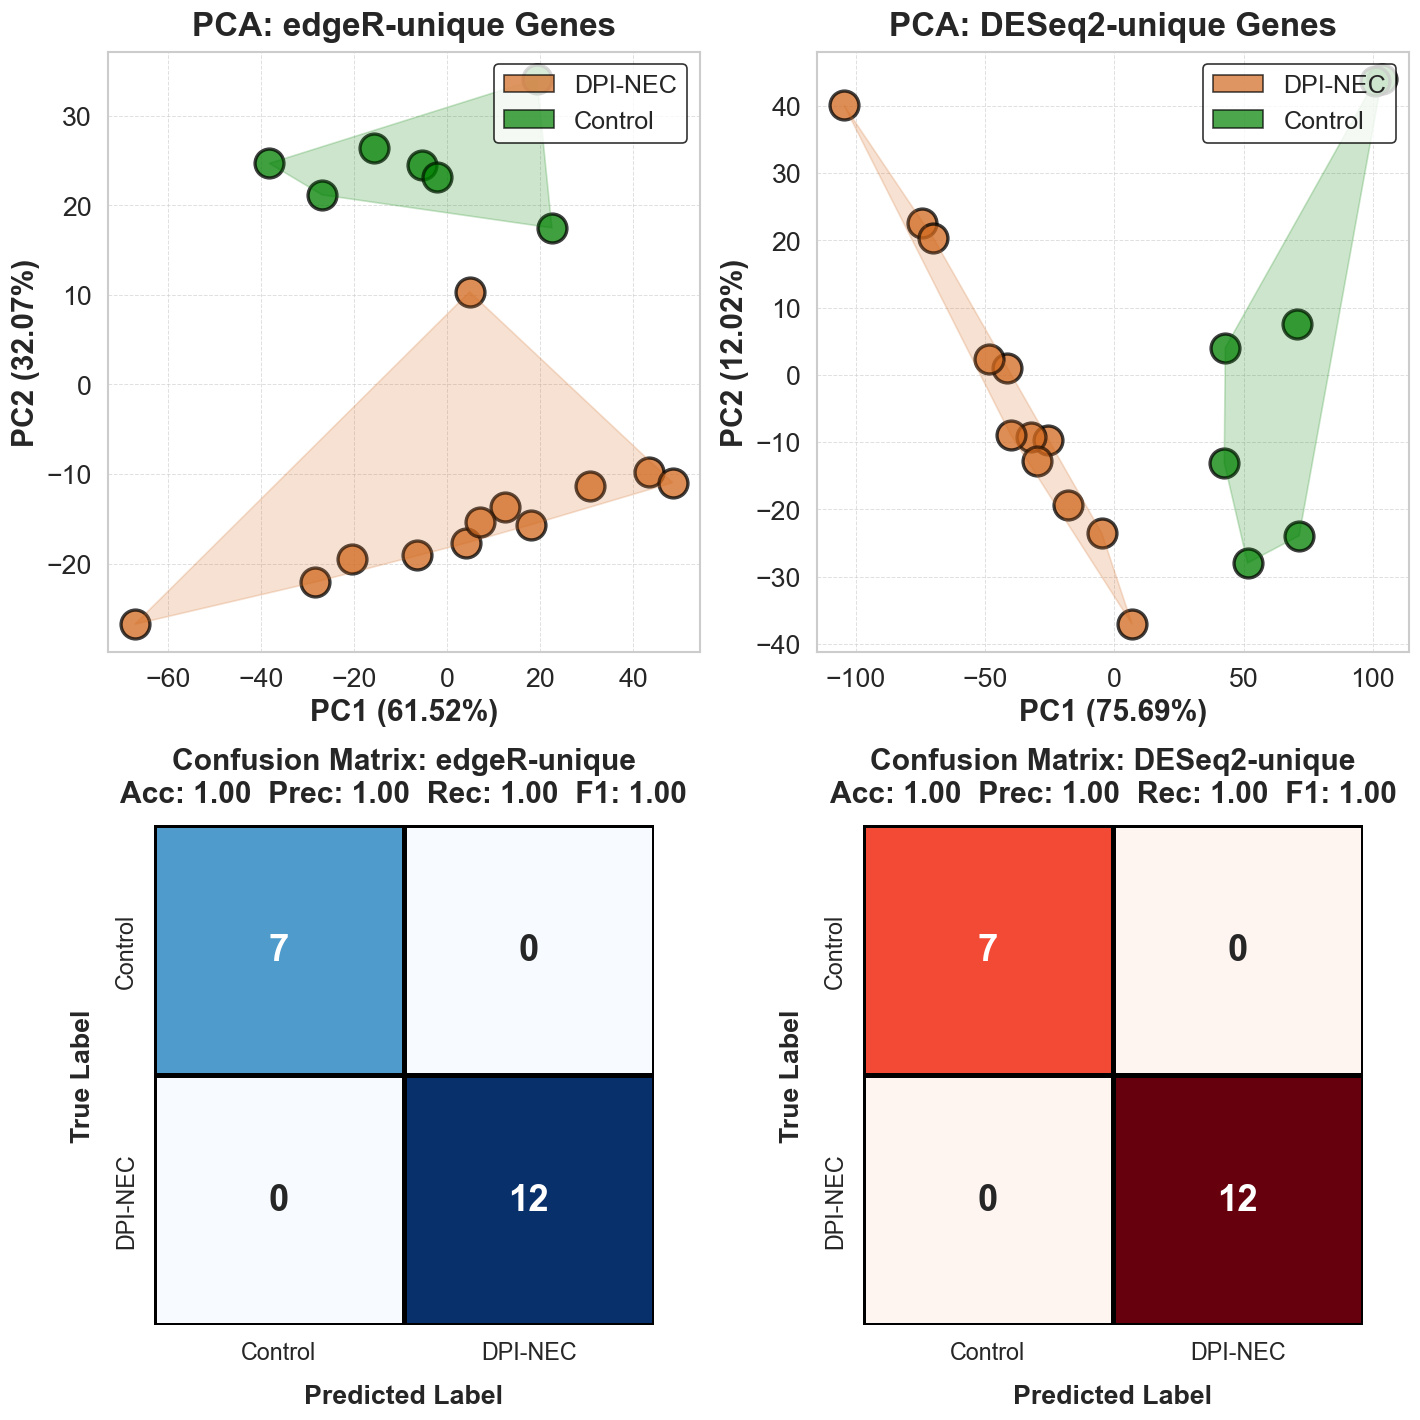

edgeR-unique Metrics
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1 Score:  1.000
------------------------------
DESeq2-unique Metrics
Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1 Score:  1.000


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from matplotlib.patches import Patch
from scipy.spatial import ConvexHull
from matplotlib import gridspec
import seaborn as sns

def prepare_data(gene_list, df):
    data = df.copy()
    filtered_genes = [g for g in gene_list if g in data.index]
    data = data.loc[filtered_genes]
    data_transposed = np.log2(data.transpose() + 1)
    group_names = ['Control' if 'DPI_NEC' in s else 'DPI-NEC' for s in data_transposed.index]
    labels = [0 if g == 'Control' else 1 for g in group_names]
    return (data_transposed, labels, group_names)

def plot_pca(ax, data_scaled, group_names, title, color_map):
    pca = PCA(n_components=2)
    components = pca.fit_transform(data_scaled)
    explained = pca.explained_variance_ratio_
    explained_text = [f'{v:.2%}' for v in explained]
    df = pd.DataFrame(components, columns=['PC1', 'PC2'])
    df['Group'] = group_names
    for label in df['Group'].unique():
        points = df[df['Group'] == label][['PC1', 'PC2']].values
        ax.scatter(points[:, 0], points[:, 1], s=300, color=color_map[label], label=label, edgecolor='black', alpha=0.75, linewidth=2)
        if len(points) > 2:
            hull = ConvexHull(points)
            hull_pts = points[hull.vertices]
            ax.fill(hull_pts[:, 0], hull_pts[:, 1], color=color_map[label], alpha=0.2)
    ax.set_title(title, fontsize=20, weight='bold', pad=10)
    ax.set_xlabel(f'PC1 ({explained_text[0]})', fontsize=18, weight='bold')
    ax.set_ylabel(f'PC2 ({explained_text[1]})', fontsize=18, weight='bold')
    ax.tick_params(axis='both', labelsize=16, width=2)
    ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
    handles = [Patch(facecolor=color_map[l], edgecolor='black', label=l, alpha=0.7) for l in df['Group'].unique()]
    ax.legend(handles=handles, fontsize=15, frameon=True, edgecolor='black', loc='upper right')
    return components
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def plot_conf_matrix(ax, cm, title, cmap, class_labels, y_true, y_pred):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, xticklabels=class_labels, yticklabels=class_labels, linewidths=2, linecolor='black', square=True, ax=ax, annot_kws={'size': 22, 'weight': 'bold'})
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    metrics_title = f'{title}\nAcc: {acc:.2f}  Prec: {prec:.2f}  Rec: {rec:.2f}  F1: {f1:.2f}'
    ax.set_title(metrics_title, fontsize=18, fontweight='bold', pad=14)
    ax.set_xlabel('Predicted Label', fontsize=16, fontweight='bold', labelpad=12)
    ax.set_ylabel('True Label', fontsize=16, fontweight='bold', labelpad=12)
    ax.tick_params(axis='both', labelsize=14, width=2)
color_map = {'Control': 'green', 'DPI-NEC': 'chocolate'}
data_scaled_er, labels_er, group_names_er = prepare_data(edgeR_only_up + edgeR_only_down, Control_dpiNEC)
data_scaled_dq, labels_dq, group_names_dq = prepare_data(deseq2_only_up + deseq2_only_down, Control_dpiNEC)
fig = plt.figure(figsize=(12, 12), dpi=120)
gs = gridspec.GridSpec(2, 2, height_ratios=[1.2, 1])
ax1 = fig.add_subplot(gs[0, 0])
components_er = plot_pca(ax1, data_scaled_er, group_names_er, 'PCA: edgeR-unique Genes', color_map)
ax2 = fig.add_subplot(gs[0, 1])
components_dq = plot_pca(ax2, data_scaled_dq, group_names_dq, 'PCA: DESeq2-unique Genes', color_map)
clf_er = LogisticRegression().fit(components_er, labels_er)
preds_er = clf_er.predict(components_er)
cm_er = confusion_matrix(labels_er, preds_er)
clf_dq = LogisticRegression().fit(components_dq, labels_dq)
preds_dq = clf_dq.predict(components_dq)
cm_dq = confusion_matrix(labels_dq, preds_dq)
ax3 = fig.add_subplot(gs[1, 0])
plot_conf_matrix(ax3, cm_er, 'Confusion Matrix: edgeR-unique', cmap='Blues', class_labels=['Control', 'DPI-NEC'], y_true=labels_er, y_pred=preds_er)
ax4 = fig.add_subplot(gs[1, 1])
plot_conf_matrix(ax4, cm_dq, 'Confusion Matrix: DESeq2-unique', cmap='Reds', class_labels=['Control', 'DPI-NEC'], y_true=labels_dq, y_pred=preds_dq)
plt.tight_layout()
plt.show()
acc_er = accuracy_score(labels_er, preds_er)
prec_er = precision_score(labels_er, preds_er)
rec_er = recall_score(labels_er, preds_er)
f1_er = f1_score(labels_er, preds_er)
print('edgeR-unique Metrics')
print(f'Accuracy:  {acc_er:.3f}')
print(f'Precision: {prec_er:.3f}')
print(f'Recall:    {rec_er:.3f}')
print(f'F1 Score:  {f1_er:.3f}')
print('-' * 30)
acc_dq = accuracy_score(labels_dq, preds_dq)
prec_dq = precision_score(labels_dq, preds_dq)
rec_dq = recall_score(labels_dq, preds_dq)
f1_dq = f1_score(labels_dq, preds_dq)
print('DESeq2-unique Metrics')
print(f'Accuracy:  {acc_dq:.3f}')
print(f'Precision: {prec_dq:.3f}')
print(f'Recall:    {rec_dq:.3f}')
print(f'F1 Score:  {f1_dq:.3f}')
